# 04B — Future-Holdout集合竞价特征增量生产

本notebook是`04_auction_features_organized.ipynb`的隔离增量版本：

- 不修改原Notebook 4；
- 不覆盖任何`04_*`开发期CSV；
- 从旧开发表冻结股票池；
- 查询一段历史缓冲期，但最终只导出2026-04-14之后的样本；
- 默认使用5只股票做小样本试跑；
- DolphinDB原始查询按阶段写入独立checkpoint；
- 所有最终输出采用`04b_holdout_*`文件名并以临时文件原子替换。

第一次建议保持`SMALL_SAMPLE_MODE=True`。确认全部单元能够执行后，再改为`False`并清空
`04b_checkpoints`，重新生成完整40只股票的holdout文件。


In [163]:
# 04B.0 Isolated holdout configuration and safe-write helpers.
import os
from pathlib import Path
import pandas as pd
import numpy as np

DEVELOPMENT_END_DATE = pd.Timestamp("2026-04-13")
HOLDOUT_START_DATE = pd.Timestamp("2026-04-14")
HOLDOUT_END_DATE = pd.Timestamp("2026-07-17")

# History is queried only to construct lagged features and prior-order thresholds.
# Rows before HOLDOUT_START_DATE must never enter the final holdout exports.
HISTORY_BUFFER_START_DATE = pd.Timestamp("2026-03-02")

SMALL_SAMPLE_MODE = False
SMALL_SAMPLE_STOCKS = 5
REUSE_CHECKPOINTS = True
HOLDOUT_MIN_TABLE_DATES = 1

NOTEBOOK_DIR_04B = Path(
    r"C:\Users\work\OneDrive\Documents\level2-research\notebooks"
)
assert NOTEBOOK_DIR_04B.exists()
os.chdir(NOTEBOOK_DIR_04B)
CHECKPOINT_RUN_NAME = (
    f"small_{SMALL_SAMPLE_STOCKS}" if SMALL_SAMPLE_MODE else "full_40"
)
CHECKPOINT_DIR = (
    NOTEBOOK_DIR_04B / "04b_checkpoints" / CHECKPOINT_RUN_NAME
)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

def _atomic_to_csv(frame, path, **kwargs):
    path = Path(path)
    temporary = path.with_suffix(path.suffix + ".tmp")
    frame.to_csv(temporary, **kwargs)
    os.replace(temporary, path)

def _atomic_to_pickle(frame, path):
    path = Path(path)
    temporary = path.with_suffix(path.suffix + ".tmp")
    frame.to_pickle(temporary)
    os.replace(temporary, path)

print("Development boundary:", DEVELOPMENT_END_DATE.date())
print("History buffer:", HISTORY_BUFFER_START_DATE.date())
print("Holdout export:", HOLDOUT_START_DATE.date(), "to", HOLDOUT_END_DATE.date())
print("Small-sample mode:", SMALL_SAMPLE_MODE)
print("Checkpoint namespace:", CHECKPOINT_RUN_NAME)


Development boundary: 2026-04-13
History buffer: 2026-03-02
Holdout export: 2026-04-14 to 2026-07-17
Small-sample mode: False
Checkpoint namespace: full_40


## CODE
### Preparation

In [164]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

EPS = 1e-9

In [165]:
import sys
import os

import matplotlib.pyplot as plt
import matplotlib.dates as mdates


sys.path.append(os.path.abspath(".."))
plt.rcParams["figure.figsize"] = (12, 5)

from src.ddb_client import connect_ddb

session = connect_ddb()

In [166]:
DB_PATH = "dfs://quota"

# Query includes a history buffer; final exports are filtered separately.
START_DATE = HISTORY_BUFFER_START_DATE.strftime("%Y.%m.%d")
END_DATE = HOLDOUT_END_DATE.strftime("%Y.%m.%d")
POOL_START_DATE = START_DATE
POOL_END_DATE = END_DATE

AUCTION_START = "09:15:00"
AUCTION_END = "09:25:00"

print("Database:", DB_PATH)
print("Calculation period:", START_DATE, "to", END_DATE)
print("True holdout starts:", HOLDOUT_START_DATE.date())
print("Auction window:", AUCTION_START, "to", AUCTION_END)

table_script = f"""
qtick = loadTable("{DB_PATH}", "qtick")
qorder = loadTable("{DB_PATH}", "qorder")
qknock = loadTable("{DB_PATH}", "qknock")
"""
session.run(table_script)
print("Defined DolphinDB tables: qtick, qorder, qknock")


Database: dfs://quota
Calculation period: 2026.03.02 to 2026.07.17
True holdout starts: 2026-04-14
Auction window: 09:15:00 to 09:25:00
Defined DolphinDB tables: qtick, qorder, qknock


In [167]:
# ============================================================
# Frozen development stock universe — never re-sampled on holdout dates
# ============================================================
FROZEN_DEVELOPMENT_FEATURE_PATH = Path("04_auction_feature_table.csv")
assert FROZEN_DEVELOPMENT_FEATURE_PATH.exists(), (
    "The frozen development export is required to recover the original stock pool."
)
frozen_development_keys = pd.read_csv(
    FROZEN_DEVELOPMENT_FEATURE_PATH, usecols=["code"]
)
frozen_codes = sorted(
    frozen_development_keys["code"].astype(str).str.strip().str.upper().unique()
)
assert len(frozen_codes) == 40, (
    f"Expected the frozen 40-stock universe, found {len(frozen_codes)}."
)

def classify_a_share_board(code):
    code = str(code).strip().upper()
    if code.endswith(".SZ") and code[:3] in {"000", "001", "002", "003"}:
        return "SZ Main"
    if code.endswith(".SZ") and code[:3] in {"300", "301"}:
        return "ChiNext"
    if code.endswith(".SH") and code[:3] in {"600", "601", "603", "605"}:
        return "SH Main"
    if code.endswith(".SH") and code[:3] == "688":
        return "STAR"
    return None

sample_codes = (
    frozen_codes[:SMALL_SAMPLE_STOCKS]
    if SMALL_SAMPLE_MODE
    else frozen_codes
)
stock_pool = pd.DataFrame({"code": sample_codes})
stock_pool["board"] = stock_pool["code"].map(classify_a_share_board)
stock_pool["name"] = np.nan
stock_pool["dtype"] = 1
stock_pool["n_qtick_dates"] = np.nan

assert stock_pool["code"].is_unique
assert stock_pool["board"].notna().all()
assert set(sample_codes).issubset(frozen_codes)

codes_ddb = "[" + ",".join(f'"{code}"' for code in sample_codes) + "]"
code_filter = ",".join(f'"{code}"' for code in sample_codes)

print("Frozen development universe:", len(frozen_codes))
print("Stocks requested in this run:", len(sample_codes))
display(stock_pool.groupby("board").size().rename("n_stocks").to_frame())
display(stock_pool)


Frozen development universe: 40
Stocks requested in this run: 40


,n_stocks
board,
ChiNext,8
SH Main,12
STAR,8
SZ Main,12


,code,board,name,dtype,n_qtick_dates
0,000713.SZ,SZ Main,NaN,1,NaN
1,000782.SZ,SZ Main,NaN,1,NaN
2,000816.SZ,SZ Main,NaN,1,NaN
3,000863.SZ,SZ Main,NaN,1,NaN
4,001215.SZ,SZ Main,NaN,1,NaN
5,002240.SZ,SZ Main,NaN,1,NaN
6,002278.SZ,SZ Main,NaN,1,NaN
7,002438.SZ,SZ Main,NaN,1,NaN
8,002441.SZ,SZ Main,NaN,1,NaN
9,002451.SZ,SZ Main,NaN,1,NaN


In [168]:
# The same deterministic list is used by File 5.
print(code_filter)

"000713.SZ","000782.SZ","000816.SZ","000863.SZ","001215.SZ","002240.SZ","002278.SZ","002438.SZ","002441.SZ","002451.SZ","002553.SZ","002578.SZ","300183.SZ","300490.SZ","300595.SZ","301052.SZ","301255.SZ","301391.SZ","301552.SZ","301622.SZ","600158.SH","600182.SH","600425.SH","600458.SH","600488.SH","600662.SH","603309.SH","603458.SH","603466.SH","603650.SH","605111.SH","605196.SH","688011.SH","688089.SH","688125.SH","688207.SH","688326.SH","688535.SH","688599.SH","688737.SH"


In [169]:
# ============================================================
# Three-table coverage validation for the unified stock pool
# ============================================================
coverage_queries = {
    "qtick": f"""
        select distinct code, date
        from loadTable("{DB_PATH}", "qtick")
        where code in {codes_ddb}
          and date >= {POOL_START_DATE}
          and date <= {POOL_END_DATE}
    """,
    "qorder": f"""
        select distinct code, date
        from loadTable("{DB_PATH}", "qorder")
        where code in {codes_ddb}
          and date >= {POOL_START_DATE}
          and date <= {POOL_END_DATE}
    """,
    "qknock": f"""
        select distinct code, date
        from loadTable("{DB_PATH}", "qknock")
        where code in {codes_ddb}
          and date >= {POOL_START_DATE}
          and date <= {POOL_END_DATE}
    """,
}

coverage_parts = []
for table_name, query in coverage_queries.items():
    tmp = session.run(query)
    tmp["code"] = tmp["code"].astype(str).str.strip().str.upper()
    summary = tmp.groupby("code")["date"].nunique().rename(f"{table_name}_dates")
    coverage_parts.append(summary)

three_table_coverage = (
    stock_pool.set_index("code")[["name", "board"]]
    .join(coverage_parts, how="left")
    .fillna({"qtick_dates": 0, "qorder_dates": 0, "qknock_dates": 0})
    .reset_index()
)

for col in ["qtick_dates", "qorder_dates", "qknock_dates"]:
    three_table_coverage[col] = three_table_coverage[col].astype(int)

three_table_coverage["three_table_ready"] = (
    three_table_coverage[["qtick_dates", "qorder_dates", "qknock_dates"]]
    .min(axis=1)
    .ge(HOLDOUT_MIN_TABLE_DATES)
)

display(three_table_coverage)
assert three_table_coverage["three_table_ready"].all(), (
    "Some selected stocks lack sufficient qtick/qorder/qknock coverage. "
    "Inspect three_table_coverage before continuing."
)
print("Unified stock pool passed security-type, code-range and three-table coverage checks.")


,code,name,board,qtick_dates,qorder_dates,qknock_dates,three_table_ready
0,000713.SZ,NaN,SZ Main,80,80,80,True
1,000782.SZ,NaN,SZ Main,80,80,80,True
2,000816.SZ,NaN,SZ Main,80,80,80,True
3,000863.SZ,NaN,SZ Main,80,80,80,True
4,001215.SZ,NaN,SZ Main,80,80,80,True
5,002240.SZ,NaN,SZ Main,80,80,80,True
6,002278.SZ,NaN,SZ Main,80,80,80,True
7,002438.SZ,NaN,SZ Main,80,80,80,True
8,002441.SZ,NaN,SZ Main,80,80,80,True
9,002451.SZ,NaN,SZ Main,80,80,80,True


Unified stock pool passed security-type, code-range and three-table coverage checks.


In [170]:
# Safe checkpoint wrapper: a failed query never overwrites a completed checkpoint.
_checkpoint_path = CHECKPOINT_DIR / "qtick_auction_buffer.pkl"
if REUSE_CHECKPOINTS and _checkpoint_path.exists():
    qtick = pd.read_pickle(_checkpoint_path)
    print("Loaded checkpoint:", _checkpoint_path.resolve(), qtick.shape)
else:
    # ============================================================
    # Batched qtick Query
    # ============================================================

    def chunk_codes(codes, batch_size=10):
        for start in range(0, len(codes), batch_size):
            yield codes[start:start + batch_size]


    qtick_parts = []

    for batch_no, code_batch in enumerate(
        chunk_codes(sample_codes, batch_size=10),
        start=1
    ):
        batch_filter = ",".join(
            f'"{code}"'
            for code in code_batch
        )

        qtick_script = f"""
        select *
        from loadTable("{DB_PATH}", "qtick")
        where date >= {START_DATE}
          and date <= {END_DATE}
          and code in [{batch_filter}]
          and time >= {AUCTION_START}
          and time < {AUCTION_END}
        order by code, date, time
        """

        batch_df = session.run(qtick_script)
        qtick_parts.append(batch_df)

        print(
            f"qtick batch {batch_no}:",
            len(code_batch),
            "stocks,",
            len(batch_df),
            "rows"
        )

    qtick = pd.concat(
        qtick_parts,
        ignore_index=True
    )

    print("qtick total shape:", qtick.shape)
    assert isinstance(qtick, pd.DataFrame) and not qtick.empty, (
        "qtick query returned no rows; checkpoint was not written."
    )
    _atomic_to_pickle(qtick, _checkpoint_path)
    print("Saved checkpoint:", _checkpoint_path.resolve())


qtick batch 1: 10 stocks, 27676 rows
qtick batch 2: 10 stocks, 23510 rows
qtick batch 3: 10 stocks, 104197 rows
qtick batch 4: 10 stocks, 76899 rows
qtick total shape: (232282, 78)
Saved checkpoint: C:\Users\work\OneDrive\Documents\level2-research\notebooks\04b_checkpoints\full_40\qtick_auction_buffer.pkl


In [171]:
# Safe checkpoint wrapper: a failed query never overwrites a completed checkpoint.
_checkpoint_path = CHECKPOINT_DIR / "qorder_auction_buffer.pkl"
if REUSE_CHECKPOINTS and _checkpoint_path.exists():
    qorder = pd.read_pickle(_checkpoint_path)
    print("Loaded checkpoint:", _checkpoint_path.resolve(), qorder.shape)
else:
    # ============================================================
    # Batched qorder Query
    # ============================================================

    qorder_parts = []

    for batch_no, code_batch in enumerate(
        chunk_codes(sample_codes, batch_size=8),
        start=1
    ):
        batch_filter = ",".join(
            f'"{code}"'
            for code in code_batch
        )

        qorder_script = f"""
        select *
        from loadTable("{DB_PATH}", "qorder")
        where date >= {START_DATE}
          and date <= {END_DATE}
          and code in [{batch_filter}]
          and time >= {AUCTION_START}
          and time < {AUCTION_END}
        order by code, date, time
        """

        batch_df = session.run(qorder_script)
        qorder_parts.append(batch_df)

        print(
            f"qorder batch {batch_no}:",
            len(code_batch),
            "stocks,",
            len(batch_df),
            "rows"
        )

    qorder = pd.concat(
        qorder_parts,
        ignore_index=True
    )

    print("qorder total shape:", qorder.shape)
    assert isinstance(qorder, pd.DataFrame) and not qorder.empty, (
        "qorder query returned no rows; checkpoint was not written."
    )
    _atomic_to_pickle(qorder, _checkpoint_path)
    print("Saved checkpoint:", _checkpoint_path.resolve())


qorder batch 1: 8 stocks, 519963 rows
qorder batch 2: 8 stocks, 383463 rows
qorder batch 3: 8 stocks, 379968 rows
qorder batch 4: 8 stocks, 775284 rows
qorder batch 5: 8 stocks, 222917 rows
qorder total shape: (2281595, 8)
Saved checkpoint: C:\Users\work\OneDrive\Documents\level2-research\notebooks\04b_checkpoints\full_40\qorder_auction_buffer.pkl


In [172]:
# Safe checkpoint wrapper: a failed query never overwrites a completed checkpoint.
_checkpoint_path = CHECKPOINT_DIR / "qknock_auction_buffer.pkl"
if REUSE_CHECKPOINTS and _checkpoint_path.exists():
    qknock = pd.read_pickle(_checkpoint_path)
    print("Loaded checkpoint:", _checkpoint_path.resolve(), qknock.shape)
else:
    # ============================================================
    # Batched qknock Query
    # ============================================================

    qknock_parts = []

    for batch_no, code_batch in enumerate(
        chunk_codes(sample_codes, batch_size=10),
        start=1
    ):
        batch_filter = ",".join(
            f'"{code}"'
            for code in code_batch
        )

        qknock_script = f"""
        select *
        from loadTable("{DB_PATH}", "qknock")
        where date >= {START_DATE}
          and date <= {END_DATE}
          and code in [{batch_filter}]
          and time >= {AUCTION_START}
          and time <= {AUCTION_END}
        order by code, date, time
        """

        batch_df = session.run(qknock_script)
        qknock_parts.append(batch_df)

        print(
            f"qknock batch {batch_no}:",
            len(code_batch),
            "stocks,",
            len(batch_df),
            "rows"
        )

    qknock = pd.concat(
        qknock_parts,
        ignore_index=True
    )

    print("qknock total shape:", qknock.shape)
    assert isinstance(qknock, pd.DataFrame) and not qknock.empty, (
        "qknock query returned no rows; checkpoint was not written."
    )
    _atomic_to_pickle(qknock, _checkpoint_path)
    print("Saved checkpoint:", _checkpoint_path.resolve())


qknock batch 1: 10 stocks, 128310 rows
qknock batch 2: 10 stocks, 64769 rows
qknock batch 3: 10 stocks, 2393 rows
qknock batch 4: 10 stocks, 27 rows
qknock total shape: (195499, 8)
Saved checkpoint: C:\Users\work\OneDrive\Documents\level2-research\notebooks\04b_checkpoints\full_40\qknock_auction_buffer.pkl


In [173]:
def prepare_datetime(df):
    df = df.copy()

    df["date"] = pd.to_datetime(df["date"])

    df["datetime"] = pd.to_datetime(
        df["date"].dt.strftime("%Y-%m-%d")
        + " "
        + df["time"].astype(str),
        errors="coerce"
    )

    df["clock"] = df["datetime"].dt.time

    return df


qtick = prepare_datetime(qtick)
qorder = prepare_datetime(qorder)
qknock = prepare_datetime(qknock)

print("qtick :", qtick.shape)
print("qorder:", qorder.shape)
print("qknock:", qknock.shape)

print("\nSample period:")
print(qtick["date"].min(), "→", qtick["date"].max())

print("\nStocks:", qtick["code"].nunique())

C:\Users\work\AppData\Local\Temp\ipykernel_43564\2939394558.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["datetime"] = pd.to_datetime(
C:\Users\work\AppData\Local\Temp\ipykernel_43564\2939394558.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["datetime"] = pd.to_datetime(
C:\Users\work\AppData\Local\Temp\ipykernel_43564\2939394558.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["datetime"] = pd.to_datetime(


qtick : (232282, 80)
qorder: (2281595, 10)
qknock: (195499, 10)

Sample period:
2026-03-02 00:00:00 → 2026-06-26 00:00:00

Stocks: 40


### Auction Window Filter

In [174]:
# ============================================================
# 1. Build Unified Auction Event Table
# ============================================================

def build_auction_events(qorder, qknock):
    # SH + SZ submissions from qorder
    submit_events = qorder[qorder["order_type"] == 0].copy()

    submit_events["exchange"] = np.where(
        submit_events["code"].str.endswith(".SH"),
        "SH",
        np.where(submit_events["code"].str.endswith(".SZ"), "SZ", "OTHER")
    )

    submit_events["event_type"] = "submit"
    submit_events["event_price"] = submit_events["order_price"]
    submit_events["event_volume"] = submit_events["order_volume"]
    submit_events["source_table"] = "qorder"

    submit_events = submit_events[
        [
            "code", "date", "time", "datetime", "clock", "exchange",
            "order_no", "bs_flag",
            "event_type", "event_price", "event_volume", "source_table"
        ]
    ]

    # SH cancellations from qorder
    sh_cancel_events = qorder[
        (qorder["code"].str.endswith(".SH")) &
        (qorder["order_type"] == 3)
    ].copy()

    sh_cancel_events["exchange"] = "SH"
    sh_cancel_events["event_type"] = "cancel"
    sh_cancel_events["event_price"] = np.nan
    sh_cancel_events["event_volume"] = sh_cancel_events["order_volume"]
    sh_cancel_events["source_table"] = "qorder"

    sh_cancel_events = sh_cancel_events[
        [
            "code", "date", "time", "datetime", "clock", "exchange",
            "order_no", "bs_flag",
            "event_type", "event_price", "event_volume", "source_table"
        ]
    ]

    # SZ cancellations from qknock
    sz_cancel_raw = qknock[
        (qknock["code"].str.endswith(".SZ")) &
        (qknock["match_price"] == 0)
    ].copy()

    sz_cancel_raw["exchange"] = "SZ"
    sz_cancel_raw["event_type"] = "cancel"
    sz_cancel_raw["event_price"] = np.nan
    sz_cancel_raw["event_volume"] = sz_cancel_raw["match_volume"]
    sz_cancel_raw["source_table"] = "qknock"

    sz_cancel_raw["order_no"] = np.where(
        sz_cancel_raw["bid_order_no"] != 0,
        sz_cancel_raw["bid_order_no"],
        sz_cancel_raw["ask_order_no"]
    )

    qorder_side = qorder[
        qorder["order_type"] == 0
    ][
        ["code", "date", "order_no", "bs_flag"]
    ].copy()

    sz_cancel_events = sz_cancel_raw.merge(
        qorder_side,
        on=["code", "date", "order_no"],
        how="left"
    )

    sz_cancel_events = sz_cancel_events[
        [
            "code", "date", "time", "datetime", "clock", "exchange",
            "order_no", "bs_flag",
            "event_type", "event_price", "event_volume", "source_table"
        ]
    ]

    auction_events = pd.concat(
        [submit_events, sh_cancel_events, sz_cancel_events],
        ignore_index=True
    )

    auction_events["is_submit"] = auction_events["event_type"] == "submit"
    auction_events["is_cancel"] = auction_events["event_type"] == "cancel"

    # 已验证：bs_flag=1 是 BID/Buy，bs_flag=2 是 ASK/Sell
    auction_events["is_buy"] = auction_events["bs_flag"] == 1
    auction_events["is_sell"] = auction_events["bs_flag"] == 2

    auction_events = auction_events.sort_values(
        ["code", "date", "datetime", "event_type"]
    ).reset_index(drop=True)

    auction_events["time_display"] = auction_events["clock"].apply(
    lambda x: x.strftime("%H:%M:%S.%f")[:-3] if pd.notna(x) else np.nan
    )

    return auction_events


auction_events = build_auction_events(qorder, qknock)

print("auction_events shape:", auction_events.shape)
display(
    auction_events[
        [
            "code", "date", "time_display", "exchange", "order_no", "bs_flag",
            "event_type", "event_price", "event_volume", "source_table"
        ]
    ].head()
)

auction_events shape: (2311393, 17)


,code,date,time_display,exchange,order_no,bs_flag,event_type,event_price,event_volume,source_table
0,000713.SZ,2026-03-02,09:15:00.030,SZ,813,2,submit,77200.0,100,qorder
1,000713.SZ,2026-03-02,09:15:00.040,SZ,2021,2,submit,71100.0,500,qorder
2,000713.SZ,2026-03-02,09:15:00.050,SZ,5280,2,submit,77200.0,1700,qorder
3,000713.SZ,2026-03-02,09:15:00.050,SZ,5281,2,submit,71700.0,1700,qorder
4,000713.SZ,2026-03-02,09:15:00.050,SZ,5285,1,submit,67800.0,1700,qorder


In [175]:
event_summary = pd.crosstab(
    auction_events["exchange"],
    auction_events["event_type"],
    margins=True
)

display(event_summary)

event_type,cancel,submit,All
exchange,,,
SH,59335,1247903,1307238
SZ,29798,974357,1004155
All,89133,2222260,2311393


In [176]:
# ============================================================
# 3. Define Auction Windows for Unified Events and qtick
# ============================================================

auction_start = pd.to_datetime("09:15:00").time()
pre920_end = pd.to_datetime("09:20:00").time()
post920_start = pd.to_datetime("09:20:00").time()
auction_end = pd.to_datetime("09:25:00").time()
last_min_start = pd.to_datetime("09:24:00").time()

# Unified order/cancel events
events_auction = auction_events[
    (auction_events["clock"] >= auction_start) &
    (auction_events["clock"] < auction_end)
].copy()

events_pre920 = events_auction[
    (events_auction["clock"] >= auction_start) &
    (events_auction["clock"] < pre920_end)
].copy()

events_post920 = events_auction[
    (events_auction["clock"] >= post920_start) &
    (events_auction["clock"] < auction_end)
].copy()

events_last_min = events_auction[
    (events_auction["clock"] >= last_min_start) &
    (events_auction["clock"] < auction_end)
].copy()

# qtick snapshots for depth / price-discovery features
qtick_auction = qtick[
    (qtick["clock"] >= auction_start) &
    (qtick["clock"] < auction_end)
].copy()

qtick_last_min = qtick[
    (qtick["clock"] >= last_min_start) &
    (qtick["clock"] < auction_end)
].copy()

print("events_auction:", events_auction.shape)
print("events_pre920:", events_pre920.shape)
print("events_post920:", events_post920.shape)
print("events_last_min:", events_last_min.shape)
print("qtick_auction:", qtick_auction.shape)
print("qtick_last_min:", qtick_last_min.shape)


events_auction: (2311393, 17)
events_pre920: (1508622, 17)
events_post920: (802771, 17)
events_last_min: (337295, 17)
qtick_auction: (232282, 80)
qtick_last_min: (31677, 80)


In [177]:
stage_cancel_check = pd.DataFrame({
    "window": ["pre920", "post920", "last_minute"],
    "n_cancel_records": [
        events_pre920["is_cancel"].sum(),
        events_post920["is_cancel"].sum(),
        events_last_min["is_cancel"].sum()
    ],
    "cancel_volume": [
        events_pre920.loc[events_pre920["is_cancel"], "event_volume"].sum(),
        events_post920.loc[events_post920["is_cancel"], "event_volume"].sum(),
        events_last_min.loc[events_last_min["is_cancel"], "event_volume"].sum()
    ]
})

display(stage_cancel_check)

,window,n_cancel_records,cancel_volume
0,pre920,89133,1570380278
1,post920,0,0
2,last_minute,0,0


### Helper Function

In [178]:
# ============================================================
# Helper Functions
# ============================================================

EPS = 1e-9

def safe_divide(a, b):
    return a / (b + EPS)

def signed_imbalance(buy, sell):
    return safe_divide(buy - sell, buy + sell)

def volume_weighted_std(price, volume):
    price = np.asarray(price, dtype=float)
    volume = np.asarray(volume, dtype=float)

    mask = (~np.isnan(price)) & (~np.isnan(volume)) & (volume > 0)
    price = price[mask]
    volume = volume[mask]

    if len(price) == 0 or volume.sum() == 0:
        return np.nan

    mu = np.sum(price * volume) / np.sum(volume)
    var = np.sum(volume * (price - mu) ** 2) / np.sum(volume)
    return np.sqrt(var)

def hhi(x):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]

    total = x.sum()
    if total <= 0:
        return np.nan

    shares = x / total
    return np.sum(shares ** 2)

def count_price_reversals(x):
    x = pd.Series(x).dropna()
    if len(x) < 3:
        return np.nan

    diff = x.diff().dropna()
    signs = np.sign(diff)
    signs = signs[signs != 0]

    if len(signs) < 2:
        return 0

    return (signs != signs.shift(1)).sum()


### Identify Buy / Sell / Submit / Cancel

In [179]:
order_type_summary = (
    qorder
    .groupby("order_type")
    .agg(
        n_records=("order_no", "count"),
        n_unique_orders=("order_no", "nunique"),
        avg_volume=("order_volume", "mean"),
        median_volume=("order_volume", "median"),
        avg_price=("order_price", "mean")
    )
    .reset_index()
)

display(order_type_summary)

,order_type,n_records,n_unique_orders,avg_volume,median_volume,avg_price
0,0,2222260,565815,3349.812418,600.0,244835.729393
1,3,59335,53983,14979.894514,1000.0,0.000000


In [180]:
submit_orders = qorder[
    qorder["order_type"] == 0
][[
    "code",
    "date",
    "order_no",
    "time",
    "bs_flag",
    "order_price",
    "order_volume"
]].copy()

cancel_orders = qorder[
    qorder["order_type"] == 3
][[
    "code",
    "date",
    "order_no",
    "time",
    "bs_flag",
    "order_price",
    "order_volume"
]].copy()


cancel_match = cancel_orders.merge(
    submit_orders,
    on=["code", "date", "order_no"],
    how="left",
    suffixes=("_cancel", "_submit")
)

cancel_match["matched_submit"] = cancel_match["time_submit"].notna()

print("Cancellation records:", len(cancel_match))
print(
    "Matched to previous submit:",
    cancel_match["matched_submit"].sum()
)

print(
    "Match rate:",
    cancel_match["matched_submit"].mean()
)

Cancellation records: 59335
Matched to previous submit: 59335
Match rate: 1.0


### Baseline Order Features

In [181]:
def build_order_features(df, prefix=""):
    g = df.groupby(["code", "date"])

    out = g.agg(
        **{
            f"{prefix}n_orders": ("order_no", "count"),
            f"{prefix}n_submit_orders": ("is_submit", "sum"),
            f"{prefix}n_cancel_orders": ("is_cancel", "sum"),
            f"{prefix}total_submit_volume": (
                "event_volume",
                lambda x: x[df.loc[x.index, "is_submit"]].sum()
            ),
            f"{prefix}total_cancel_volume": (
                "event_volume",
                lambda x: x[df.loc[x.index, "is_cancel"]].sum()
            ),
            f"{prefix}avg_submit_size": (
                "event_volume",
                lambda x: x[df.loc[x.index, "is_submit"]].mean()
            ),
            f"{prefix}median_submit_size": (
                "event_volume",
                lambda x: x[df.loc[x.index, "is_submit"]].median()
            ),
            f"{prefix}max_submit_size": (
                "event_volume",
                lambda x: x[df.loc[x.index, "is_submit"]].max()
            ),
        }
    ).reset_index()

    return out


base_features = build_order_features(events_auction)

base_features["order_count_check"] = (
    base_features["n_orders"]
    - base_features["n_submit_orders"]
    - base_features["n_cancel_orders"]
)

print(base_features["order_count_check"].value_counts().head())

display(base_features.head())

order_count_check
0    3190
Name: count, dtype: int64


,code,date,n_orders,n_submit_orders,n_cancel_orders,total_submit_volume,total_cancel_volume,avg_submit_size,median_submit_size,max_submit_size,order_count_check
0,000713.SZ,2026-03-02,742,728,14,3378038,137880,4640.162088,1200.0,176000,0
1,000713.SZ,2026-03-03,802,795,7,4798218,28380,6035.494340,1300.0,644900,0
2,000713.SZ,2026-03-04,812,804,8,3729986,64600,4639.286070,1150.0,263100,0
3,000713.SZ,2026-03-05,1323,1304,19,6824646,164000,5233.624233,1200.0,353400,0
4,000713.SZ,2026-03-06,842,827,15,4082500,287400,4936.517533,1100.0,210000,0


In [182]:
flag_check = pd.crosstab(
    qorder["bs_flag"],
    qorder["order_type"],
    margins=True
)

display(flag_check)

order_type,0,3,All
bs_flag,,,
1,893313,30287,923600
2,1328947,29048,1357995
All,2222260,59335,2281595


The baseline order features summarize the overall **auction participation, order flow activity, and order size structure** for each stock-day observation.

- `n_orders`: total number of auction events, including submissions and cancellations.
- `n_submit_orders`: number of submitted orders.
- `n_cancel_orders`: number of cancellation events.
- `total_submit_volume`: total submitted order volume.
- `total_cancel_volume`: total cancelled order volume.
- `avg_submit_size`: average submitted order size.
- `median_submit_size`: median submitted order size.
- `max_submit_size`: largest submitted order size.

The `order_count_check` confirms that:

> `n_orders = n_submit_orders + n_cancel_orders`

for all **1,100 stock-day observations**, validating the construction of the unified auction event table.

该样本还显示，不同交易日的 **order flow structure** 存在显著差异。例如，相同的总提交量可能由不同数量的订单和不同规模的订单组合产生。此外，`median_submit_size` and `max_submit_size` 之间的巨大差距表明存在**right-skewed order size distribution**，即少数大额订单可能占集合竞价成交量的不成比例的大部分。

因此，仅凭总集合竞价成交量可能无法全面反映集合竞价参与情况。 These baseline features provide the starting point for constructing more detailed **order concentration, cancellation behavior, and order imbalance features**.

### Direction / Imbalance Features

In [183]:
# ============================================================
# Imbalance Features
# ============================================================

def build_imbalance_features(df, prefix=""):
    rows = []

    for (code, date), sub in df.groupby(["code", "date"]):
        submit = sub[sub["is_submit"]]

        buy_vol = submit.loc[submit["is_buy"], "event_volume"].sum()
        sell_vol = submit.loc[submit["is_sell"], "event_volume"].sum()

        cancel = sub[sub["is_cancel"]]
        buy_cancel = cancel.loc[cancel["is_buy"], "event_volume"].sum()
        sell_cancel = cancel.loc[cancel["is_sell"], "event_volume"].sum()

        submit_imb = signed_imbalance(buy_vol, sell_vol)

        net_buy = buy_vol - buy_cancel
        net_sell = sell_vol - sell_cancel
        net_imb = signed_imbalance(net_buy, net_sell)

        rows.append({
            "code": code,
            "date": date,
            f"{prefix}buy_submit_volume": buy_vol,
            f"{prefix}sell_submit_volume": sell_vol,
            f"{prefix}buy_cancel_volume": buy_cancel,
            f"{prefix}sell_cancel_volume": sell_cancel,
            f"{prefix}submit_imbalance": submit_imb,
            f"{prefix}net_order_imbalance": net_imb,
        })

    return pd.DataFrame(rows)


imbalance_features = build_imbalance_features(events_auction)
last_min_imbalance = build_imbalance_features(events_last_min, prefix="last_minute_")

display(imbalance_features.head())


,code,date,buy_submit_volume,sell_submit_volume,buy_cancel_volume,sell_cancel_volume,submit_imbalance,net_order_imbalance
0,000713.SZ,2026-03-02,486900,2891138,57700,80180,-0.711726,-0.735075
1,000713.SZ,2026-03-03,630700,4167518,10900,17480,-0.737111,-0.740117
2,000713.SZ,2026-03-04,486900,3243086,31500,33100,-0.738927,-0.751513
3,000713.SZ,2026-03-05,1640700,5183946,128400,35600,-0.519184,-0.545900
4,000713.SZ,2026-03-06,1272400,2810100,165400,122000,-0.376656,-0.416616


### Imbalance Features

Imbalance features 用于衡量集合竞价阶段的 **direction and strength of buy-sell order pressure**，即买卖双方订单压力的方向与强度。

- `buy_submit_volume`: total submitted buy volume
- `sell_submit_volume`: total submitted sell volume
- `buy_cancel_volume`: total cancelled buy volume
- `sell_cancel_volume`: total cancelled sell volume
- `submit_imbalance`: 基于原始申报量计算的 **submitted order imbalance**
- `net_order_imbalance`: 调整撤单后的 **cancellation-adjusted order imbalance**

Imbalance 定义为：

$$
Imbalance = \frac{BuyVolume - SellVolume}{BuyVolume + SellVolume}
$$

因此：

- positive imbalance 表示 stronger **buy-side pressure**
- negative imbalance 表示 stronger **sell-side pressure**
- imbalance 越接近 0，说明 auction order flow 越平衡

从 `000026.SZ` 的样本可以看到，多个交易日的 `submit_imbalance` 均为负值，说明初始申报阶段的 `sell_submit_volume` 明显高于 `buy_submit_volume`，市场表现出较强的 **sell-side order pressure**。

但 `submit_imbalance` 与 `net_order_imbalance` 并不完全相同，其差异主要来自 **asymmetric cancellation behavior**。

例如 2026-03-11：

- `submit_imbalance = -0.4668`
- `net_order_imbalance = -0.5234`

当日 `buy_cancel_volume` 明显高于 `sell_cancel_volume`。在撤单调整后，剩余买方订单进一步减少，因此最终 order flow 表现出更强的 **sell-side dominance**。

相反，2026-03-13 的 `sell_cancel_volume` 高于 `buy_cancel_volume`，因此撤单后初始卖方压力有所减弱：

> `submit_imbalance = -0.4720`  
> `net_order_imbalance = -0.4645`

这一结果说明，raw submitted order flow 与 cancellation-adjusted order flow 描述的是两个不同阶段的 trading intention：

> **Submitted Intention → Cancellation Adjustment → Remaining Order Pressure**

因此，`submit_imbalance` 用于衡量 initially expressed order pressure，而 `net_order_imbalance` 更接近撤单行为发生后仍然保留在 auction 中的 **committed directional pressure**。

### Cancellation Features

In [184]:
cancel_features = base_features[
    [
        "code", "date",
        "n_submit_orders",
        "n_cancel_orders",
        "total_submit_volume",
        "total_cancel_volume"
    ]
].copy()

cancel_features["cancel_volume_ratio"] = safe_divide(
    cancel_features["total_cancel_volume"],
    cancel_features["total_submit_volume"]
)

cancel_features["cancel_count_ratio"] = safe_divide(
    cancel_features["n_cancel_orders"],
    cancel_features["n_submit_orders"]
)

cancel_features["cancel_rate_by_order"] = cancel_features["cancel_count_ratio"]

cancel_features = cancel_features[
    [
        "code", "date",
        "cancel_volume_ratio",
        "cancel_count_ratio",
        "cancel_rate_by_order"
    ]
]

display(cancel_features.head())

,code,date,cancel_volume_ratio,cancel_count_ratio,cancel_rate_by_order
0,000713.SZ,2026-03-02,0.040817,0.019231,0.019231
1,000713.SZ,2026-03-03,0.005915,0.008805,0.008805
2,000713.SZ,2026-03-04,0.017319,0.009950,0.009950
3,000713.SZ,2026-03-05,0.024031,0.014571,0.014571
4,000713.SZ,2026-03-06,0.070398,0.018138,0.018138


### Cancellation Features

Cancellation features 用于衡量投资者在集合竞价阶段 **withdraw previously submitted orders** 的行为，从而描述 initial trading intention 的稳定程度以及 **order commitment**。

- `cancel_volume_ratio`: cancelled volume / submitted volume，用于衡量被撤回订单的 **economic size**
- `cancel_count_ratio`: cancellation events / submitted orders，用于衡量撤单行为的 **frequency**
- `cancel_rate_by_order`: share of submitted orders eventually cancelled，用于衡量 order-level cancellation activity

从 `000026.SZ` 的样本可以看到，不同交易日的 cancellation behavior 存在明显差异。

例如，`cancel_volume_ratio` 在展示的几个交易日中约从 **1.8% 到 12.1%** 波动，说明不同 auction session 中，被撤回的 initially submitted liquidity 比例可能存在较大差异。

一个值得关注的现象是 **volume-based cancellation** 与 **count-based cancellation** 之间的差异。

例如 2026-03-17：

- `cancel_volume_ratio = 12.1%`
- `cancel_count_ratio = 4.5%`

被撤回的订单数量占比并不高，但 cancelled volume 占 total submitted volume 的比例明显更高。这说明当日的 cancellation activity 可能集中在相对较大的订单上。

因此：

> **Cancellation Count → Frequency of Order Withdrawal**

> **Cancellation Volume → Economic Size of Withdrawn Interest**

两者反映不同维度的 trading behavior。大量 small-order cancellations 与少量 large-order cancellations 即使产生相似的 cancellation count，也可能代表完全不同的 order flow structure。

从 market microstructure 的角度看，cancellation behavior 可以作为 **order commitment** 的 proxy。较高的 cancellation activity 可能说明 initially expressed trading intention 稳定性较低；较低的 cancellation activity 则可能意味着订单在 auction process 中具有更强的 persistence。

因此，cancellation features 将与 `submit_imbalance` 和 `net_order_imbalance` 结合，用于描述：

> **Initial Order Pressure → Order Withdrawal → Remaining Committed Pressure**

这一过程有助于区分 raw order submission 中的 tentative trading intention 与撤单调整后更稳定的 **committed order flow**。

### Last-Minute Timing Features

In [185]:
# ============================================================
# Last-Minute Timing Features
# ============================================================

last_min_base = build_order_features(events_last_min, prefix="last_minute_")

timing_features = base_features[[
    "code", "date",
    "total_submit_volume",
    "n_submit_orders"
]].merge(
    last_min_base[[
        "code", "date",
        "last_minute_total_submit_volume",
        "last_minute_n_submit_orders"
    ]],
    on=["code", "date"],
    how="left"
)

timing_features["last_minute_submit_volume_share"] = safe_divide(
    timing_features["last_minute_total_submit_volume"],
    timing_features["total_submit_volume"]
)

timing_features["last_minute_submit_count_share"] = safe_divide(
    timing_features["last_minute_n_submit_orders"],
    timing_features["n_submit_orders"]
)

timing_features = timing_features[[
    "code", "date",
    "last_minute_submit_volume_share",
    "last_minute_submit_count_share"
]]

display(timing_features.head())


,code,date,last_minute_submit_volume_share,last_minute_submit_count_share
0,000713.SZ,2026-03-02,0.079721,0.057692
1,000713.SZ,2026-03-03,0.078738,0.081761
2,000713.SZ,2026-03-04,0.119169,0.067164
3,000713.SZ,2026-03-05,0.202449,0.134969
4,000713.SZ,2026-03-06,0.033117,0.054414


### Divergence Features

In [186]:
# ============================================================
# Divergence Features
# ============================================================

def build_divergence_features(df):
    rows = []

    for (code, date), sub in df.groupby(["code", "date"]):
        submit = sub[sub["is_submit"]].copy()

        buy = submit[submit["is_buy"]]
        sell = submit[submit["is_sell"]]

        # Use the median submitted price as scale if previous close is unavailable.
        # Because event_price and std are in the same price scale, the ratio is scale-free.
        ref_price = submit["event_price"].replace(0, np.nan).median()

        buy_std = volume_weighted_std(
            buy["event_price"],
            buy["event_volume"]
        )

        sell_std = volume_weighted_std(
            sell["event_price"],
            sell["event_volume"]
        )

        buy_div = safe_divide(buy_std, ref_price)
        sell_div = safe_divide(sell_std, ref_price)

        rows.append({
            "code": code,
            "date": date,
            "buy_price_divergence": buy_div,
            "sell_price_divergence": sell_div,
            "buy_sell_divergence_gap": buy_div - sell_div
        })

    return pd.DataFrame(rows)


divergence_features = build_divergence_features(events_auction)
display(divergence_features.head())


,code,date,buy_price_divergence,sell_price_divergence,buy_sell_divergence_gap
0,000713.SZ,2026-03-02,0.021930,0.043026,-0.021096
1,000713.SZ,2026-03-03,0.023188,0.031705,-0.008517
2,000713.SZ,2026-03-04,0.029969,0.038671,-0.008702
3,000713.SZ,2026-03-05,0.018755,0.057767,-0.039013
4,000713.SZ,2026-03-06,0.016708,0.042316,-0.025608


### Stage Transition Features: Pre-9:20 vs Post-9:20

In [187]:
# ============================================================
# Stage Transition Features: Pre-9:20 vs Post-9:20
# ============================================================

pre_imb = build_imbalance_features(events_pre920, prefix="pre920_")
post_imb = build_imbalance_features(events_post920, prefix="post920_")

stage_features = pre_imb.merge(
    post_imb,
    on=["code", "date"],
    how="outer"
)

stage_features["imbalance_shift"] = (
    stage_features["post920_submit_imbalance"] -
    stage_features["pre920_submit_imbalance"]
)

stage_features["imbalance_reversal"] = (
    np.sign(stage_features["post920_submit_imbalance"]) !=
    np.sign(stage_features["pre920_submit_imbalance"])
).astype(int)

post_volume = build_order_features(events_post920, prefix="post920_")
total_volume = base_features[["code", "date", "total_submit_volume"]]

stage_features = stage_features.merge(
    post_volume[["code", "date", "post920_total_submit_volume"]],
    on=["code", "date"],
    how="left"
).merge(
    total_volume,
    on=["code", "date"],
    how="left"
)

stage_features["post920_volume_share"] = safe_divide(
    stage_features["post920_total_submit_volume"],
    stage_features["total_submit_volume"]
)

stage_features = stage_features[
    [
        "code", "date",
        "pre920_submit_imbalance",
        "post920_submit_imbalance",
        "imbalance_shift",
        "imbalance_reversal",
        "post920_volume_share"
    ]
]

display(stage_features.head())


,code,date,pre920_submit_imbalance,post920_submit_imbalance,imbalance_shift,imbalance_reversal,post920_volume_share
0,000713.SZ,2026-03-02,-0.751280,-0.573744,0.177535,0,0.222792
1,000713.SZ,2026-03-03,-0.744307,-0.728976,0.015330,0,0.469383
2,000713.SZ,2026-03-04,-0.808686,-0.565853,0.242833,0,0.287273
3,000713.SZ,2026-03-05,-0.716763,-0.200094,0.516669,0,0.382409
4,000713.SZ,2026-03-06,-0.538527,0.276517,0.815044,1,0.198604


### Stage Transition Features

Stage transition features 用于刻画 auction order flow 在 **09:20 cancellation restriction** 前后的变化。由于 09:15–09:20 阶段允许撤单，而 09:20–09:25 阶段不再接受撤单，这两个阶段代表不同程度的 **order commitment**。

- `pre920_submit_imbalance`: 09:15–09:20 的 submitted order imbalance
- `post920_submit_imbalance`: 09:20–09:25 的 submitted order imbalance
- `imbalance_shift`: post-09:20 imbalance 与 pre-09:20 imbalance 的变化
- `imbalance_reversal`: imbalance direction 是否在 09:20 前后发生 reversal
- `post920_volume_share`: 09:20 后 submitted volume 占整个 auction submitted volume 的比例

其中：ImbalanceShift=Post920Imbalance-Pre920Imbalance


因此，negative `imbalance_shift` 表示 order flow 在 09:20 后向 **sell-side pressure** 进一步移动；positive `imbalance_shift` 则表示 order flow 向 **buy-side pressure** 移动。

从 `000026.SZ` 的样本可以看到，多个交易日的 `imbalance_shift` 为负值，说明 sell-side pressure 在 cancellation restriction 生效后进一步增强。

例如 2026-03-11：

- `pre920_submit_imbalance = -0.3028`
- `post920_submit_imbalance = -0.7503`
- `imbalance_shift = -0.4475`

在允许撤单阶段，auction 已表现出一定的 sell-side imbalance；进入 non-cancellable stage 后，imbalance 明显进一步向卖方移动。这意味着后期提交的 committed order flow 具有更强的 **sell-side directional pressure**。

相比之下，2026-03-13：

- `pre920_submit_imbalance = -0.4762`
- `post920_submit_imbalance = -0.4562`
- `imbalance_shift = 0.0200`

前后两个阶段的 imbalance 基本稳定，说明 initial order pressure 在进入 non-cancellable stage 后并未发生明显变化，表现出较高的 **directional persistence**。

`imbalance_reversal` 用于识别更极端的 order flow updating behavior。当 pre-09:20 与 post-09:20 imbalance 符号相反时，该变量取 1，表示 auction direction 出现 **order flow reversal**。

`post920_volume_share` 则衡量 auction activity 中有多少比例发生在 cancellation restriction 之后。例如 2026-03-12 的 `post920_volume_share = 42.2%`，说明接近一半的 submitted volume 来自 non-cancellable stage，因此 post-09:20 imbalance 具有较高的 economic relevance。

整体而言，这组 features 描述了：

> **Early Auction Intention → Cancellation Restriction → Committed Order Flow**

相比 full-auction `submit_imbalance`，stage transition features 不仅衡量 order pressure 的方向，还进一步捕捉 trading intention 在制度切点前后的 **updating, persistence, and reversal behavior**。

### Order Concentration Features

### Order-Amount Structure and Direction

Large/small order variables are constructed here because the unified event table `events_auction` exists only in File 4.


In [188]:
# ============================================================
# Large / Medium / Small Order-Amount Features
# Constructed in File 4 because events_auction exists only here.
# These are order-size proxies, not investor identity labels.
# ============================================================

ORDER_PRICE_SCALE = 10000.0
MEDIUM_ORDER_AMOUNT = 100_000.0
LARGE_ORDER_AMOUNT = 500_000.0


def build_order_size_features(
    auction_event_df,
    price_scale=ORDER_PRICE_SCALE,
    medium_threshold=MEDIUM_ORDER_AMOUNT,
    large_threshold=LARGE_ORDER_AMOUNT,
):
    required = {
        "code", "date", "clock", "event_price", "event_volume",
        "is_submit", "is_buy", "is_sell"
    }
    missing = sorted(required.difference(auction_event_df.columns))
    if missing:
        raise KeyError(f"events_auction missing required columns: {missing}")

    submit = auction_event_df.loc[
        auction_event_df["is_submit"].eq(1)
    ].copy()

    submit["normalized_order_price"] = (
        pd.to_numeric(submit["event_price"], errors="coerce") / price_scale
    )
    submit["order_volume"] = pd.to_numeric(
        submit["event_volume"], errors="coerce"
    )
    submit["order_amount"] = (
        submit["normalized_order_price"] * submit["order_volume"]
    )
    submit = submit.loc[
        submit["normalized_order_price"].gt(0)
        & submit["order_volume"].gt(0)
        & submit["order_amount"].gt(0)
    ].copy()

    if submit.empty:
        raise ValueError("No valid auction submit orders remain after cleaning.")

    submit["size_bucket"] = pd.cut(
        submit["order_amount"],
        bins=[-np.inf, medium_threshold, large_threshold, np.inf],
        labels=["small", "medium", "large"],
        right=False,
    )

    post920_time = pd.to_datetime("09:20:00").time()
    rows = []

    for (code, date), group in submit.groupby(["code", "date"], sort=False):
        total_amount = group["order_amount"].sum()
        total_count = len(group)
        small = group.loc[group["size_bucket"].eq("small")]
        medium = group.loc[group["size_bucket"].eq("medium")]
        large = group.loc[group["size_bucket"].eq("large")]
        post920_large = large.loc[large["clock"].ge(post920_time)]

        def side_amount(frame, side_column):
            return frame.loc[frame[side_column].eq(1), "order_amount"].sum()

        large_buy = side_amount(large, "is_buy")
        large_sell = side_amount(large, "is_sell")
        small_buy = side_amount(small, "is_buy")
        small_sell = side_amount(small, "is_sell")
        post920_large_buy = side_amount(post920_large, "is_buy")
        post920_large_sell = side_amount(post920_large, "is_sell")

        sorted_amount = group["order_amount"].sort_values(ascending=False)
        amount_shares = group["order_amount"] / total_amount

        rows.append({
            "code": code,
            "date": date,
            "small_order_count": len(small),
            "medium_order_count": len(medium),
            "large_order_count": len(large),
            "small_order_amount": small["order_amount"].sum(),
            "medium_order_amount": medium["order_amount"].sum(),
            "large_order_amount": large["order_amount"].sum(),
            "small_order_amount_share": safe_divide(small["order_amount"].sum(), total_amount),
            "medium_order_amount_share": safe_divide(medium["order_amount"].sum(), total_amount),
            "large_order_amount_share": safe_divide(large["order_amount"].sum(), total_amount),
            "large_order_count_share": safe_divide(len(large), total_count),
            "large_order_imbalance": signed_imbalance(large_buy, large_sell),
            "small_order_imbalance": signed_imbalance(small_buy, small_sell),
            "post920_large_order_imbalance": signed_imbalance(
                post920_large_buy, post920_large_sell
            ),
            "top5_order_amount_share": safe_divide(sorted_amount.head(5).sum(), total_amount),
            "order_amount_hhi": np.square(amount_shares).sum(),
        })

    result = pd.DataFrame(rows)
    if result.duplicated(["code", "date"]).any():
        raise ValueError("Duplicate code-date rows in order_size_features.")
    return result


order_size_features = build_order_size_features(events_auction)

share_sum = (
    order_size_features["small_order_amount_share"]
    + order_size_features["medium_order_amount_share"]
    + order_size_features["large_order_amount_share"]
)

order_size_validation = pd.DataFrame({
    "metric": [
        "n_stock_days", "large_order_coverage", "median_large_amount_share",
        "median_large_count_share", "median_top5_amount_share", "amount_share_sum_mean"
    ],
    "value": [
        len(order_size_features),
        order_size_features["large_order_count"].gt(0).mean(),
        order_size_features["large_order_amount_share"].median(),
        order_size_features["large_order_count_share"].median(),
        order_size_features["top5_order_amount_share"].median(),
        share_sum.mean(),
    ],
})

display(order_size_validation)
display(order_size_features.head())
assert np.isclose(share_sum.dropna().mean(), 1.0, atol=1e-6)


,metric,value
0,n_stock_days,3190.000000
1,large_order_coverage,0.842006
2,median_large_amount_share,0.186137
3,median_large_count_share,0.006931
4,median_top5_amount_share,0.229517
5,amount_share_sum_mean,1.000000


,code,date,small_order_count,medium_order_count,large_order_count,small_order_amount,medium_order_amount,large_order_amount,small_order_amount_share,medium_order_amount_share,large_order_amount_share,large_order_count_share,large_order_imbalance,small_order_imbalance,post920_large_order_imbalance,top5_order_amount_share,order_amount_hhi
0,000713.SZ,2026-03-02,684,34,10,10162928.6,6972776.00,7835118.0,0.406992,0.279237,0.313771,0.013736,-1.000000,-0.615065,-1.0,0.185492,0.013955
1,000713.SZ,2026-03-03,754,30,11,12537538.6,6475959.60,16607463.0,0.351971,0.181802,0.466227,0.013836,-1.000000,-0.553844,-1.0,0.353593,0.042390
2,000713.SZ,2026-03-04,762,32,10,11534492.2,6190718.36,10164454.0,0.413576,0.221972,0.364452,0.012438,-1.000000,-0.543347,-1.0,0.234642,0.017938
3,000713.SZ,2026-03-05,1225,60,19,20022644.0,12296794.00,19215726.8,0.388524,0.238610,0.372866,0.014571,-0.939883,-0.339967,-1.0,0.171622,0.010909
4,000713.SZ,2026-03-06,777,40,10,11249135.0,9004418.00,9318453.0,0.380398,0.304491,0.315111,0.012092,-0.370593,-0.375800,1.0,0.211599,0.014958


In [189]:
# ============================================================
# Order Concentration Features
# ============================================================

def build_concentration_features(df):
    rows = []

    for (code, date), sub in df.groupby(["code", "date"]):
        submit = sub[sub["is_submit"]].copy()
        vols = submit["event_volume"].dropna()

        total_vol = vols.sum()

        largest_order_share = (
            safe_divide(vols.max(), total_vol)
            if len(vols) > 0
            else np.nan
        )

        order_size_hhi = hhi(vols)

        n_price_levels = (
            submit["event_price"]
            .replace(0, np.nan)
            .dropna()
            .nunique()
        )

        rows.append({
            "code": code,
            "date": date,
            "largest_order_share": largest_order_share,
            "order_size_hhi": order_size_hhi,
            "n_price_levels": n_price_levels
        })

    return pd.DataFrame(rows)


concentration_features = build_concentration_features(events_auction)
display(concentration_features.head())


,code,date,largest_order_share,order_size_hhi,n_price_levels
0,000713.SZ,2026-03-02,0.052101,0.013322,114
1,000713.SZ,2026-03-03,0.134404,0.042369,113
2,000713.SZ,2026-03-04,0.070536,0.017547,115
3,000713.SZ,2026-03-05,0.051783,0.010337,128
4,000713.SZ,2026-03-06,0.051439,0.014681,119


### Order Concentration Features

Order concentration features 用于衡量 auction order flow 是否集中在少数 **large orders**，以及 submitted orders 在 price dimension 上的分散程度。

- `largest_order_share`: largest submitted order volume / total submitted volume，衡量单笔最大订单对 auction volume 的占比
- `order_size_hhi`: 基于 individual order volume share 计算的 **Herfindahl-Hirschman Index (HHI)**，衡量整体 order size concentration
- `n_price_levels`: auction submissions 覆盖的 unique order price levels 数量，用于描述 **price dispersion / price-level diversity**

其中：
$$
LargestOrderShare = \frac{LargestOrderVolume}{TotalSubmittedVolume}
$$

`largest_order_share` 越高，说明 auction volume 越可能受到单笔 large order 的影响。

`order_size_hhi` 定义为：
$$
OrderSizeHHI = \sum_{i=1}^{N} \left(\frac{OrderVolume_i}{TotalSubmittedVolume}\right)^2
$$


较高的 HHI 表示 submitted volume 集中在少数 orders；较低的 HHI 则表示 order flow 更分散。

从 `000026.SZ` 的样本可以看到，`largest_order_share` 约为 **3.5%–5.7%**，说明单笔最大订单虽然具有一定 economic weight，但并未单独 dominate 整个 auction volume。

例如 2026-03-11：

- `largest_order_share = 5.65%`
- `order_size_hhi = 0.0121`
- `n_price_levels = 164`

相比之下，2026-03-12 的 `largest_order_share` 与前一交易日接近，但 `order_size_hhi` 从 0.0121 上升至 0.0155。

这说明即使 **largest single order exposure** 相似，整体 order size distribution 仍可能具有不同的 concentration structure。换言之，`largest_order_share` 主要捕捉 single-order dominance，而 `order_size_hhi` 衡量 broader order flow concentration。

这一结果也进一步说明，仅使用 `avg_submit_size` 或 `max_submit_size` 无法完整描述 auction participation structure。

> **Order Size → Large Order Exposure → Overall Order Concentration**

`n_price_levels` 则从 price dimension 描述 auction order flow。例如样本中的 unique price levels 从 117 到 164 不等，说明不同 trading days 的 submitted orders 在价格空间中的分布宽度存在差异。

因此，这组 features 用于区分两种可能具有相似 total submitted volume 的 auction：

> **Dispersed Participation:** volume 分散在大量 relatively small orders 中

> **Concentrated Participation:** volume 集中在少数 large orders 中

这种差异可能影响 auction price discovery，因为 concentrated order flow 更容易受到少数 large trading intentions 的影响，而 dispersed order flow 更可能反映 broader market participation。

### Depth Features from qtick

In [190]:
depth_cols_bid = [
    c for c in qtick_auction.columns
    if c.startswith("bv")
]

depth_cols_ask = [
    c for c in qtick_auction.columns
    if c.startswith("av")
]

print("Bid depth columns:", depth_cols_bid)
print("Ask depth columns:", depth_cols_ask)


def build_depth_features(df):

    if len(depth_cols_bid) == 0 or len(depth_cols_ask) == 0:
        return pd.DataFrame(
            columns=[
                "code",
                "date",
                "total_depth",
                "depth_imbalance",
                "last_minute_total_depth",
                "last_minute_depth_imbalance",
                "final_total_depth",
                "final_depth_imbalance"
            ]
        )

    temp = df.copy()

    # --------------------------------------------------------
    # Snapshot-level depth
    # --------------------------------------------------------

    temp["bid_depth"] = temp[
        depth_cols_bid
    ].sum(axis=1, skipna=True)

    temp["ask_depth"] = temp[
        depth_cols_ask
    ].sum(axis=1, skipna=True)

    temp["total_depth_snapshot"] = (
        temp["bid_depth"]
        + temp["ask_depth"]
    )

    temp["depth_imbalance_snapshot"] = safe_divide(
        temp["bid_depth"] - temp["ask_depth"],
        temp["bid_depth"] + temp["ask_depth"]
    )

    # --------------------------------------------------------
    # Full-auction average depth
    # --------------------------------------------------------

    avg_depth = (
        temp
        .groupby(["code", "date"])
        .agg(
            total_depth=(
                "total_depth_snapshot",
                "mean"
            ),
            depth_imbalance=(
                "depth_imbalance_snapshot",
                "mean"
            )
        )
        .reset_index()
    )

    # --------------------------------------------------------
    # Last-minute average depth: 09:24–09:25
    # --------------------------------------------------------

    last_minute = temp[
        (temp["clock"] >= last_min_start) &
        (temp["clock"] < auction_end)
    ].copy()

    last_minute_depth = (
        last_minute
        .groupby(["code", "date"])
        .agg(
            last_minute_total_depth=(
                "total_depth_snapshot",
                "mean"
            ),
            last_minute_depth_imbalance=(
                "depth_imbalance_snapshot",
                "mean"
            )
        )
        .reset_index()
    )

    # --------------------------------------------------------
    # Final qtick snapshot before 09:25
    # --------------------------------------------------------

    final_snapshot = (
        temp
        .sort_values("datetime")
        .groupby(["code", "date"])
        .tail(1)
        .copy()
    )

    final_depth = final_snapshot[
        [
            "code",
            "date",
            "total_depth_snapshot",
            "depth_imbalance_snapshot"
        ]
    ].rename(
        columns={
            "total_depth_snapshot":
                "final_total_depth",

            "depth_imbalance_snapshot":
                "final_depth_imbalance"
        }
    )

    # --------------------------------------------------------
    # Merge depth feature families
    # --------------------------------------------------------

    out = (
        avg_depth
        .merge(
            last_minute_depth,
            on=["code", "date"],
            how="left"
        )
        .merge(
            final_depth,
            on=["code", "date"],
            how="left"
        )
    )

    return out


depth_features = build_depth_features(qtick_auction)

display(depth_features.head())

Bid depth columns: ['bv0', 'bv1', 'bv2', 'bv3', 'bv4', 'bv5', 'bv6', 'bv7', 'bv8', 'bv9']
Ask depth columns: ['av0', 'av1', 'av2', 'av3', 'av4', 'av5', 'av6', 'av7', 'av8', 'av9']


,code,date,total_depth,depth_imbalance,last_minute_total_depth,last_minute_depth_imbalance,final_total_depth,final_depth_imbalance
0,000713.SZ,2026-03-02,90504.090909,-0.146542,2.178333e+05,-0.131637,262700,-0.046821
1,000713.SZ,2026-03-03,98450.270270,-0.161893,2.293400e+05,0.091568,314640,-0.066234
2,000713.SZ,2026-03-04,122421.276596,-0.133165,2.987000e+05,-0.018346,367100,-0.038409
3,000713.SZ,2026-03-05,413738.750000,0.042011,1.062840e+06,-0.018660,1451100,-0.027634
4,000713.SZ,2026-03-06,85484.782609,0.020019,1.156571e+05,-0.095346,137400,0.148472


### Order Book Depth Features

Order book depth features 基于 `qtick` 中的 **10-level bid and ask order book** 构造，用于描述集合竞价阶段 visible liquidity 的规模、方向以及临近开盘时的动态变化。

本研究从三个 time horizons 衡量 order book state：

- `total_depth`: full auction period 的 average visible depth
- `depth_imbalance`: full auction period 的 average bid-ask depth imbalance
- `last_minute_total_depth`: 09:24–09:25 的 average visible depth
- `last_minute_depth_imbalance`: 09:24–09:25 的 average depth imbalance
- `final_total_depth`: 09:25 前最后一个 qtick snapshot 的 visible depth
- `final_depth_imbalance`: final pre-open snapshot 的 depth imbalance

Depth imbalance 定义为：

$$
DepthImbalance = \frac{BidDepth - AskDepth}{BidDepth + AskDepth}
$$

因此：

- positive `depth_imbalance` 表示 stronger **bid-side depth**
- negative `depth_imbalance` 表示 stronger **ask-side depth**
- values closer to zero 表示 visible order book 更加 balanced

与前面的 `submit_imbalance` 不同，depth features 描述的是 **state of the visible order book**，而不是 order submission flow：

> **Order Imbalance → Flow of Trading Intentions**

> **Depth Imbalance → Visible Liquidity State**

从 `000026.SZ` 的样本可以看到，full-auction average、last-minute average 与 final snapshot 之间存在明显差异，说明 auction order book 在临近开盘过程中仍然持续发生 **liquidity updating**。

例如 2026-03-16：

- `depth_imbalance = -0.4243`
- `last_minute_depth_imbalance = -0.3240`
- `final_depth_imbalance = 0.0421`

Full auction period 中 visible depth 明显偏向 ask side，但随着 auction 接近 09:25，ask-side dominance 逐渐减弱，并在 final snapshot 中转变为轻微的 bid-side imbalance。

这一变化说明 full-auction average 可能无法完整反映 opening price formation 前的最终 order book condition。

类似地，2026-03-13：

- `depth_imbalance = -0.0810`
- `last_minute_depth_imbalance = 0.0498`
- `final_depth_imbalance = -0.0034`

Order book direction 在不同 observation windows 中发生变化，但 final snapshot 接近 balanced state。这体现了 auction price discovery 过程中 visible liquidity 的持续调整。

在 liquidity size 方面，多个交易日的 `last_minute_total_depth` 和 `final_total_depth` 明显高于 full-auction average `total_depth`。例如 2026-03-17：

- `total_depth = 27,688`
- `last_minute_total_depth = 58,640`
- `final_total_depth = 78,200`

这表明 visible liquidity 可能随着 opening price formation 临近而逐渐累积，即 trading interest 在 auction 后期表现出更高的 **liquidity concentration near the open**。

因此，本研究使用三个 observation horizons 描述 order book evolution：

> **Average Auction State → Last-Minute Liquidity State → Final Pre-Open State**

相比单一的 average depth measure，这种 multi-horizon construction 能够进一步捕捉 order book 的 **liquidity accumulation, directional updating, and final pre-open pressure**。

### Price Discovery Features

In [191]:
price_cols = [
    c for c in [
        "new_price", "open", "pre_close",
        "bp0", "ap0", "bp1", "ap1"
    ]
    if c in qtick_auction.columns
]

price_field_check = []

for col in price_cols:
    s = qtick_auction[col]
    price_field_check.append({
        "field": col,
        "n_records": len(s),
        "missing_rate": s.isna().mean(),
        "zero_rate": (s == 0).mean(),
        "n_unique_nonzero": s.replace(0, np.nan).nunique(dropna=True),
        "sample_nonzero_values": s.replace(0, np.nan).dropna().head(5).tolist()
    })

price_field_check = pd.DataFrame(price_field_check)
display(price_field_check)

,field,n_records,missing_rate,zero_rate,n_unique_nonzero,sample_nonzero_values
0,new_price,232282,0.0,1.000000,0,[]
1,open,232282,0.0,1.000000,0,[]
2,pre_close,232282,0.0,0.000000,2212,"[7.02, 7.02, 7.02, 7.02, 7.02]"
3,bp0,232282,0.0,0.030945,7191,"[6.86, 6.95, 6.95, 6.95, 6.95]"
4,ap0,232282,0.0,0.030945,7191,"[6.86, 6.95, 6.95, 6.95, 6.95]"
5,bp1,232282,0.0,1.000000,0,[]
6,ap1,232282,0.0,1.000000,0,[]


In [192]:
# ============================================================
# Price Discovery Features
# Use mid-price proxy when new_price is unavailable in auction
# ============================================================

def build_price_discovery_features(df):
    rows = []

    for (code, date), sub in df.groupby(["code", "date"]):
        sub = sub.sort_values("datetime").copy()

        # Prefer new_price if available; otherwise use best bid-ask midpoint
        price = None
        price_source = None

        if "new_price" in sub.columns:
            p = sub["new_price"].replace(0, np.nan)
            if p.notna().sum() >= 2:
                price = p
                price_source = "new_price"

        if price is None and {"bp0", "ap0"}.issubset(sub.columns):
            bp0 = sub["bp0"].replace(0, np.nan)
            ap0 = sub["ap0"].replace(0, np.nan)
            p = (bp0 + ap0) / 2

            if p.notna().sum() >= 2:
                price = p
                price_source = "mid_price_bp0_ap0"

        if price is None:
            rows.append({
                "code": code,
                "date": date,
                "price_source": np.nan,
                "auction_price_range": np.nan,
                "auction_price_volatility": np.nan,
                "last_minute_price_change": np.nan,
                "price_reversal_count": np.nan
            })
            continue

        price = price.dropna()

        ref_price = price.iloc[0]

        auction_price_range = safe_divide(
            price.max() - price.min(),
            ref_price
        )

        auction_price_volatility = price.pct_change().dropna().std()

        last = sub[
            (sub["clock"] >= last_min_start) &
            (sub["clock"] < auction_end)
        ].copy()

        if price_source == "new_price":
            last_price = last["new_price"].replace(0, np.nan).dropna()
        else:
            last_bp0 = last["bp0"].replace(0, np.nan)
            last_ap0 = last["ap0"].replace(0, np.nan)
            last_price = ((last_bp0 + last_ap0) / 2).dropna()

        if len(last_price) >= 2:
            last_minute_price_change = safe_divide(
                last_price.iloc[-1] - last_price.iloc[0],
                last_price.iloc[0]
            )
        else:
            last_minute_price_change = np.nan

        price_diff = price.diff().dropna()
        signs = np.sign(price_diff)
        signs = signs[signs != 0]

        if len(signs) < 2:
            price_reversal_count = 0
        else:
            price_reversal_count = (
                signs != signs.shift(1)
            ).sum()

        rows.append({
            "code": code,
            "date": date,
            "auction_price_range": auction_price_range,
            "auction_price_volatility": auction_price_volatility,
            "last_minute_price_change": last_minute_price_change,
            "price_reversal_count": price_reversal_count
        })

    return pd.DataFrame(rows)


price_discovery_features = build_price_discovery_features(qtick_auction)
display(price_discovery_features.head())

,code,date,auction_price_range,auction_price_volatility,last_minute_price_change,price_reversal_count,price_source
0,000713.SZ,2026-03-02,0.021866,0.002711,-0.007143,4.0,NaN
1,000713.SZ,2026-03-03,0.015670,0.001705,0.000000,3.0,NaN
2,000713.SZ,2026-03-04,0.009873,0.002524,0.000000,4.0,NaN
3,000713.SZ,2026-03-05,0.015428,0.001906,-0.002786,4.0,NaN
4,000713.SZ,2026-03-06,0.008584,0.002026,-0.001437,7.0,NaN


### Price Discovery Features

Price discovery features 用于描述集合竞价过程中 visible price state 的变化路径，以及 opening price formation 前价格信息的稳定程度。

Initial validation shows that `new_price` and `open` are not populated during the 09:15–09:25 auction window, with both fields equal to zero for all observations. Therefore, these fields cannot be used to reconstruct an indicative auction price path.

In contrast, `bp0` and `ap0` contain non-zero price information for approximately 98.7% of auction snapshots. 本研究因此使用 best bid-ask midpoint 构造 **visible price proxy**：

$$
MidPrice = \frac{bp0 + ap0}{2}
$$

需要注意的是，该 midpoint 并不是 official indicative clearing price。因此，本组 features 应被解释为 **visible order book price-path features**，而不是 official auction clearing price features。

- `auction_price_range`: full auction period 内 midpoint price range 相对于 initial midpoint 的比例
- `auction_price_volatility`: midpoint return path 的 volatility
- `last_minute_price_change`: 09:24–09:25 midpoint 的 relative price change
- `price_reversal_count`: midpoint price movement direction 的 reversal frequency

`auction_price_range` 用于衡量 auction price path 的整体 movement range。较高的 value 表示 visible price state 在 auction process 中经历更大的调整。

`auction_price_volatility` 衡量 midpoint returns 的 dispersion，用于描述 auction price discovery process 的短期 instability。

`last_minute_price_change` 重点观察 opening price formation 前最后一分钟的 price updating。由于 09:24–09:25 更接近 final auction matching point，该 feature 可以捕捉 **late-stage directional price movement**。

`price_reversal_count` 衡量 midpoint movement direction 发生改变的次数。较高的 reversal count 表示 price path 在 auction process 中反复调整，可能反映更强的 **price discovery uncertainty** 或 competing buy-sell pressure。

例如 2026-03-17：

- `auction_price_range = 3.85%`
- `auction_price_volatility = 0.0074`
- `last_minute_price_change = -0.61%`
- `price_reversal_count = 12`

相比其他展示交易日，当日 midpoint price path 具有更大的 movement range 与更频繁的 directional reversals，说明 visible price state 在 auction process 中经历了更明显的 **price updating and instability**。

相比之下，2026-03-12 的 `auction_price_range` 仅约为 0.71%，且 `price_reversal_count = 4`，表明 visible price path 相对更加稳定。

因此，这组 features 从 price dimension 描述 auction evolution：

> **Price Range → Price Volatility → Late-Stage Price Movement → Directional Reversal**

结合前面的 order flow 与 order book features，本研究分别从三个 microstructure channels 描述集合竞价过程：

> **Order Flow Channel → Trading Intention**

> **Order Book Channel → Visible Liquidity State**

> **Price Path Channel → Price Discovery Process**

### Pressure-to-Liquidity Features 

In [193]:
submit_events = events_auction[events_auction["is_submit"] == 1].copy()

buy_sell_volume = (
    submit_events
    .groupby(["code", "date"])
    .agg(
        total_buy_submit_volume=(
            "event_volume",
            lambda x: x[submit_events.loc[x.index, "is_buy"] == 1].sum()
        ),
        total_sell_submit_volume=(
            "event_volume",
            lambda x: x[submit_events.loc[x.index, "is_sell"] == 1].sum()
        )
    )
    .reset_index()
)

pressure_features = buy_sell_volume.copy()

pressure_features["raw_net_order_pressure"] = (
    pressure_features["total_buy_submit_volume"]
    - pressure_features["total_sell_submit_volume"]
)

pressure_features["raw_order_pressure_intensity"] = (
    pressure_features["raw_net_order_pressure"].abs()
)

pressure_features = pressure_features.merge(
    depth_features[["code", "date", "total_depth"]],
    on=["code", "date"],
    how="left"
)

valid_depth = pressure_features["total_depth"] > 0

pressure_features["net_pressure_to_depth"] = np.nan
pressure_features["pressure_intensity_to_depth"] = np.nan

pressure_features.loc[valid_depth, "net_pressure_to_depth"] = (
    pressure_features.loc[valid_depth, "raw_net_order_pressure"]
    / pressure_features.loc[valid_depth, "total_depth"]
)

pressure_features.loc[valid_depth, "pressure_intensity_to_depth"] = (
    pressure_features.loc[valid_depth, "raw_order_pressure_intensity"]
    / pressure_features.loc[valid_depth, "total_depth"]
)

pressure_features = pressure_features[
    [
        "code",
        "date",
        "net_pressure_to_depth",
        "pressure_intensity_to_depth"
    ]
]

display(pressure_features.head())
display(pressure_features.describe())

,code,date,net_pressure_to_depth,pressure_intensity_to_depth
0,000713.SZ,2026-03-02,-26.564965,26.564965
1,000713.SZ,2026-03-03,-35.924919,35.924919
2,000713.SZ,2026-03-04,-22.513946,22.513946
3,000713.SZ,2026-03-05,-8.563969,8.563969
4,000713.SZ,2026-03-06,-17.987997,17.987997


,date,net_pressure_to_depth,pressure_intensity_to_depth
count,3190,3173.000000,3173.000000
mean,2026-04-28 07:53:58.871473152,-18.307055,18.892797
min,2026-03-02 00:00:00,-5609.760000,0.000000
25%,2026-03-27 00:00:00,-16.470336,3.005936
50%,2026-04-27 00:00:00,-7.382096,7.555155
75%,2026-05-28 00:00:00,-2.577141,16.764706
max,2026-06-26 00:00:00,46.736842,5609.760000
std,NaN,118.839217,118.747476


### Execution Features

This section adds auction execution features from `qknock`.  
These features capture whether submitted auction interest actually leads to matched volume and value during the opening call auction.

In [194]:
# Safe checkpoint wrapper: a failed query never overwrites a completed checkpoint.
_checkpoint_path = CHECKPOINT_DIR / "qknock_opening_match_buffer.pkl"
if REUSE_CHECKPOINTS and _checkpoint_path.exists():
    qknock = pd.read_pickle(_checkpoint_path)
    print("Loaded checkpoint:", _checkpoint_path.resolve(), qknock.shape)
else:
    # ============================================================
    # Batched qknock Query: Opening Auction Matching Window
    # ============================================================

    qknock_parts = []

    for batch_no, code_batch in enumerate(
        chunk_codes(sample_codes, batch_size=10),
        start=1
    ):
        batch_filter = ",".join(
            f'"{code}"'
            for code in code_batch
        )

        qknock_script = f"""
        select *
        from loadTable("{DB_PATH}", "qknock")
        where date >= {START_DATE}
          and date <= {END_DATE}
          and code in [{batch_filter}]
          and time >= 09:25:00.000
          and time < 09:30:00.000
        order by code, date, time
        """

        batch_df = session.run(qknock_script)
        qknock_parts.append(batch_df)

        print(
            f"qknock batch {batch_no}:",
            len(code_batch),
            "stocks,",
            len(batch_df),
            "rows"
        )

    qknock = pd.concat(
        qknock_parts,
        ignore_index=True
    )

    print("Stocks requested:", len(sample_codes))
    print("Stocks returned:", qknock["code"].nunique())
    print("qknock total shape:", qknock.shape)
    assert isinstance(qknock, pd.DataFrame) and not qknock.empty, (
        "qknock query returned no rows; checkpoint was not written."
    )
    _atomic_to_pickle(qknock, _checkpoint_path)
    print("Saved checkpoint:", _checkpoint_path.resolve())


qknock batch 1: 10 stocks, 108854 rows
qknock batch 2: 10 stocks, 54427 rows
qknock batch 3: 10 stocks, 227610 rows
qknock batch 4: 10 stocks, 67473 rows
Stocks requested: 40
Stocks returned: 40
qknock total shape: (458364, 8)
Saved checkpoint: C:\Users\work\OneDrive\Documents\level2-research\notebooks\04b_checkpoints\full_40\qknock_opening_match_buffer.pkl


In [195]:
qknock = prepare_datetime(qknock)
missing_qknock_codes = sorted(
    set(sample_codes) - set(qknock["code"].unique())
)

print("Sample stocks:", len(sample_codes))
print("qknock stocks:", qknock["code"].nunique())
print("Stocks without qknock records:", len(missing_qknock_codes))
print(missing_qknock_codes[:20])

Sample stocks: 40
qknock stocks: 40
Stocks without qknock records: 0
[]


C:\Users\work\AppData\Local\Temp\ipykernel_43564\2939394558.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["datetime"] = pd.to_datetime(


In [196]:
# ============================================================
# Opening Auction Execution Features
# 09:25–09:30 qknock records
# ============================================================

def build_execution_features(qknock_df):
    df = qknock_df.copy()

    if "datetime" not in df.columns:
        df = prepare_datetime(df)

    execution_start = pd.to_datetime(
        "09:25:00"
    ).time()

    execution_end = pd.to_datetime(
        "09:30:00"
    ).time()

    # qknock match_price is stored in 1/10000 price units
    QKNOCK_PRICE_SCALE = 10000.0

    # Keep positive opening-auction matching records
    auction_trades = df[
        (df["clock"] >= execution_start)
        &
        (df["clock"] < execution_end)
        &
        (df["match_price"] > 0)
        &
        (df["match_volume"] > 0)
    ].copy()

    # Normalize price before calculating amount
    auction_trades["match_price_normalized"] = (
        auction_trades["match_price"]
        / QKNOCK_PRICE_SCALE
    )

    auction_trades["match_amount"] = (
        auction_trades["match_price_normalized"]
        *
        auction_trades["match_volume"]
    )

    execution_features = (
        auction_trades
        .groupby(
            [
                "code",
                "date"
            ]
        )
        .agg(
            auction_trade_count=(
                "match_no",
                "nunique"
            ),
            auction_trade_volume=(
                "match_volume",
                "sum"
            ),
            auction_trade_amount=(
                "match_amount",
                "sum"
            ),
            auction_price=(
                "match_price_normalized",
                "mean"
            ),
            auction_price_nunique=(
                "match_price_normalized",
                "nunique"
            ),
            auction_min_price=(
                "match_price_normalized",
                "min"
            ),
            auction_max_price=(
                "match_price_normalized",
                "max"
            ),
            execution_first_time=(
                "datetime",
                "min"
            ),
            execution_last_time=(
                "datetime",
                "max"
            )
        )
        .reset_index()
    )

    # VWAP in actual stock-price units
    execution_features["auction_vwap"] = safe_divide(
        execution_features[
            "auction_trade_amount"
        ],
        execution_features[
            "auction_trade_volume"
        ]
    )

    # Validation: call auction should use one matching price
    execution_features[
        "auction_price_consistent"
    ] = (
        execution_features[
            "auction_price_nunique"
        ].eq(1)
    )

    return execution_features


execution_features = build_execution_features(
    qknock
)

# ============================================================
# Validation
# ============================================================

execution_validation = pd.DataFrame({
    "Metric": [
        "Auction stock-days",
        "Auction stocks",
        "Auction dates",
        "Single-price ratio",
        "Multiple-price ratio",
        "Missing auction-price ratio",
        "Median auction price",
        "Median auction volume",
        "Median auction amount"
    ],
    "Value": [
        len(execution_features),

        execution_features[
            "code"
        ].nunique(),

        execution_features[
            "date"
        ].nunique(),

        execution_features[
            "auction_price_nunique"
        ].eq(1).mean(),

        execution_features[
            "auction_price_nunique"
        ].gt(1).mean(),

        execution_features[
            "auction_price"
        ].isna().mean(),

        execution_features[
            "auction_price"
        ].median(),

        execution_features[
            "auction_trade_volume"
        ].median(),

        execution_features[
            "auction_trade_amount"
        ].median()
    ]
})

display(execution_validation)

display(
    execution_features[
        [
            "code",
            "date",
            "auction_trade_count",
            "auction_trade_volume",
            "auction_trade_amount",
            "auction_price",
            "auction_price_nunique",
            "auction_min_price",
            "auction_max_price",
            "execution_first_time",
            "execution_last_time"
        ]
    ].head(20)
)

display(
    execution_features.describe(
        include="all"
    ).T
)

,Metric,Value
0,Auction stock-days,3170.00
1,Auction stocks,40.00
2,Auction dates,80.00
3,Single-price ratio,1.00
4,Multiple-price ratio,0.00
5,Missing auction-price ratio,0.00
6,Median auction price,15.42
7,Median auction volume,37350.00
8,Median auction amount,582625.50


,code,date,auction_trade_count,auction_trade_volume,auction_trade_amount,auction_price,auction_price_nunique,auction_min_price,auction_max_price,execution_first_time,execution_last_time
0,000713.SZ,2026-03-02,74,125200,870140.0,6.95,1,6.95,6.95,2026-03-02 09:25:00-01:00,2026-03-02 09:25:00-01:00
1,000713.SZ,2026-03-03,77,181500,1290465.0,7.11,1,7.11,7.11,2026-03-03 09:25:00-01:00,2026-03-03 09:25:00-01:00
2,000713.SZ,2026-03-04,111,176500,1253150.0,7.10,1,7.10,7.10,2026-03-04 09:25:00-01:00,2026-03-04 09:25:00-01:00
3,000713.SZ,2026-03-05,370,849900,6085284.0,7.16,1,7.16,7.16,2026-03-05 09:25:00-01:00,2026-03-05 09:25:00-01:00
4,000713.SZ,2026-03-06,68,73200,509472.0,6.96,1,6.96,6.96,2026-03-06 09:25:00-01:00,2026-03-06 09:25:00-01:00
5,000713.SZ,2026-03-09,180,378500,2759265.0,7.29,1,7.29,7.29,2026-03-09 09:25:00-01:00,2026-03-09 09:25:00-01:00
6,000713.SZ,2026-03-10,150,585274,4184709.1,7.15,1,7.15,7.15,2026-03-10 09:25:00-01:00,2026-03-10 09:25:00-01:00
7,000713.SZ,2026-03-11,48,54900,392535.0,7.15,1,7.15,7.15,2026-03-11 09:25:00-01:00,2026-03-11 09:25:00-01:00
8,000713.SZ,2026-03-12,47,109400,785492.0,7.18,1,7.18,7.18,2026-03-12 09:25:00-01:00,2026-03-12 09:25:00-01:00
9,000713.SZ,2026-03-13,45,88300,634877.0,7.19,1,7.19,7.19,2026-03-13 09:25:00-01:00,2026-03-13 09:25:00-01:00


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
code,3170,40,600158.SH,80,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,3170,NaN,NaN,NaN,2026-04-28 08:50:07.192429056,2026-03-02 00:00:00,2026-03-27 00:00:00,2026-04-27 00:00:00,2026-05-28 00:00:00,2026-06-26 00:00:00,NaN
auction_trade_count,3170.0,NaN,NaN,NaN,144.594322,1.0,23.0,44.0,105.0,11433.0,438.893182
auction_trade_volume,3170.0,NaN,NaN,NaN,215024.641956,100.0,11325.0,37350.0,128550.0,33106900.0,974604.477652
auction_trade_amount,3170.0,NaN,NaN,NaN,3198409.700726,2620.0,219273.75,582625.5,2072548.0,230424024.0,9155610.625296
auction_price,3170.0,NaN,NaN,NaN,31.303158,2.33,9.7525,15.42,39.5825,271.97,39.778135
auction_price_nunique,3170.0,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,0.0
auction_min_price,3170.0,NaN,NaN,NaN,31.303158,2.33,9.7525,15.42,39.5825,271.97,39.778135
auction_max_price,3170.0,NaN,NaN,NaN,31.303158,2.33,9.7525,15.42,39.5825,271.97,39.778135
execution_first_time,3170,NaN,NaN,NaN,2026-04-28 18:15:07.733435648-01:00,2026-03-02 09:25:00-01:00,2026-03-27 09:25:01.207499776-01:00,2026-04-27 09:25:01.460000-01:00,2026-05-28 09:25:01.092499968-01:00,2026-06-26 09:25:01.540000-01:00,NaN


In [197]:
price_validation = pd.DataFrame({
    "Metric": [
        "Auction stock-days",
        "Single-price ratio",
        "Multiple-price ratio",
        "Missing auction-price ratio",
        "Non-positive auction-price ratio",
        "Median auction price",
        "Maximum auction price"
    ],
    "Value": [
        len(execution_features),

        execution_features[
            "auction_price_nunique"
        ].eq(1).mean(),

        execution_features[
            "auction_price_nunique"
        ].gt(1).mean(),

        execution_features[
            "auction_price"
        ].isna().mean(),

        execution_features[
            "auction_price"
        ].le(0).mean(),

        execution_features[
            "auction_price"
        ].median(),

        execution_features[
            "auction_price"
        ].max()
    ]
})

display(price_validation)

,Metric,Value
0,Auction stock-days,3170.00
1,Single-price ratio,1.00
2,Multiple-price ratio,0.00
3,Missing auction-price ratio,0.00
4,Non-positive auction-price ratio,0.00
5,Median auction price,15.42
6,Maximum auction price,271.97


### Historical Features

This section adds lagged stock-level controls.  
Historical features help separate auction-specific signals from recent stock-level return, liquidity, and volatility conditions.

In [198]:
# Safe checkpoint wrapper: a failed query never overwrites a completed checkpoint.
_checkpoint_path = CHECKPOINT_DIR / "daily_history_buffer.pkl"
if REUSE_CHECKPOINTS and _checkpoint_path.exists():
    daily_history = pd.read_pickle(_checkpoint_path)
    print("Loaded checkpoint:", _checkpoint_path.resolve(), daily_history.shape)
else:
    # ============================================================
    # Full-Day Daily History for Lagged Controls
    # ============================================================

    daily_history_parts = []

    for batch_no, code_batch in enumerate(
        chunk_codes(sample_codes, batch_size=10),
        start=1
    ):
        batch_filter = ",".join(
            f'"{code}"'
            for code in code_batch
        )

        daily_history_script = f"""
        select
            last(new_price) as daily_close,
            last(pre_close) as daily_pre_close,
            last(sum_volume) as daily_volume,
            last(sum_amount) as daily_amount,
            max(new_price) as daily_high,
            min(new_price) as daily_low
        from loadTable("{DB_PATH}", "qtick")
        where date >= {START_DATE}
          and date <= {END_DATE}
          and code in [{batch_filter}]
          and time >= 09:30:00.000
          and time <= 15:00:00.000
          and new_price > 0
        group by code, date
        order by code, date
        """

        batch_df = session.run(
            daily_history_script
        )

        daily_history_parts.append(
            batch_df
        )

        print(
            f"Daily history batch {batch_no}:",
            len(batch_df),
            "stock-days"
        )

    daily_history = pd.concat(
        daily_history_parts,
        ignore_index=True
    )

    daily_history["date"] = pd.to_datetime(
        daily_history["date"]
    )

    print("Daily history shape:", daily_history.shape)
    display(daily_history.head())
    assert isinstance(daily_history, pd.DataFrame) and not daily_history.empty, (
        "daily_history query returned no rows; checkpoint was not written."
    )
    _atomic_to_pickle(daily_history, _checkpoint_path)
    print("Saved checkpoint:", _checkpoint_path.resolve())


Daily history batch 1: 800 stock-days
Daily history batch 2: 800 stock-days
Daily history batch 3: 800 stock-days
Daily history batch 4: 790 stock-days
Daily history shape: (3190, 8)


,code,date,daily_close,daily_pre_close,daily_volume,daily_amount,daily_high,daily_low
0,000713.SZ,2026-03-02,7.07,7.02,25778462,182385775.0,7.13,6.95
1,000713.SZ,2026-03-03,7.11,7.07,38306009,274312360.0,7.25,7.05
2,000713.SZ,2026-03-04,7.34,7.11,59208366,430332626.0,7.41,7.08
3,000713.SZ,2026-03-05,6.99,7.34,47550014,333873747.0,7.15,6.95
4,000713.SZ,2026-03-06,7.21,6.99,38503039,275207796.0,7.23,6.96


Saved checkpoint: C:\Users\work\OneDrive\Documents\level2-research\notebooks\04b_checkpoints\full_40\daily_history_buffer.pkl


In [199]:
daily_history["daily_return"] = (
    daily_history["daily_close"]
    / daily_history["daily_pre_close"]
    - 1
)

daily_history["daily_range"] = (
    daily_history["daily_high"]
    - daily_history["daily_low"]
) / daily_history["daily_pre_close"]

daily_history = daily_history.sort_values(
    ["code", "date"]
)

daily_history["prev_day_return"] = (
    daily_history
    .groupby("code")["daily_return"]
    .shift(1)
)

daily_history["prev_day_amount"] = (
    daily_history
    .groupby("code")["daily_amount"]
    .shift(1)
)

daily_history["rolling_5d_vol"] = (
    daily_history
    .groupby("code")["daily_return"]
    .transform(
        lambda x: (
            x.shift(1)
            .rolling(
                window=5,
                min_periods=3
            )
            .std()
        )
    )
)

daily_history["rolling_5d_amount"] = (
    daily_history
    .groupby("code")["daily_amount"]
    .transform(
        lambda x: (
            x.shift(1)
            .rolling(
                window=5,
                min_periods=3
            )
            .mean()
        )
    )
)

In [200]:
historical_features = daily_history[
    [
        "code",
        "date",
        "prev_day_return",
        "prev_day_amount",
        "rolling_5d_vol",
        "rolling_5d_amount"
    ]
].copy()

### Merge ALL Features

In [201]:
base_features = build_order_features(events_auction)

base_features["order_count_check"] = (
    base_features["n_orders"]
    - base_features["n_submit_orders"]
    - base_features["n_cancel_orders"]
)

display(base_features.head())
print(base_features["order_count_check"].value_counts().head())

,code,date,n_orders,n_submit_orders,n_cancel_orders,total_submit_volume,total_cancel_volume,avg_submit_size,median_submit_size,max_submit_size,order_count_check
0,000713.SZ,2026-03-02,742,728,14,3378038,137880,4640.162088,1200.0,176000,0
1,000713.SZ,2026-03-03,802,795,7,4798218,28380,6035.494340,1300.0,644900,0
2,000713.SZ,2026-03-04,812,804,8,3729986,64600,4639.286070,1150.0,263100,0
3,000713.SZ,2026-03-05,1323,1304,19,6824646,164000,5233.624233,1200.0,353400,0
4,000713.SZ,2026-03-06,842,827,15,4082500,287400,4936.517533,1100.0,210000,0


order_count_check
0    3190
Name: count, dtype: int64


In [202]:
imbalance_features = build_imbalance_features(events_auction)
last_min_imbalance = build_imbalance_features(events_last_min, prefix="last_minute_")

display(imbalance_features.head())
display(last_min_imbalance.head())

,code,date,buy_submit_volume,sell_submit_volume,buy_cancel_volume,sell_cancel_volume,submit_imbalance,net_order_imbalance
0,000713.SZ,2026-03-02,486900,2891138,57700,80180,-0.711726,-0.735075
1,000713.SZ,2026-03-03,630700,4167518,10900,17480,-0.737111,-0.740117
2,000713.SZ,2026-03-04,486900,3243086,31500,33100,-0.738927,-0.751513
3,000713.SZ,2026-03-05,1640700,5183946,128400,35600,-0.519184,-0.545900
4,000713.SZ,2026-03-06,1272400,2810100,165400,122000,-0.376656,-0.416616


,code,date,last_minute_buy_submit_volume,last_minute_sell_submit_volume,last_minute_buy_cancel_volume,last_minute_sell_cancel_volume,last_minute_submit_imbalance,last_minute_net_order_imbalance
0,000713.SZ,2026-03-02,28300,241000,0,0,-0.789825,-0.789825
1,000713.SZ,2026-03-03,112600,265200,0,0,-0.403917,-0.403917
2,000713.SZ,2026-03-04,74800,369700,0,0,-0.663442,-0.663442
3,000713.SZ,2026-03-05,494500,887140,0,0,-0.284184,-0.284184
4,000713.SZ,2026-03-06,50500,84700,0,0,-0.252959,-0.252959


In [203]:
cancel_features = base_features[
    [
        "code", "date",
        "n_submit_orders",
        "n_cancel_orders",
        "total_submit_volume",
        "total_cancel_volume"
    ]
].copy()

cancel_features["cancel_volume_ratio"] = safe_divide(
    cancel_features["total_cancel_volume"],
    cancel_features["total_submit_volume"]
)

cancel_features["cancel_count_ratio"] = safe_divide(
    cancel_features["n_cancel_orders"],
    cancel_features["n_submit_orders"]
)

# order-level version
cancel_order_counts = (
    events_auction[events_auction["is_cancel"]]
    .groupby(["code", "date"])["order_no"]
    .nunique()
    .reset_index(name="n_cancelled_unique_orders")
)

submit_order_counts = (
    events_auction[events_auction["is_submit"]]
    .groupby(["code", "date"])["order_no"]
    .nunique()
    .reset_index(name="n_submitted_unique_orders")
)

cancel_rate_by_order = submit_order_counts.merge(
    cancel_order_counts,
    on=["code", "date"],
    how="left"
)

cancel_rate_by_order["n_cancelled_unique_orders"] = (
    cancel_rate_by_order["n_cancelled_unique_orders"].fillna(0)
)

cancel_rate_by_order["cancel_rate_by_order"] = safe_divide(
    cancel_rate_by_order["n_cancelled_unique_orders"],
    cancel_rate_by_order["n_submitted_unique_orders"]
)

cancel_features = cancel_features.merge(
    cancel_rate_by_order[
        ["code", "date", "cancel_rate_by_order"]
    ],
    on=["code", "date"],
    how="left"
)

cancel_features = cancel_features[
    [
        "code", "date",
        "cancel_volume_ratio",
        "cancel_count_ratio",
        "cancel_rate_by_order"
    ]
]

display(cancel_features.head())

,code,date,cancel_volume_ratio,cancel_count_ratio,cancel_rate_by_order
0,000713.SZ,2026-03-02,0.040817,0.019231,0.019231
1,000713.SZ,2026-03-03,0.005915,0.008805,0.008805
2,000713.SZ,2026-03-04,0.017319,0.009950,0.009950
3,000713.SZ,2026-03-05,0.024031,0.014571,0.014571
4,000713.SZ,2026-03-06,0.070398,0.018138,0.018138


In [204]:
last_min_base = build_order_features(events_last_min, prefix="last_minute_")

timing_features = base_features[
    [
        "code", "date",
        "total_submit_volume",
        "n_submit_orders"
    ]
].merge(
    last_min_base[
        [
            "code", "date",
            "last_minute_total_submit_volume",
            "last_minute_n_submit_orders"
        ]
    ],
    on=["code", "date"],
    how="left"
)

timing_features["last_minute_submit_volume_share"] = safe_divide(
    timing_features["last_minute_total_submit_volume"],
    timing_features["total_submit_volume"]
)

timing_features["last_minute_submit_count_share"] = safe_divide(
    timing_features["last_minute_n_submit_orders"],
    timing_features["n_submit_orders"]
)

timing_features = timing_features[
    [
        "code", "date",
        "last_minute_submit_volume_share",
        "last_minute_submit_count_share"
    ]
]

display(timing_features.head())

,code,date,last_minute_submit_volume_share,last_minute_submit_count_share
0,000713.SZ,2026-03-02,0.079721,0.057692
1,000713.SZ,2026-03-03,0.078738,0.081761
2,000713.SZ,2026-03-04,0.119169,0.067164
3,000713.SZ,2026-03-05,0.202449,0.134969
4,000713.SZ,2026-03-06,0.033117,0.054414


In [205]:
def build_divergence_features(df):
    rows = []

    for (code, date), sub in df.groupby(["code", "date"]):
        submit = sub[sub["is_submit"]].copy()

        buy = submit[submit["is_buy"]]
        sell = submit[submit["is_sell"]]

        ref_price = (
            submit["event_price"]
            .replace(0, np.nan)
            .dropna()
            .median()
        )

        buy_std = volume_weighted_std(
            buy["event_price"],
            buy["event_volume"]
        )

        sell_std = volume_weighted_std(
            sell["event_price"],
            sell["event_volume"]
        )

        buy_div = safe_divide(buy_std, ref_price)
        sell_div = safe_divide(sell_std, ref_price)

        rows.append({
            "code": code,
            "date": date,
            "buy_price_divergence": buy_div,
            "sell_price_divergence": sell_div,
            "buy_sell_divergence_gap": buy_div - sell_div
        })

    return pd.DataFrame(rows)

In [206]:
def build_concentration_features(df):
    rows = []

    for (code, date), sub in df.groupby(["code", "date"]):
        submit = sub[sub["is_submit"]].copy()
        vols = submit["event_volume"].dropna()

        total_vol = vols.sum()

        largest_order_share = (
            safe_divide(vols.max(), total_vol)
            if len(vols) > 0 else np.nan
        )

        order_size_hhi = hhi(vols)

        n_price_levels = (
            submit["event_price"]
            .replace(0, np.nan)
            .dropna()
            .nunique()
        )

        rows.append({
            "code": code,
            "date": date,
            "largest_order_share": largest_order_share,
            "order_size_hhi": order_size_hhi,
            "n_price_levels": n_price_levels
        })

    return pd.DataFrame(rows)

In [207]:
divergence_features = build_divergence_features(events_auction)

concentration_features = build_concentration_features(events_auction)

display(divergence_features.head())
display(stage_features.head())
display(concentration_features.head())

,code,date,buy_price_divergence,sell_price_divergence,buy_sell_divergence_gap
0,000713.SZ,2026-03-02,0.021930,0.043026,-0.021096
1,000713.SZ,2026-03-03,0.023188,0.031705,-0.008517
2,000713.SZ,2026-03-04,0.029969,0.038671,-0.008702
3,000713.SZ,2026-03-05,0.018755,0.057767,-0.039013
4,000713.SZ,2026-03-06,0.016708,0.042316,-0.025608


,code,date,pre920_submit_imbalance,post920_submit_imbalance,imbalance_shift,imbalance_reversal,post920_volume_share
0,000713.SZ,2026-03-02,-0.751280,-0.573744,0.177535,0,0.222792
1,000713.SZ,2026-03-03,-0.744307,-0.728976,0.015330,0,0.469383
2,000713.SZ,2026-03-04,-0.808686,-0.565853,0.242833,0,0.287273
3,000713.SZ,2026-03-05,-0.716763,-0.200094,0.516669,0,0.382409
4,000713.SZ,2026-03-06,-0.538527,0.276517,0.815044,1,0.198604


,code,date,largest_order_share,order_size_hhi,n_price_levels
0,000713.SZ,2026-03-02,0.052101,0.013322,114
1,000713.SZ,2026-03-03,0.134404,0.042369,113
2,000713.SZ,2026-03-04,0.070536,0.017547,115
3,000713.SZ,2026-03-05,0.051783,0.010337,128
4,000713.SZ,2026-03-06,0.051439,0.014681,119


In [208]:
# ============================================================
# Build Unified Auction Feature Table
# One row per code-date
# ============================================================

price_features_for_model = (
    price_discovery_features[
        [
            "code",
            "date",
            "auction_price_range",
            "auction_price_volatility",
            "last_minute_price_change",
            "price_reversal_count"
        ]
    ]
    .copy()
)

feature_tables = [
    base_features.drop(
        columns=[
            "order_count_check"
        ],
        errors="ignore"
    ),

    imbalance_features,

    last_min_imbalance[
        [
            "code",
            "date",
            "last_minute_submit_imbalance",
            "last_minute_net_order_imbalance"
        ]
    ],

    cancel_features,
    timing_features,
    divergence_features,
    stage_features,
    concentration_features,
    order_size_features,
    depth_features,
    pressure_features,
    price_features_for_model
]

# Rebuild from scratch to avoid _x / _y duplicate columns
feature_df = feature_tables[0].copy()

for table in feature_tables[1:]:
    feature_df = feature_df.merge(
        table,
        on=[
            "code",
            "date"
        ],
        how="left",
        validate="one_to_one"
    )

# Add auction execution and historical controls
feature_df = (
    feature_df
    .merge(
        execution_features,
        on=[
            "code",
            "date"
        ],
        how="left",
        validate="one_to_one"
    )
    .merge(
        historical_features,
        on=[
            "code",
            "date"
        ],
        how="left",
        validate="one_to_one"
    )
)

feature_df = feature_df.replace(
    [
        np.inf,
        -np.inf
    ],
    np.nan
)

# Confirm one row per stock-date
duplicate_feature_keys = (
    feature_df
    .duplicated(
        subset=[
            "code",
            "date"
        ]
    )
    .sum()
)

if duplicate_feature_keys > 0:
    raise ValueError(
        "Duplicate code-date rows in feature_df: "
        f"{duplicate_feature_keys}"
    )

required_execution_columns = [
    "auction_price",
    "auction_price_nunique",
    "auction_trade_count",
    "auction_trade_volume",
    "auction_trade_amount",
    "auction_vwap"
]

missing_execution_columns = [
    column
    for column in required_execution_columns
    if column not in feature_df.columns
]

if missing_execution_columns:
    raise KeyError(
        "Execution columns missing after merge: "
        f"{missing_execution_columns}"
    )

print(
    "Updated feature_df shape:",
    feature_df.shape
)

print(
    "Duplicate code-date rows:",
    duplicate_feature_keys
)

print(
    "Auction-price coverage:",
    feature_df[
        "auction_price"
    ].notna().mean()
)

display(
    feature_df[
        [
            "code",
            "date"
        ]
        + required_execution_columns
    ].head(20)
)

Updated feature_df shape: (3190, 76)
Duplicate code-date rows: 0
Auction-price coverage: 0.9937304075235109


,code,date,auction_price,auction_price_nunique,auction_trade_count,auction_trade_volume,auction_trade_amount,auction_vwap
0,000713.SZ,2026-03-02,6.95,1.0,74.0,125200.0,870140.0,6.95
1,000713.SZ,2026-03-03,7.11,1.0,77.0,181500.0,1290465.0,7.11
2,000713.SZ,2026-03-04,7.10,1.0,111.0,176500.0,1253150.0,7.10
3,000713.SZ,2026-03-05,7.16,1.0,370.0,849900.0,6085284.0,7.16
4,000713.SZ,2026-03-06,6.96,1.0,68.0,73200.0,509472.0,6.96
5,000713.SZ,2026-03-09,7.29,1.0,180.0,378500.0,2759265.0,7.29
6,000713.SZ,2026-03-10,7.15,1.0,150.0,585274.0,4184709.1,7.15
7,000713.SZ,2026-03-11,7.15,1.0,48.0,54900.0,392535.0,7.15
8,000713.SZ,2026-03-12,7.18,1.0,47.0,109400.0,785492.0,7.18
9,000713.SZ,2026-03-13,7.19,1.0,45.0,88300.0,634877.0,7.19


In [209]:
feature_cols = [
    c for c in feature_df.columns
    if c not in ["code", "date"]
]

missing_check = pd.DataFrame({
    "feature": feature_cols,
    "missing_rate": [
        feature_df[c].isna().mean()
        for c in feature_cols
    ],
    "n_unique": [
        feature_df[c].nunique(dropna=True)
        for c in feature_cols
    ]
}).sort_values("missing_rate", ascending=False)

display(missing_check)

,feature,missing_rate,n_unique
73,rolling_5d_amount,0.037618,3070
72,rolling_5d_vol,0.037618,3066
57,last_minute_price_change,0.016301,2104
71,prev_day_amount,0.012539,3150
70,prev_day_return,0.012539,3033
...,...,...,...
33,medium_order_count,0.000000,263
34,large_order_count,0.000000,97
35,small_order_amount,0.000000,3190
36,medium_order_amount,0.000000,3188


### Merged Feature Table Validation

After reconstructing exchange-aware auction events and rebuilding all feature families, the final `feature_df` contains one row per **stock-date** observation and one column per auction feature.

The merged table combines multiple microstructure channels:

- **Order Flow Channel**: order count, submitted/cancelled volume, buy-sell imbalance
- **Cancellation / Commitment Channel**: cancellation ratios and order-level cancellation rate
- **Stage Transition Channel**: pre-09:20 vs post-09:20 imbalance changes
- **Belief Divergence Channel**: buy-side and sell-side price dispersion
- **Order Concentration Channel**: large-order share, order-size HHI, price-level diversity
- **Order Book Channel**: average, last-minute, and final visible depth
- **Pressure-to-Liquidity Channel**: liquidity-adjusted imbalance
- **Price Discovery Channel**: midpoint price range, volatility, last-minute change, and reversal count

The first rows confirm that the feature construction is now internally consistent. For example, `n_orders` equals `n_submit_orders + n_cancel_orders`, and cancellation-related fields are no longer mechanically zero for SZ stocks after standardizing the exchange-specific event schema.

The missing value check shows that most features have a `missing_rate` of 0. This indicates that the core order-flow, cancellation, divergence, transition, concentration, and depth features are available for all 1,100 stock-date observations.

A small amount of missingness appears in several price-path and last-minute depth features:

- `last_minute_price_change`: 4.27%
- `last_minute_total_depth`: 2.00%
- `last_minute_depth_imbalance`: 2.00%
- `auction_price_volatility`: 1.82%
- `auction_price_range`: 1.09%
- `price_reversal_count`: 1.09%

These missing values are acceptable at this stage because they come from limited available qtick snapshots in specific late-auction windows rather than from failure of the full feature construction process.

Overall, the merged feature table is suitable for the next step: feature quality checking, redundancy analysis, and target construction.

In [210]:
redundant_features = [
    "cancel_count_ratio"
]

feature_df = feature_df.drop(
    columns=redundant_features,
    errors="ignore"
)

print("Removed redundant features:", redundant_features)
print("Updated feature_df shape:", feature_df.shape)

Removed redundant features: ['cancel_count_ratio']
Updated feature_df shape: (3190, 75)


### Feature Quality and Redundancy Check

The initial merged feature table contains **1,100 stock-date observations and 44 auction features** across multiple microstructure channels.

Feature missingness is generally low. Only six features contain missing values, and the highest missing rate is approximately 4.27% for `last_minute_price_change`.

These missing values mainly occur in **last-minute depth and price-path features**, where some stock-date observations do not contain sufficient qtick snapshots within the required observation window.

Importantly, missing values are not immediately replaced with zero. A missing observation indicates insufficient information to construct the feature, while zero represents an observed state with no measured change. Therefore, the two cases have different economic meanings.

Missing-value treatment will be performed after the time-based train-validation-test split to avoid **preprocessing leakage**.

A redundancy check also shows that `cancel_count_ratio` and `cancel_rate_by_order` are empirically identical across all 1,100 observations.

This occurs because each cancelled `order_no` in the current dataset corresponds to a single cancellation record. Therefore:

> **Cancellation Events = Unique Cancelled Orders**

As a result, the two features contain identical information.

`cancel_count_ratio` is removed, while `cancel_rate_by_order` is retained because its order-level interpretation is more closely aligned with the **Order Commitment Hypothesis**:

> `cancel_rate_by_order` measures the share of submitted orders that are eventually withdrawn.

After removing the redundant feature, the feature table contains **43 auction features** for subsequent feature diagnostics and predictive analysis.

### Correlation Check

In [211]:
# ============================================================
# Feature Diagnostics: Constant, Duplicate, High Correlation
# ============================================================

feature_cols = [
    c for c in feature_df.columns
    if c not in ["code", "date"]
]

numeric_features = feature_df[feature_cols].select_dtypes(
    include=np.number
)

# 1. Constant / near-constant features
unique_count = numeric_features.nunique(dropna=True)

constant_features = unique_count[
    unique_count <= 1
].index.tolist()

near_constant_features = []

for col in numeric_features.columns:
    value_share = (
        numeric_features[col]
        .value_counts(normalize=True, dropna=False)
    )

    if len(value_share) > 0 and value_share.iloc[0] >= 0.95:
        near_constant_features.append(
            {
                "feature": col,
                "dominant_value": value_share.index[0],
                "dominant_share": value_share.iloc[0]
            }
        )

near_constant_features = pd.DataFrame(
    near_constant_features
)


# 2. Exact duplicate features
duplicate_pairs = []

cols = numeric_features.columns.tolist()

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        if numeric_features[cols[i]].equals(
            numeric_features[cols[j]]
        ):
            duplicate_pairs.append(
                {
                    "feature_1": cols[i],
                    "feature_2": cols[j]
                }
            )

duplicate_pairs = pd.DataFrame(
    duplicate_pairs
)


# 3. Highly correlated feature pairs
corr = numeric_features.corr()

high_corr_pairs = []

for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):

        corr_value = corr.iloc[i, j]

        if abs(corr_value) >= 0.90:
            high_corr_pairs.append(
                {
                    "feature_1": corr.columns[i],
                    "feature_2": corr.columns[j],
                    "correlation": corr_value
                }
            )

high_corr_pairs = (
    pd.DataFrame(high_corr_pairs)
    .sort_values(
        "correlation",
        key=lambda x: x.abs(),
        ascending=False
    )
    if len(high_corr_pairs) > 0
    else pd.DataFrame()
)


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("Constant features:")
print(constant_features)

print("\nNear-constant features:")
display(near_constant_features)

print("\nExact duplicate feature pairs:")
display(duplicate_pairs)

print("\nHighly correlated feature pairs |corr| >= 0.90:")
display(high_corr_pairs)

Constant features:
['auction_price_nunique']

Near-constant features:


,feature,dominant_value,dominant_share
0,auction_price_nunique,1.0,0.99373



Exact duplicate feature pairs:


,feature_1,feature_2
0,last_minute_submit_imbalance,last_minute_net_order_imbalance
1,auction_min_price,auction_max_price



Highly correlated feature pairs |corr| >= 0.90:


,feature_1,feature_2,correlation
16,last_minute_submit_imbalance,last_minute_net_order_imbalance,1.000000
36,auction_max_price,auction_vwap,1.000000
35,auction_min_price,auction_vwap,1.000000
34,auction_min_price,auction_max_price,1.000000
33,auction_price,auction_vwap,1.000000
32,auction_price,auction_max_price,1.000000
31,auction_price,auction_min_price,1.000000
29,net_pressure_to_depth,pressure_intensity_to_depth,-0.999466
4,n_submit_orders,small_order_count,0.999374
12,total_cancel_volume,buy_cancel_volume,0.999075


### Prediction-Ready Feature Additions

The previous cells construct the core stock-day auction feature table. The following cells add a small number of price-path features that are useful candidates for the 09:30–09:35 return prediction task. These features are kept as **candidate predictors**, not as final conclusions.


In [212]:
# ============================================================
# Enhanced Price Discovery Features
# Keep only stable price-path features for prediction
# ============================================================

def get_visible_mid_price(sub):
    bp0 = pd.to_numeric(sub["bp0"], errors="coerce").replace(0, np.nan)
    ap0 = pd.to_numeric(sub["ap0"], errors="coerce").replace(0, np.nan)
    return (bp0 + ap0) / 2


def build_enhanced_price_discovery_features(df):
    rows = []

    for (code, date), sub in df.groupby(["code", "date"]):
        sub = sub.sort_values("datetime").copy()

        if not {"bp0", "ap0"}.issubset(sub.columns):
            rows.append({
                "code": code,
                "date": date,
                "convergence_speed": np.nan,
                "price_path_smoothness": np.nan,
            })
            continue

        price = get_visible_mid_price(sub).dropna()

        if len(price) < 3:
            rows.append({
                "code": code,
                "date": date,
                "convergence_speed": np.nan,
                "price_path_smoothness": np.nan,
            })
            continue

        first_price = price.iloc[0]
        final_price = price.iloc[-1]

        last_min = sub[
            (sub["clock"] >= last_min_start) &
            (sub["clock"] < auction_end)
        ].copy()

        last_min_price = get_visible_mid_price(last_min).dropna()
        last_observed_price = last_min_price.iloc[-1] if len(last_min_price) >= 1 else final_price

        initial_distance = abs(first_price - final_price)
        final_distance = abs(last_observed_price - final_price)

        convergence_speed = safe_divide(
            initial_distance - final_distance,
            initial_distance
        )

        price_diff = price.diff().dropna()
        total_path_movement = price_diff.abs().sum()
        net_movement = abs(final_price - first_price)

        price_path_smoothness = safe_divide(
            net_movement,
            total_path_movement
        )

        rows.append({
            "code": code,
            "date": date,
            "convergence_speed": convergence_speed,
            "price_path_smoothness": price_path_smoothness,
        })

    return pd.DataFrame(rows)


enhanced_price_discovery = build_enhanced_price_discovery_features(qtick_auction)

display(enhanced_price_discovery.head())


,code,date,convergence_speed,price_path_smoothness
0,000713.SZ,2026-03-02,1.0,0.391304
1,000713.SZ,2026-03-03,1.0,0.600000
2,000713.SZ,2026-03-04,1.0,0.040000
3,000713.SZ,2026-03-05,1.0,0.142857
4,000713.SZ,2026-03-06,1.0,0.181818


In [213]:
# ============================================================
# Price Revision Magnitude Features
# Use visible best bid-ask midpoint because new_price is often unavailable in auction
# ============================================================

def build_revision_magnitude_features(df):
    results = []

    for (code, date), g in df.groupby(["code", "date"]):
        g = g.sort_values("datetime").copy()

        bp0 = pd.to_numeric(g["bp0"], errors="coerce").replace(0, np.nan)
        ap0 = pd.to_numeric(g["ap0"], errors="coerce").replace(0, np.nan)
        mid_price = ((bp0 + ap0) / 2).dropna()

        n_price_revisions = 0
        avg_revision_magnitude = np.nan
        median_revision_magnitude = np.nan
        max_revision_magnitude = np.nan

        if len(mid_price) >= 2:
            mid_return = mid_price.pct_change().dropna()
            revisions = mid_return[mid_return != 0].abs()
            n_price_revisions = len(revisions)

            if n_price_revisions > 0:
                avg_revision_magnitude = revisions.mean()
                median_revision_magnitude = revisions.median()
                max_revision_magnitude = revisions.max()

        results.append({
            "code": code,
            "date": date,
            "n_price_revisions": n_price_revisions,
            "avg_price_revision_magnitude": avg_revision_magnitude,
            "median_price_revision_magnitude": median_revision_magnitude,
            "max_price_revision_magnitude": max_revision_magnitude,
        })

    return pd.DataFrame(results)


revision_features = build_revision_magnitude_features(qtick_auction)

display(revision_features.head())
display(revision_features.describe())


,code,date,n_price_revisions,avg_price_revision_magnitude,median_price_revision_magnitude,max_price_revision_magnitude
0,000713.SZ,2026-03-02,6,0.005537,0.003581,0.013120
1,000713.SZ,2026-03-03,5,0.004241,0.004225,0.007123
2,000713.SZ,2026-03-04,6,0.005858,0.006332,0.009887
3,000713.SZ,2026-03-05,10,0.002929,0.001390,0.014025
4,000713.SZ,2026-03-06,8,0.003948,0.002878,0.008646


,date,n_price_revisions,avg_price_revision_magnitude,median_price_revision_magnitude,max_price_revision_magnitude
count,3190,3190.000000,3072.000000,3072.000000,3072.000000
mean,2026-04-28 07:53:58.871473152,9.835737,0.008543,0.005053,0.029577
min,2026-03-02 00:00:00,0.000000,0.000047,0.000046,0.000047
25%,2026-03-27 00:00:00,4.000000,0.002790,0.001380,0.006469
50%,2026-04-27 00:00:00,7.000000,0.004818,0.002657,0.013538
75%,2026-05-28 00:00:00,13.000000,0.009045,0.005264,0.030304
max,2026-06-26 00:00:00,64.000000,0.165717,0.165717,0.301074
std,NaN,9.057046,0.011877,0.009169,0.045569


In [214]:
# ============================================================
# Merge prediction-ready price-path additions
# ============================================================

feature_df = feature_df.drop(
    columns=[
        "distance_to_final_mid",
        "price_path_inefficiency",
        "convergence_speed",
        "price_path_smoothness",
        "n_price_revisions",
        "avg_price_revision_magnitude",
        "median_price_revision_magnitude",
        "max_price_revision_magnitude",
        "price_reversal_rate",
    ],
    errors="ignore"
)

feature_df = feature_df.merge(
    enhanced_price_discovery,
    on=["code", "date"],
    how="left"
).merge(
    revision_features,
    on=["code", "date"],
    how="left"
)

feature_df["price_reversal_rate"] = np.where(
    feature_df["n_price_revisions"] > 0,
    feature_df["price_reversal_count"] / feature_df["n_price_revisions"],
    np.nan
)

feature_df = feature_df.replace([np.inf, -np.inf], np.nan)

print("Updated feature_df shape:", feature_df.shape)
display(feature_df.head())


Updated feature_df shape: (3190, 82)


,code,date,n_orders,n_submit_orders,n_cancel_orders,total_submit_volume,total_cancel_volume,avg_submit_size,median_submit_size,max_submit_size,buy_submit_volume,sell_submit_volume,buy_cancel_volume,sell_cancel_volume,submit_imbalance,net_order_imbalance,last_minute_submit_imbalance,last_minute_net_order_imbalance,cancel_volume_ratio,cancel_rate_by_order,last_minute_submit_volume_share,last_minute_submit_count_share,buy_price_divergence,sell_price_divergence,buy_sell_divergence_gap,pre920_submit_imbalance,post920_submit_imbalance,imbalance_shift,imbalance_reversal,post920_volume_share,largest_order_share,order_size_hhi,n_price_levels,small_order_count,medium_order_count,large_order_count,small_order_amount,medium_order_amount,large_order_amount,small_order_amount_share,medium_order_amount_share,large_order_amount_share,large_order_count_share,large_order_imbalance,small_order_imbalance,post920_large_order_imbalance,top5_order_amount_share,order_amount_hhi,total_depth,depth_imbalance,last_minute_total_depth,last_minute_depth_imbalance,final_total_depth,final_depth_imbalance,net_pressure_to_depth,pressure_intensity_to_depth,auction_price_range,auction_price_volatility,last_minute_price_change,price_reversal_count,auction_trade_count,auction_trade_volume,auction_trade_amount,auction_price,auction_price_nunique,auction_min_price,auction_max_price,execution_first_time,execution_last_time,auction_vwap,auction_price_consistent,prev_day_return,prev_day_amount,rolling_5d_vol,rolling_5d_amount,convergence_speed,price_path_smoothness,n_price_revisions,avg_price_revision_magnitude,median_price_revision_magnitude,max_price_revision_magnitude,price_reversal_rate
0,000713.SZ,2026-03-02,742,728,14,3378038,137880,4640.162088,1200.0,176000,486900,2891138,57700,80180,-0.711726,-0.735075,-0.789825,-0.789825,0.040817,0.019231,0.079721,0.057692,0.021930,0.043026,-0.021096,-0.751280,-0.573744,0.177535,0,0.222792,0.052101,0.013322,114,684,34,10,10162928.6,6972776.00,7835118.0,0.406992,0.279237,0.313771,0.013736,-1.000000,-0.615065,-1.0,0.185492,0.013955,90504.090909,-0.146542,2.178333e+05,-0.131637,262700,-0.046821,-26.564965,26.564965,0.021866,0.002711,-0.007143,4.0,74.0,125200.0,870140.0,6.95,1.0,6.95,6.95,2026-03-02 09:25:00-01:00,2026-03-02 09:25:00-01:00,6.95,True,NaN,NaN,NaN,NaN,1.0,0.391304,6,0.005537,0.003581,0.013120,0.666667
1,000713.SZ,2026-03-03,802,795,7,4798218,28380,6035.494340,1300.0,644900,630700,4167518,10900,17480,-0.737111,-0.740117,-0.403917,-0.403917,0.005915,0.008805,0.078738,0.081761,0.023188,0.031705,-0.008517,-0.744307,-0.728976,0.015330,0,0.469383,0.134404,0.042369,113,754,30,11,12537538.6,6475959.60,16607463.0,0.351971,0.181802,0.466227,0.013836,-1.000000,-0.553844,-1.0,0.353593,0.042390,98450.270270,-0.161893,2.293400e+05,0.091568,314640,-0.066234,-35.924919,35.924919,0.015670,0.001705,0.000000,3.0,77.0,181500.0,1290465.0,7.11,1.0,7.11,7.11,2026-03-03 09:25:00-01:00,2026-03-03 09:25:00-01:00,7.11,True,0.007123,182385775.0,NaN,NaN,1.0,0.600000,5,0.004241,0.004225,0.007123,0.600000
2,000713.SZ,2026-03-04,812,804,8,3729986,64600,4639.286070,1150.0,263100,486900,3243086,31500,33100,-0.738927,-0.751513,-0.663442,-0.663442,0.017319,0.009950,0.119169,0.067164,0.029969,0.038671,-0.008702,-0.808686,-0.565853,0.242833,0,0.287273,0.070536,0.017547,115,762,32,10,11534492.2,6190718.36,10164454.0,0.413576,0.221972,0.364452,0.012438,-1.000000,-0.543347,-1.0,0.234642,0.017938,122421.276596,-0.133165,2.987000e+05,-0.018346,367100,-0.038409,-22.513946,22.513946,0.009873,0.002524,0.000000,4.0,111.0,176500.0,1253150.0,7.10,1.0,7.10,7.10,2026-03-04 09:25:00-01:00,2026-03-04 09:25:00-01:00,7.10,True,0.005658,274312360.0,NaN,NaN,1.0,0.040000,6,0.005858,0.006332,0.009887,0.666667
3,000713.SZ,2026-03-05,1323,1304,19,6824646,164000,5233.624233,1200.0,353400,1640700,5183946,128400,35600,-0.519184,-0.545900,-0.284184,-0.284184,0.024031,0.014571,0.202449,0.134969,0.018755,0.057767,-0.039013,-0.716763,-0.200094,0.516669,0,0.382409,0.051783,0.010337,128

### Feature Family Mapping for Prediction

This mapping is used for feature organization and screening. For the 5-minute return prediction task, cancellation features are kept as **secondary candidates** rather than analyzed further by mechanism. The final decision should come from single-factor IC / Rank IC / group-return tests.


In [215]:
# ============================================================
# Feature Family Mapping
# ============================================================

feature_family = {
    "Direction": [
        "submit_imbalance",
        "net_order_imbalance",
        "last_minute_submit_imbalance",
        "last_minute_net_order_imbalance",
        "depth_imbalance",
        "net_pressure_to_depth",
    ],

    "Divergence / Distribution": [
        "buy_price_divergence",
        "sell_price_divergence",
        "buy_sell_divergence_gap",
        "largest_order_share",
        "order_size_hhi",
        "n_price_levels",
    ],

    "Timing / Stage Transition": [
        "last_minute_submit_volume_share",
        "last_minute_submit_count_share",
        "pre920_submit_imbalance",
        "post920_submit_imbalance",
        "imbalance_shift",
        "imbalance_reversal",
        "post920_volume_share",
    ],

    "Liquidity / Aggregation": [
        "n_orders",
        "n_submit_orders",
        "avg_submit_size",
        "median_submit_size",
        "max_submit_size",
        "total_depth",
        "pressure_intensity_to_depth",
    ],

    "Price Path": [
        "auction_price_range",
        "auction_price_volatility",
        "last_minute_price_change",
        "price_reversal_count",
        "convergence_speed",
        "price_path_smoothness",
        "n_price_revisions",
        "avg_price_revision_magnitude",
        "median_price_revision_magnitude",
        "max_price_revision_magnitude",
        "price_reversal_rate",
    ],

    "Cancellation / Secondary": [
        "cancel_volume_ratio",
        "cancel_count_ratio",
        "cancel_rate_by_order",
        "total_cancel_volume",
    ],
}

family_summary = []

for family, cols in feature_family.items():
    existing = [c for c in cols if c in feature_df.columns]
    missing = [c for c in cols if c not in feature_df.columns]

    family_summary.append({
        "family": family,
        "n_existing_features": len(existing),
        "existing_features": existing,
        "missing_features": missing,
    })

family_summary = pd.DataFrame(family_summary)
display(family_summary)


,family,n_existing_features,existing_features,missing_features
0,Direction,6,"[submit_imbalance, net_order_imbalance, last_m...",[]
1,Divergence / Distribution,6,"[buy_price_divergence, sell_price_divergence, ...",[]
2,Timing / Stage Transition,7,"[last_minute_submit_volume_share, last_minute_...",[]
3,Liquidity / Aggregation,7,"[n_orders, n_submit_orders, avg_submit_size, m...",[]
4,Price Path,11,"[auction_price_range, auction_price_volatility...",[]
5,Cancellation / Secondary,3,"[cancel_volume_ratio, cancel_rate_by_order, to...",[cancel_count_ratio]


In [216]:
# ============================================================
# Feature Registry for Next Notebook
# ============================================================

registry_rows = []

for family, cols in feature_family.items():
    for feature in cols:
        if feature not in feature_df.columns:
            continue

        if family == "Cancellation / Secondary":
            priority = "Secondary"
        elif family in ["Direction", "Divergence / Distribution", "Timing / Stage Transition", "Liquidity / Aggregation", "Price Path"]:
            priority = "Core Candidate"
        else:
            priority = "Candidate"

        registry_rows.append({
            "feature": feature,
            "family": family,
            "priority": priority,
            "missing_rate": feature_df[feature].isna().mean(),
            "n_unique": feature_df[feature].nunique(dropna=True),
        })

feature_registry = pd.DataFrame(registry_rows).sort_values(
    ["priority", "family", "feature"]
)

display(feature_registry)

core_candidate_features = feature_registry.loc[
    feature_registry["priority"] == "Core Candidate",
    "feature"
].tolist()

secondary_candidate_features = feature_registry.loc[
    feature_registry["priority"] == "Secondary",
    "feature"
].tolist()

print("Core candidate features:", len(core_candidate_features))
print("Secondary candidate features:", len(secondary_candidate_features))


,feature,family,priority,missing_rate,n_unique
4,depth_imbalance,Direction,Core Candidate,0.000000,3172
3,last_minute_net_order_imbalance,Direction,Core Candidate,0.000627,3178
2,last_minute_submit_imbalance,Direction,Core Candidate,0.000627,3178
1,net_order_imbalance,Direction,Core Candidate,0.000000,3190
5,net_pressure_to_depth,Direction,Core Candidate,0.005329,3172
0,submit_imbalance,Direction,Core Candidate,0.000000,3189
6,buy_price_divergence,Divergence / Distribution,Core Candidate,0.000000,3190
8,buy_sell_divergence_gap,Divergence / Distribution,Core Candidate,0.000000,3190
9,largest_order_share,Divergence / Distribution,Core Candidate,0.000000,3188
11,n_price_levels,Divergence / Distribution,Core Candidate,0.000000,424


Core candidate features: 37
Secondary candidate features: 3


### Correlation Diagnostics for Feature Screening

The goal here is not to prove a mechanism, but to identify redundancy before single-factor testing. Highly correlated features should be reviewed so that the 5-minute return model does not simply combine duplicated signals.


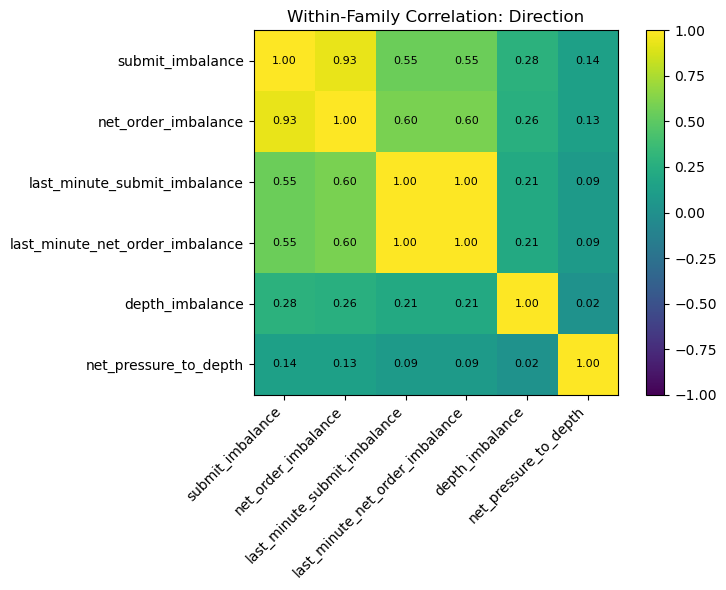

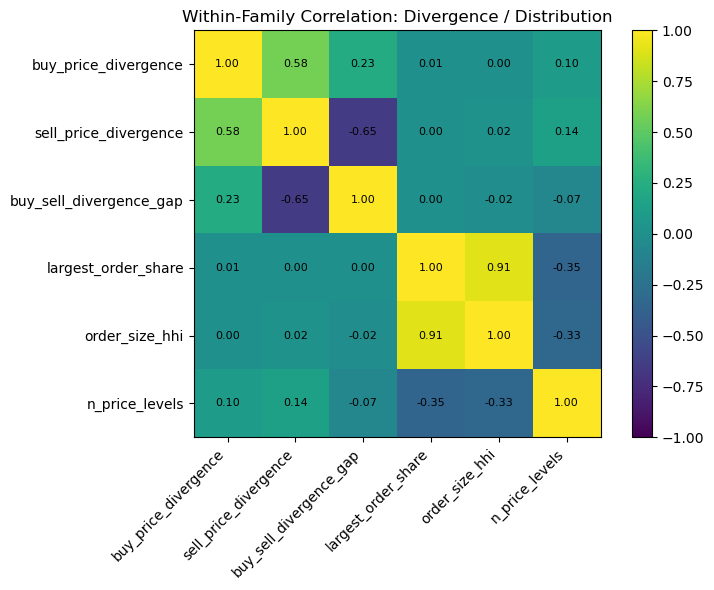

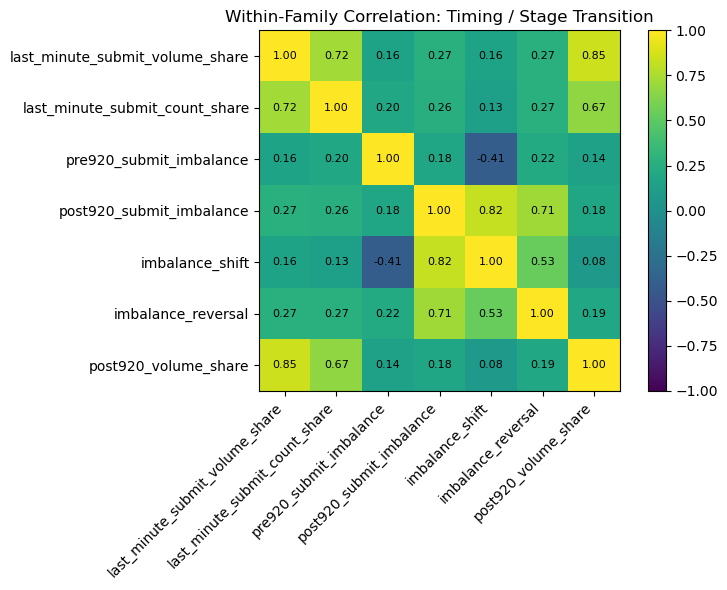

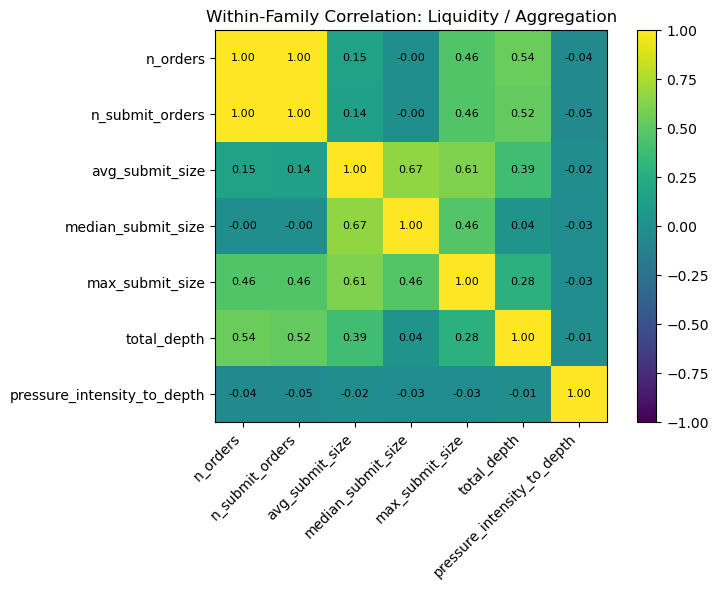

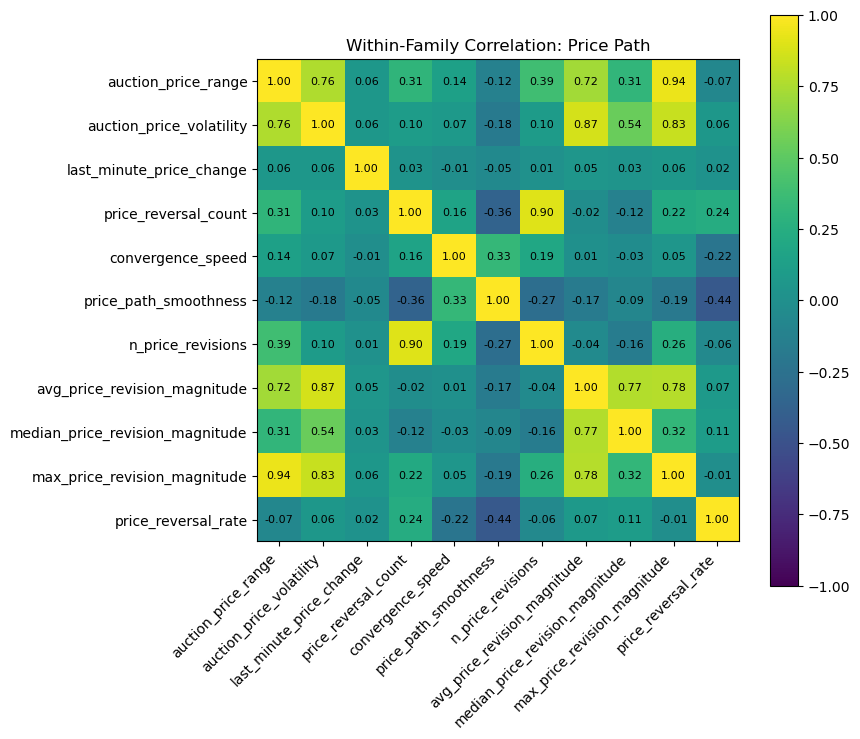

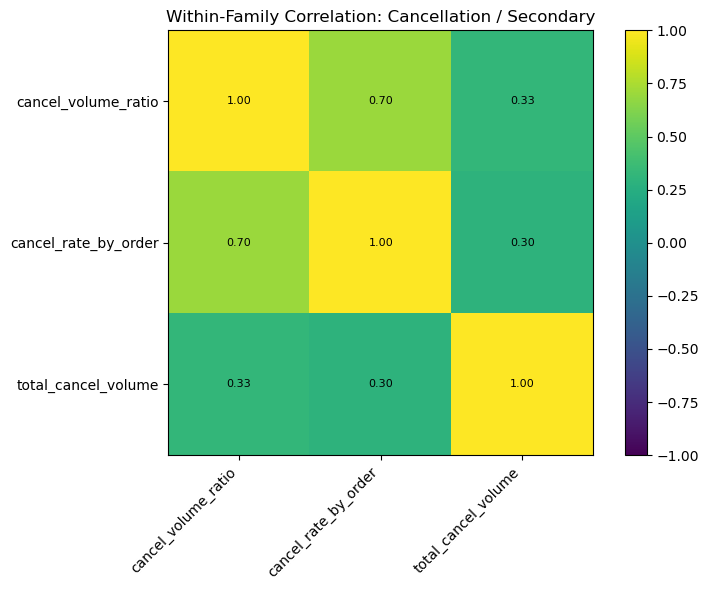

In [217]:
def plot_corr_heatmap(df, cols, title):
    existing = [c for c in cols if c in df.columns]

    if len(existing) < 2:
        print(f"Not enough features for {title}")
        return

    corr = df[existing].corr()

    fig, ax = plt.subplots(figsize=(max(8, len(existing) * 0.8), max(6, len(existing) * 0.7)))

    im = ax.imshow(corr, vmin=-1, vmax=1)

    ax.set_xticks(range(len(existing)))
    ax.set_yticks(range(len(existing)))
    ax.set_xticklabels(existing, rotation=45, ha="right")
    ax.set_yticklabels(existing)

    ax.set_title(title)

    for i in range(len(existing)):
        for j in range(len(existing)):
            value = corr.iloc[i, j]
            if pd.notna(value):
                ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8)

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()


for family, cols in feature_family.items():
    plot_corr_heatmap(
        feature_df,
        cols,
        f"Within-Family Correlation: {family}"
    )

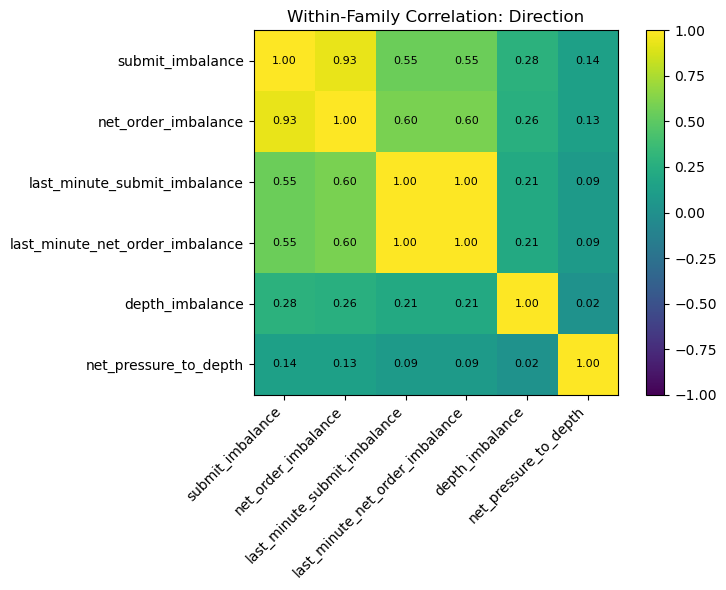

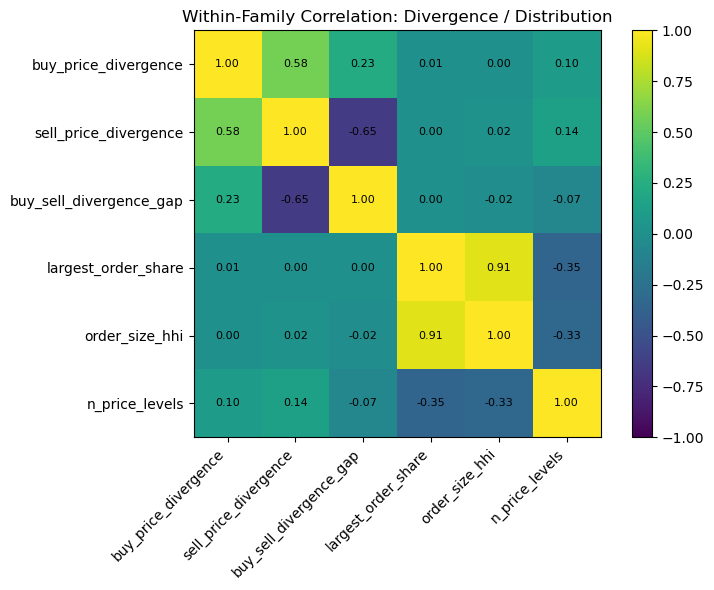

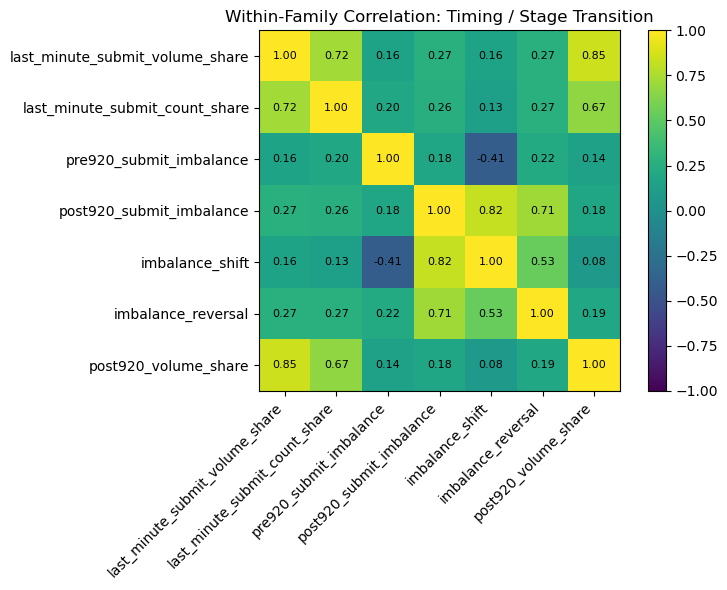

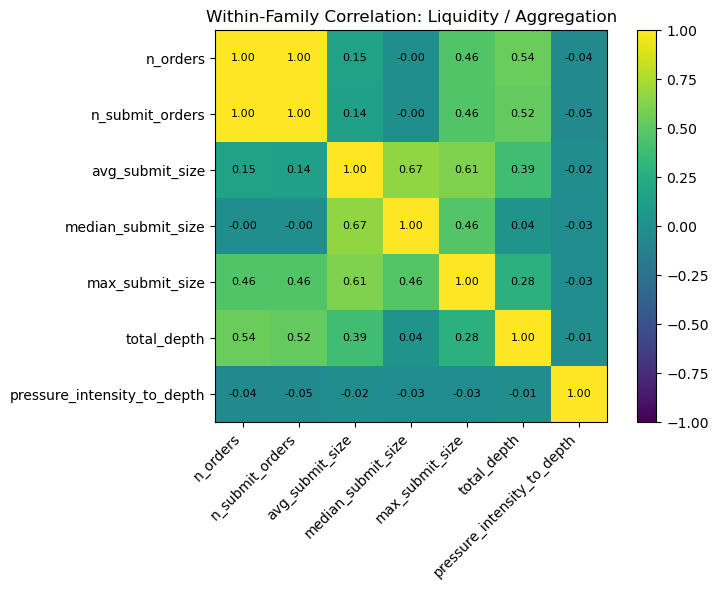

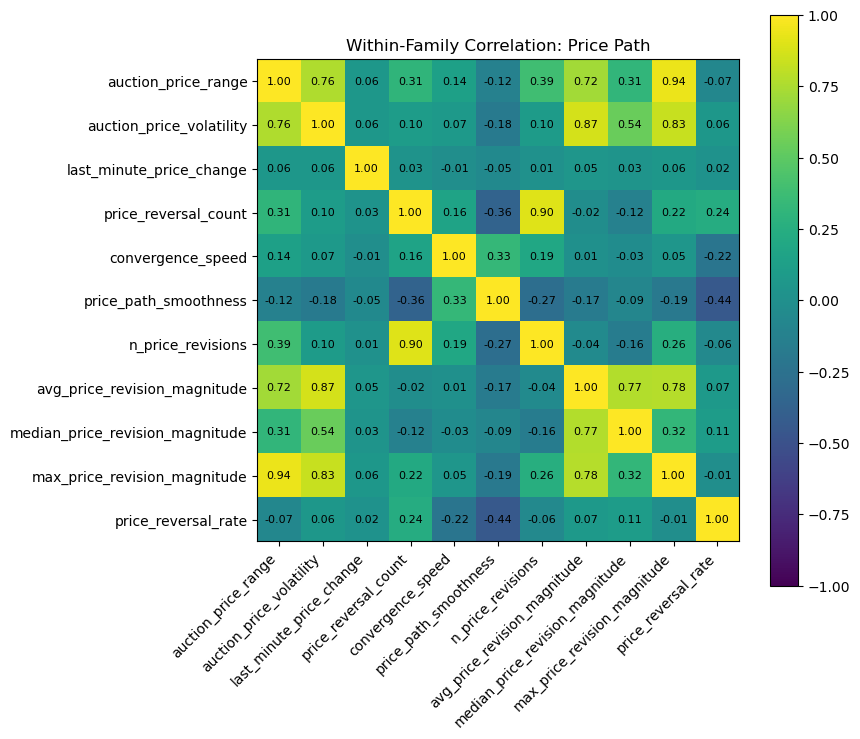

In [218]:
# Within-family correlation heatmaps
for family, cols in feature_family.items():
    if family == "Cancellation / Secondary":
        continue

    plot_corr_heatmap(
        feature_df,
        cols,
        f"Within-Family Correlation: {family}"
    )


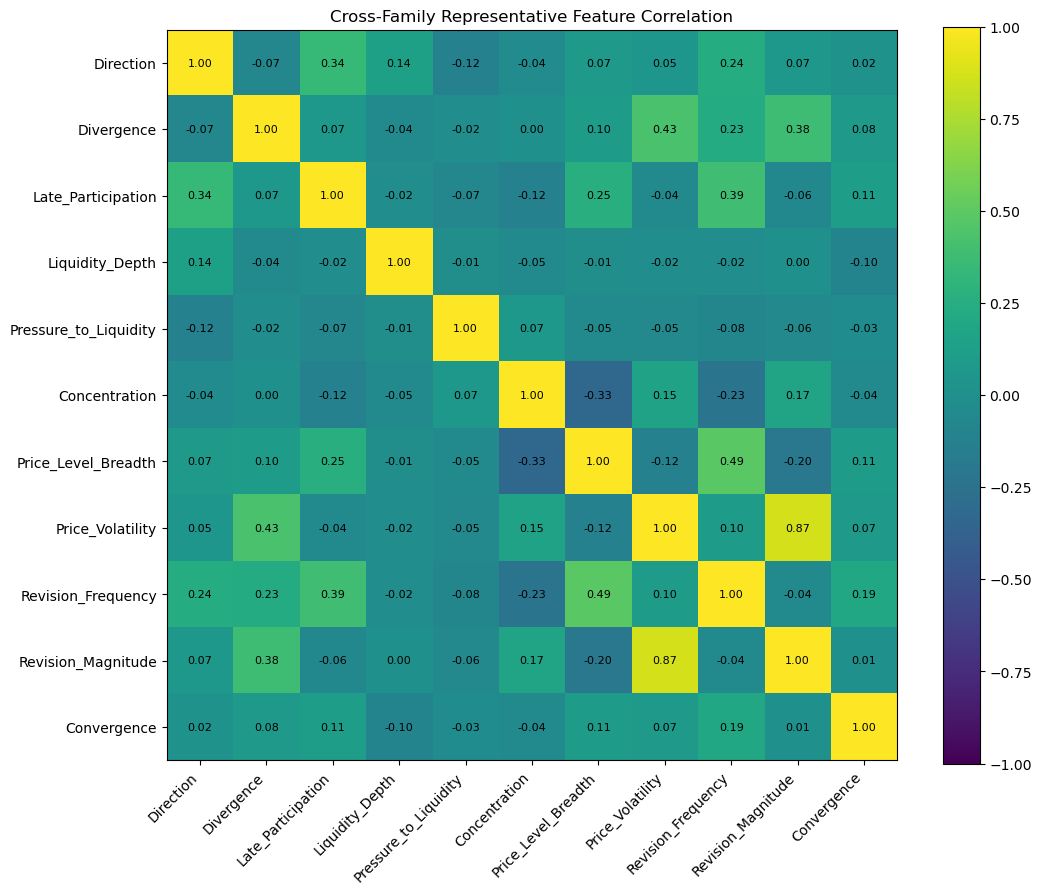

In [219]:
# Cross-family representative feature map
representative_features = {
    "Direction": "net_order_imbalance",
    "Divergence": "buy_price_divergence",
    "Late_Participation": "post920_volume_share",
    "Liquidity_Depth": "total_depth",
    "Pressure_to_Liquidity": "pressure_intensity_to_depth",
    "Concentration": "order_size_hhi",
    "Price_Level_Breadth": "n_price_levels",
    "Price_Volatility": "auction_price_volatility",
    "Revision_Frequency": "n_price_revisions",
    "Revision_Magnitude": "avg_price_revision_magnitude",
    "Convergence": "convergence_speed",
}

rep_cols = {
    label: col
    for label, col in representative_features.items()
    if col in feature_df.columns
}

rep_df = feature_df[list(rep_cols.values())].copy()
rep_df.columns = list(rep_cols.keys())

rep_corr = rep_df.corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(rep_corr, vmin=-1, vmax=1)

ax.set_xticks(range(len(rep_corr.columns)))
ax.set_yticks(range(len(rep_corr.index)))
ax.set_xticklabels(rep_corr.columns, rotation=45, ha="right")
ax.set_yticklabels(rep_corr.index)
ax.set_title("Cross-Family Representative Feature Correlation")

for i in range(len(rep_corr.index)):
    for j in range(len(rep_corr.columns)):
        value = rep_corr.iloc[i, j]
        if pd.notna(value):
            ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


## Optional Exploratory Mechanism Checks

The following state analyses are kept as optional interpretation checks. They are useful for explaining why several feature families may matter, but they should **not** replace the next notebook's target-aware single-factor evaluation against `ret_0930_0935`.


In [220]:
# ============================================================
# Optional State 1: Divergence × Late-Stage Participation
# ============================================================

state_df = feature_df.copy()

divergence_feature = "buy_price_divergence"
late_participation_feature = "post920_volume_share"

state_df["divergence_state"] = np.where(
    state_df[divergence_feature] >= state_df[divergence_feature].median(),
    "High Divergence",
    "Low Divergence"
)

state_df["late_participation_state"] = np.where(
    state_df[late_participation_feature] >= state_df[late_participation_feature].median(),
    "High Late Participation",
    "Low Late Participation"
)

state_df["auction_state"] = (
    state_df["divergence_state"] + " × " + state_df["late_participation_state"]
)

state_order = [
    "Low Divergence × Low Late Participation",
    "Low Divergence × High Late Participation",
    "High Divergence × Low Late Participation",
    "High Divergence × High Late Participation",
]

state_df["auction_state"] = pd.Categorical(
    state_df["auction_state"],
    categories=state_order,
    ordered=True
)

state_summary = (
    state_df
    .groupby("auction_state", observed=True)
    .agg(
        n_stock_days=("code", "size"),
        avg_price_volatility=("auction_price_volatility", "mean"),
        avg_price_reversal=("price_reversal_count", "mean"),
        avg_convergence_speed=("convergence_speed", "mean"),
        avg_path_smoothness=("price_path_smoothness", "mean"),
    )
    .reindex(state_order)
)

display(state_summary.round(4))


,n_stock_days,avg_price_volatility,avg_price_reversal,avg_convergence_speed,avg_path_smoothness
auction_state,,,,,
Low Divergence × Low Late Participation,878,0.0030,3.2370,0.8608,0.4366
Low Divergence × High Late Participation,717,0.0031,5.1564,0.9441,0.4361
High Divergence × Low Late Participation,717,0.0098,4.5732,0.9167,0.3643
High Divergence × High Late Participation,878,0.0068,7.3032,0.9611,0.3642


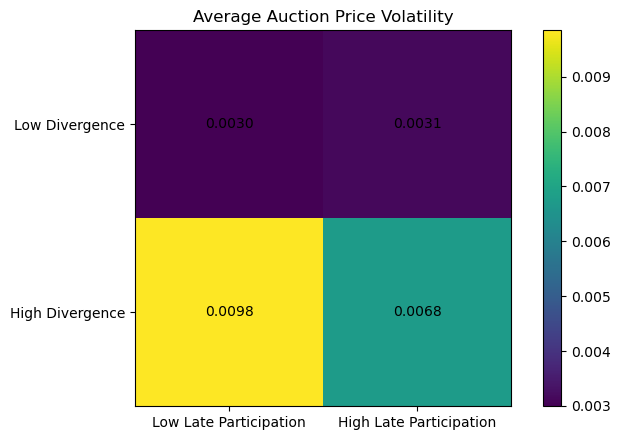

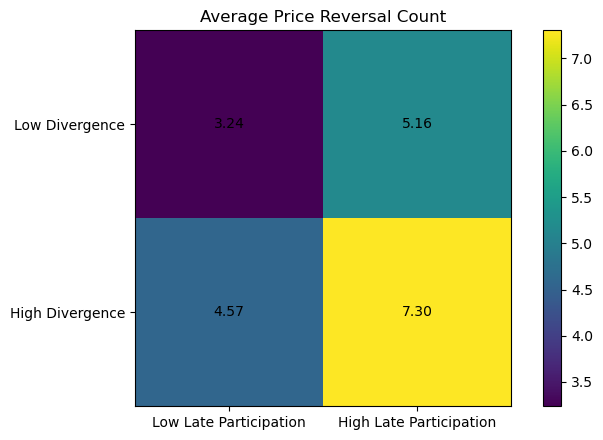

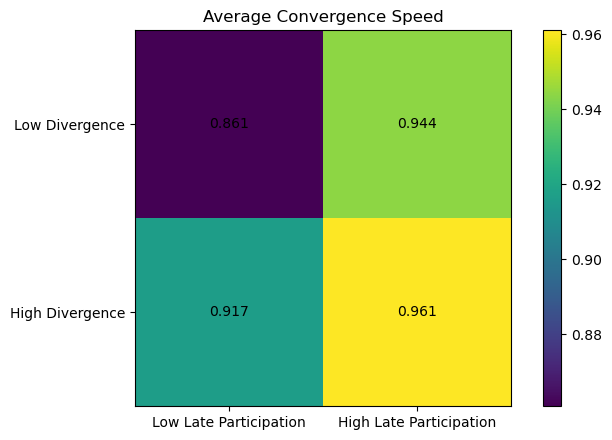

In [221]:
# Helper for 2×2 state heatmaps

def plot_2x2_state_heatmap(df, row_col, col_col, value_col, row_order, col_order, title, value_format=".3f"):
    matrix = (
        df
        .pivot_table(
            index=row_col,
            columns=col_col,
            values=value_col,
            aggfunc="mean",
            observed=True,
        )
        .reindex(index=row_order, columns=col_order)
    )

    fig, ax = plt.subplots(figsize=(7, 4.5))
    im = ax.imshow(matrix.values)

    ax.set_xticks(range(matrix.shape[1]))
    ax.set_yticks(range(matrix.shape[0]))
    ax.set_xticklabels(matrix.columns)
    ax.set_yticklabels(matrix.index)
    ax.set_title(title)

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(j, i, format(matrix.iloc[i, j], value_format), ha="center", va="center")

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

plot_2x2_state_heatmap(
    state_df,
    "divergence_state",
    "late_participation_state",
    "auction_price_volatility",
    ["Low Divergence", "High Divergence"],
    ["Low Late Participation", "High Late Participation"],
    "Average Auction Price Volatility",
    ".4f"
)

plot_2x2_state_heatmap(
    state_df,
    "divergence_state",
    "late_participation_state",
    "price_reversal_count",
    ["Low Divergence", "High Divergence"],
    ["Low Late Participation", "High Late Participation"],
    "Average Price Reversal Count",
    ".2f"
)

plot_2x2_state_heatmap(
    state_df,
    "divergence_state",
    "late_participation_state",
    "convergence_speed",
    ["Low Divergence", "High Divergence"],
    ["Low Late Participation", "High Late Participation"],
    "Average Convergence Speed",
    ".3f"
)


In [222]:
# ============================================================
# Optional State 2: Updating Magnitude × Late-Stage Participation
# ============================================================

updating_state_df = feature_df.copy()
updating_state_df["updating_magnitude"] = updating_state_df["imbalance_shift"].abs()

updating_state_df["updating_state"] = np.where(
    updating_state_df["updating_magnitude"] >= updating_state_df["updating_magnitude"].median(),
    "High Updating",
    "Low Updating"
)

updating_state_df["late_participation_state"] = np.where(
    updating_state_df["post920_volume_share"] >= updating_state_df["post920_volume_share"].median(),
    "High Late Participation",
    "Low Late Participation"
)

updating_state_df["auction_state_2"] = (
    updating_state_df["updating_state"] + " × " + updating_state_df["late_participation_state"]
)

state_order_2 = [
    "Low Updating × Low Late Participation",
    "Low Updating × High Late Participation",
    "High Updating × Low Late Participation",
    "High Updating × High Late Participation",
]

updating_state_df["auction_state_2"] = pd.Categorical(
    updating_state_df["auction_state_2"],
    categories=state_order_2,
    ordered=True,
)

state_summary_2 = (
    updating_state_df
    .groupby("auction_state_2", observed=True)
    .agg(
        n_stock_days=("code", "size"),
        avg_updating_magnitude=("updating_magnitude", "mean"),
        avg_price_volatility=("auction_price_volatility", "mean"),
        avg_price_reversal=("price_reversal_count", "mean"),
        avg_convergence_speed=("convergence_speed", "mean"),
    )
    .reindex(state_order_2)
)

display(state_summary_2.round(4))


,n_stock_days,avg_updating_magnitude,avg_price_volatility,avg_price_reversal,avg_convergence_speed
auction_state_2,,,,,
Low Updating × Low Late Participation,883,0.1460,0.0056,3.7807,0.8723
Low Updating × High Late Participation,712,0.1500,0.0048,6.2676,0.9563
High Updating × Low Late Participation,712,0.6091,0.0067,3.9119,0.9030
High Updating × High Late Participation,883,0.6402,0.0054,6.3920,0.9511


,n_stock_days,avg_divergence,avg_n_price_levels,avg_n_price_revisions,avg_revision_magnitude,avg_price_reversal,avg_price_reversal_rate,avg_convergence_speed
auction_state_3,,,,,,,,
Low Divergence × Low Price-Level Breadth,943,0.0259,84.8558,4.9671,0.0071,2.8891,0.5539,0.8670
Low Divergence × High Price-Level Breadth,652,0.0296,223.0475,11.2607,0.0042,5.8405,0.5284,0.9433
High Divergence × Low Price-Level Breadth,646,0.0579,88.2322,8.1889,0.0159,4.1588,0.5133,0.9227
High Divergence × High Price-Level Breadth,949,0.0572,227.3962,14.8156,0.0081,7.3681,0.5058,0.9536


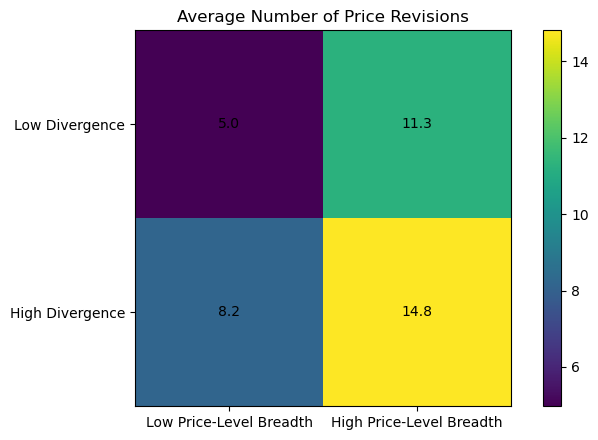

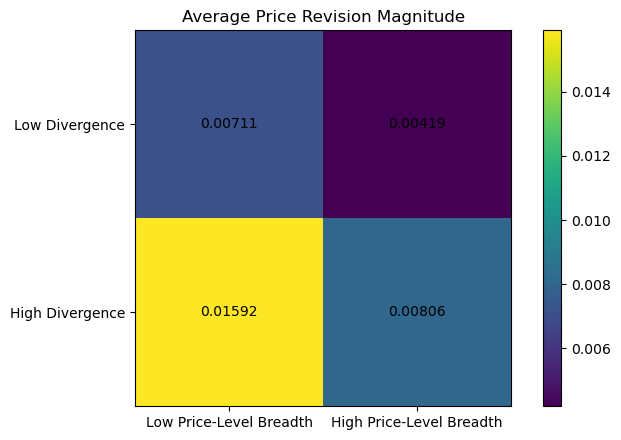

In [223]:
# ============================================================
# Optional State 3: Divergence × Price-Level Breadth
# ============================================================

breadth_state_df = feature_df.copy()

breadth_state_df["divergence_state"] = np.where(
    breadth_state_df["buy_price_divergence"] >= breadth_state_df["buy_price_divergence"].median(),
    "High Divergence",
    "Low Divergence"
)

breadth_state_df["breadth_state"] = np.where(
    breadth_state_df["n_price_levels"] >= breadth_state_df["n_price_levels"].median(),
    "High Price-Level Breadth",
    "Low Price-Level Breadth"
)

breadth_state_df["auction_state_3"] = (
    breadth_state_df["divergence_state"] + " × " + breadth_state_df["breadth_state"]
)

state_order_3 = [
    "Low Divergence × Low Price-Level Breadth",
    "Low Divergence × High Price-Level Breadth",
    "High Divergence × Low Price-Level Breadth",
    "High Divergence × High Price-Level Breadth",
]

breadth_state_df["auction_state_3"] = pd.Categorical(
    breadth_state_df["auction_state_3"],
    categories=state_order_3,
    ordered=True,
)

state_summary_3 = (
    breadth_state_df
    .groupby("auction_state_3", observed=True)
    .agg(
        n_stock_days=("code", "size"),
        avg_divergence=("buy_price_divergence", "mean"),
        avg_n_price_levels=("n_price_levels", "mean"),
        avg_n_price_revisions=("n_price_revisions", "mean"),
        avg_revision_magnitude=("avg_price_revision_magnitude", "mean"),
        avg_price_reversal=("price_reversal_count", "mean"),
        avg_price_reversal_rate=("price_reversal_rate", "mean"),
        avg_convergence_speed=("convergence_speed", "mean"),
    )
    .reindex(state_order_3)
)

display(state_summary_3.round(4))

plot_2x2_state_heatmap(
    breadth_state_df,
    "divergence_state",
    "breadth_state",
    "n_price_revisions",
    ["Low Divergence", "High Divergence"],
    ["Low Price-Level Breadth", "High Price-Level Breadth"],
    "Average Number of Price Revisions",
    ".1f"
)

plot_2x2_state_heatmap(
    breadth_state_df,
    "divergence_state",
    "breadth_state",
    "avg_price_revision_magnitude",
    ["Low Divergence", "High Divergence"],
    ["Low Price-Level Breadth", "High Price-Level Breadth"],
    "Average Price Revision Magnitude",
    ".5f"
)


## Single-Stock Multi-Day Auction Process

To complement the cross-sectional feature analysis, this section visualizes the intraday auction process for a single stock across multiple trading days.

The objective is to examine whether auction price formation, order-book imbalance, and visible depth exhibit persistent or heterogeneous temporal patterns across stock-days.

Three dimensions are considered:

- **Mid Price Path**: evolution of the best bid-ask midpoint during the auction.
- **Depth Imbalance**: directional asymmetry between visible bid and ask depth.
- **Total Depth**: evolution of visible order-book liquidity.

This visualization provides a path-level interpretation of the stock-day features constructed above.

Selected stock: 600158.SH
Selected dates: [Timestamp('2026-03-02 00:00:00'), Timestamp('2026-03-03 00:00:00'), Timestamp('2026-03-04 00:00:00'), Timestamp('2026-03-05 00:00:00'), Timestamp('2026-03-06 00:00:00')]


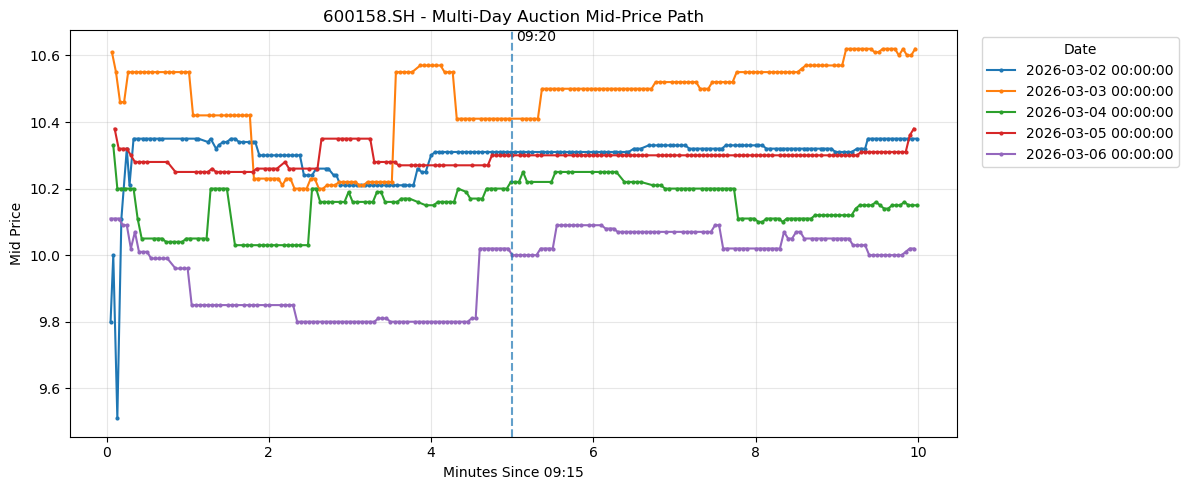

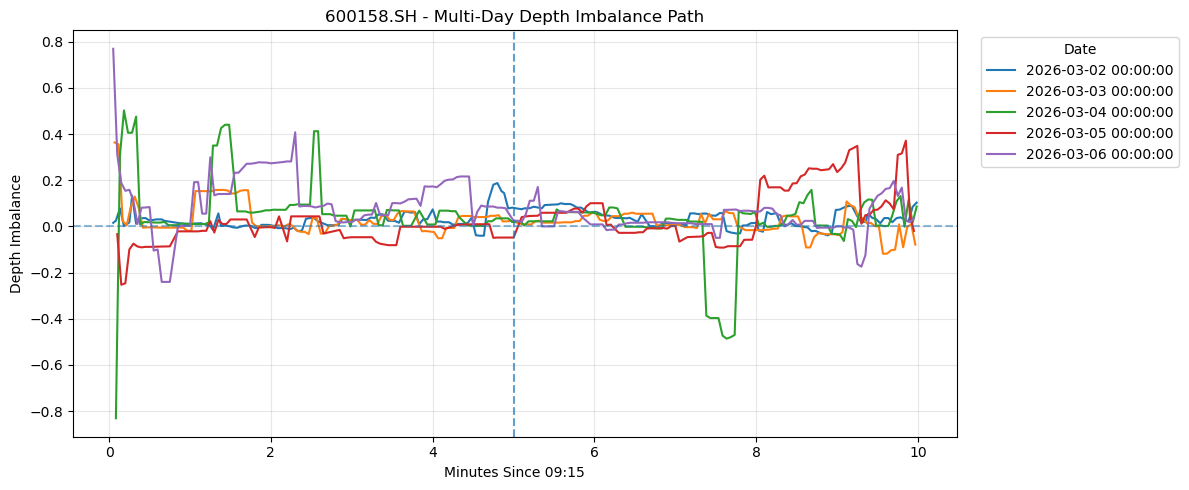

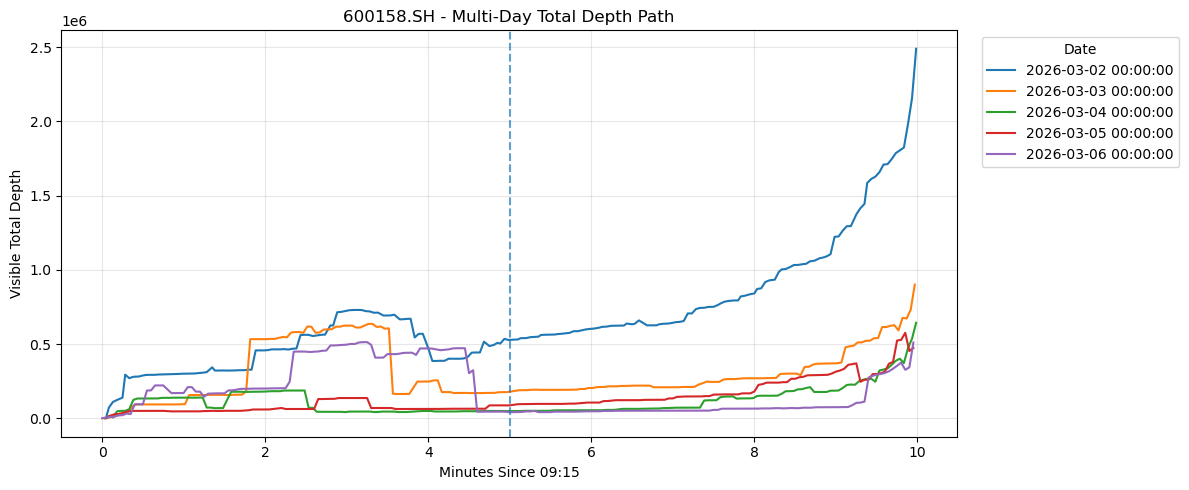

In [224]:
# ============================================================
# Single-Stock Multi-Day Auction Process
# ============================================================

plot_df = qtick_auction.copy()

# ------------------------------------------------------------
# 1. Reconstruct datetime if needed
# ------------------------------------------------------------

if "datetime" not in plot_df.columns:
    plot_df["datetime"] = pd.to_datetime(
        plot_df["date"].astype(str)
        + " "
        + plot_df["time"].astype(str)
    )

# ------------------------------------------------------------
# 2. Construct path variables
# ------------------------------------------------------------

bp0 = (
    pd.to_numeric(plot_df["bp0"], errors="coerce")
    .replace(0, np.nan)
)

ap0 = (
    pd.to_numeric(plot_df["ap0"], errors="coerce")
    .replace(0, np.nan)
)

plot_df["mid_price"] = (
    bp0 + ap0
) / 2


# Visible depth: bp0-bp9 / ap0-ap9
bid_volume_cols = [
    f"bv{i}"
    for i in range(10)
    if f"bv{i}" in plot_df.columns
]

ask_volume_cols = [
    f"av{i}"
    for i in range(10)
    if f"av{i}" in plot_df.columns
]


plot_df["bid_depth"] = (
    plot_df[bid_volume_cols]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .sum(axis=1)
)

plot_df["ask_depth"] = (
    plot_df[ask_volume_cols]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .sum(axis=1)
)

plot_df["total_depth"] = (
    plot_df["bid_depth"]
    + plot_df["ask_depth"]
)

plot_df["depth_imbalance"] = np.where(
    plot_df["total_depth"] > 0,
    (
        plot_df["bid_depth"]
        - plot_df["ask_depth"]
    )
    / plot_df["total_depth"],
    np.nan
)


# ------------------------------------------------------------
# 3. Select one stock and multiple dates
# ------------------------------------------------------------

selected_code = (
    plot_df["code"]
    .value_counts()
    .index[0]
)

available_dates = (
    plot_df.loc[
        plot_df["code"] == selected_code,
        "date"
    ]
    .drop_duplicates()
    .sort_values()
)

selected_dates = available_dates[:5]


single_stock_df = (
    plot_df[
        (plot_df["code"] == selected_code)
        & (plot_df["date"].isin(selected_dates))
    ]
    .copy()
)


print("Selected stock:", selected_code)

print(
    "Selected dates:",
    list(selected_dates)
)


# ------------------------------------------------------------
# 4. Create relative auction time
# ------------------------------------------------------------

single_stock_df["auction_minute"] = (
    single_stock_df["datetime"]
    - single_stock_df["datetime"].dt.normalize()
    - pd.Timedelta(hours=9, minutes=15)
).dt.total_seconds() / 60


# ============================================================
# Plot 1: Mid Price Path
# ============================================================

plt.figure(figsize=(12, 5))

for date, g in single_stock_df.groupby("date"):

    g = g.sort_values("datetime")

    plt.plot(
        g["auction_minute"],
        g["mid_price"],
        marker="o",
        markersize=2,
        label=str(date)
    )

plt.axvline(
    5,
    linestyle="--",
    alpha=0.7
)

plt.text(
    5.05,
    plt.ylim()[1],
    "09:20",
    va="top"
)

plt.title(
    f"{selected_code} - Multi-Day Auction Mid-Price Path"
)

plt.xlabel(
    "Minutes Since 09:15"
)

plt.ylabel(
    "Mid Price"
)

plt.legend(
    title="Date",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# Plot 2: Depth Imbalance Path
# ============================================================

plt.figure(figsize=(12, 5))

for date, g in single_stock_df.groupby("date"):

    g = g.sort_values("datetime")

    plt.plot(
        g["auction_minute"],
        g["depth_imbalance"],
        label=str(date)
    )

plt.axhline(
    0,
    linestyle="--",
    alpha=0.5
)

plt.axvline(
    5,
    linestyle="--",
    alpha=0.7
)

plt.title(
    f"{selected_code} - Multi-Day Depth Imbalance Path"
)

plt.xlabel(
    "Minutes Since 09:15"
)

plt.ylabel(
    "Depth Imbalance"
)

plt.legend(
    title="Date",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# Plot 3: Total Depth Path
# ============================================================

plt.figure(figsize=(12, 5))

for date, g in single_stock_df.groupby("date"):

    g = g.sort_values("datetime")

    plt.plot(
        g["auction_minute"],
        g["total_depth"],
        label=str(date)
    )

plt.axvline(
    5,
    linestyle="--",
    alpha=0.7
)

plt.title(
    f"{selected_code} - Multi-Day Total Depth Path"
)

plt.xlabel(
    "Minutes Since 09:15"
)

plt.ylabel(
    "Visible Total Depth"
)

plt.legend(
    title="Date",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()

### Week 4 Feature Coverage Check

The final feature table now covers the required Week 4 feature directions:

- **Price Features**: auction price range, volatility, last-minute price change, price revision features
- **Order Features**: submitted volume, buy/sell volume, imbalance, order size, price-level distribution
- **Cancellation Features**: cancellation volume, cancellation ratio, order-level cancellation rate
- **Execution Features**: auction trade volume, trade amount, VWAP, trade count
- **Order Book Features**: bid/ask depth, depth imbalance, pressure-to-liquidity
- **Historical Features**: previous-day return, previous-day amount, rolling volatility, limit-distance controls

Market-level and sector-level features are not included at this stage due to data availability and are reserved for later model enhancement.

## Week 4 Output and Next Step

This notebook should stop at a prediction-ready auction feature table.

**Keep for next stage:**
- `feature_df`: stock-day auction feature table
- `feature_registry`: feature family / priority metadata
- `core_candidate_features`: first-pass candidate feature list
- `secondary_candidate_features`: cancellation and other lower-priority candidates

**Next notebook:** `05_5min_return_single_factor.ipynb`

Main task:
1. Construct `ret_0930_0935 = price_09:35 / price_09:30 - 1`.
2. Merge the 5-minute return label with `feature_df`.
3. Evaluate each feature as a single factor using IC, Rank IC, direction accuracy, and grouped returns.
4. Use target-aware results to decide which features survive.


In [225]:
# ============================================================
# Export Prediction-Ready Auction Features
# ============================================================

from pathlib import Path

AUCTION_FEATURE_PATH = Path("04b_holdout_auction_features_prediction_ready.csv")

AUCTION_FEATURE_PATH.parent.mkdir(
    parents=True,
    exist_ok=True
)

auction_feature_export = feature_df.copy()
auction_feature_export["date"] = pd.to_datetime(auction_feature_export["date"])
auction_feature_export = auction_feature_export.loc[
    auction_feature_export["date"].between(
        HOLDOUT_START_DATE, HOLDOUT_END_DATE, inclusive="both"
    )
].copy()
assert not auction_feature_export.empty, "No holdout rows reached the final feature table."

auction_feature_export["date"] = (
    pd.to_datetime(
        auction_feature_export["date"]
    )
    .dt.strftime("%Y-%m-%d")
)

# Ensure one row per code-date
duplicate_keys = (
    auction_feature_export
    .duplicated(
        subset=[
            "code",
            "date"
        ]
    )
    .sum()
)

if duplicate_keys > 0:
    raise ValueError(
        "auction_feature_export contains "
        f"{duplicate_keys} duplicate code-date rows."
    )

required_prediction_columns = [
    "code",
    "date",
    "auction_price",
    "auction_price_nunique",
    "auction_trade_count",
    "auction_trade_volume",
    "auction_trade_amount",
    "auction_vwap",
    "large_order_amount_share",
    "large_order_count_share",
    "large_order_imbalance",
    "post920_large_order_imbalance",
    "top5_order_amount_share",
    "order_amount_hhi"
]

missing_prediction_columns = [
    column
    for column in required_prediction_columns
    if column not in auction_feature_export.columns
]

if missing_prediction_columns:
    raise KeyError(
        "Missing prediction-ready columns: "
        f"{missing_prediction_columns}"
    )

# Validate price scale before export
price_scale_check = (
    auction_feature_export[
        "auction_price"
    ]
    .dropna()
)

if (
    price_scale_check.median() > 1000
    or price_scale_check.median() <= 0
):
    raise ValueError(
        "auction_price appears to use an incorrect scale. "
        f"Median={price_scale_check.median()}"
    )

_atomic_to_csv(auction_feature_export, AUCTION_FEATURE_PATH, index=False)

print(
    "Auction features exported to:",
    AUCTION_FEATURE_PATH.resolve()
)

print(
    "Export shape:",
    auction_feature_export.shape
)

print(
    "Stocks:",
    auction_feature_export[
        "code"
    ].nunique()
)

print(
    "Dates:",
    auction_feature_export[
        "date"
    ].nunique()
)

print(
    "Duplicate code-date rows:",
    duplicate_keys
)

print(
    "Auction-price coverage:",
    auction_feature_export[
        "auction_price"
    ].notna().mean()
)

display(
    auction_feature_export[
        required_prediction_columns
    ].head(20)
)


Auction features exported to: C:\Users\work\OneDrive\Documents\level2-research\notebooks\04b_holdout_auction_features_prediction_ready.csv
Export shape: (1990, 82)
Stocks: 40
Dates: 50
Duplicate code-date rows: 0
Auction-price coverage: 0.9954773869346734


,code,date,auction_price,auction_price_nunique,auction_trade_count,auction_trade_volume,auction_trade_amount,auction_vwap,large_order_amount_share,large_order_count_share,large_order_imbalance,post920_large_order_imbalance,top5_order_amount_share,order_amount_hhi
30,000713.SZ,2026-04-14,6.40,1.0,15.0,17300.0,110720.0,6.40,0.251198,0.011848,-1.000000,-1.000000,0.251198,0.020029
31,000713.SZ,2026-04-15,6.43,1.0,17.0,36900.0,237267.0,6.43,0.268444,0.011468,-1.000000,0.000000,0.268444,0.023636
32,000713.SZ,2026-04-16,6.47,1.0,22.0,16400.0,106108.0,6.47,0.251957,0.010661,-1.000000,-1.000000,0.251957,0.019412
33,000713.SZ,2026-04-17,6.59,1.0,34.0,36200.0,238558.0,6.59,0.298806,0.009363,-0.662406,1.000000,0.298806,0.025727
34,000713.SZ,2026-04-20,6.53,1.0,27.0,24100.0,157373.0,6.53,0.451130,0.018476,-0.479495,-1.000000,0.335515,0.036236
35,000713.SZ,2026-04-21,6.50,1.0,18.0,26700.0,173550.0,6.50,0.308946,0.009050,-1.000000,0.000000,0.335807,0.035267
36,000713.SZ,2026-04-22,6.45,1.0,17.0,12100.0,78045.0,6.45,0.304982,0.007160,-1.000000,0.000000,0.367797,0.042755
37,000713.SZ,2026-04-23,6.42,1.0,10.0,3600.0,23112.0,6.42,0.287547,0.009368,-1.000000,0.000000,0.312583,0.032961
38,000713.SZ,2026-04-24,6.48,1.0,71.0,117000.0,758160.0,6.48,0.291276,0.009398,-1.000000,0.000000,0.291276,0.025723
39,000713.SZ,2026-04-27,6.60,1.0,70.0,86400.0,570240.0,6.60,0.418614,0.016129,-0.365284,-1.000000,0.294665,0.028493


In [226]:
# ============================================================
# Final Model-Ready Cleanup
# ============================================================

# 1. Remove diagnostic/non-predictive datetime fields
feature_df = feature_df.drop(
    columns=[
        "execution_first_time",
        "execution_last_time"
    ],
    errors="ignore"
)

# 2. Remove execution-price duplicate
feature_df = feature_df.drop(
    columns=[
        "auction_avg_trade_price"
    ],
    errors="ignore"
)

# 3. Preserve whether auction execution was observed
feature_df["has_auction_execution"] = (
    feature_df["auction_trade_count"]
    .notna()
    .astype(int)
)

# 4. No execution means zero count/volume/amount
execution_zero_cols = [
    "auction_trade_count",
    "auction_trade_volume",
    "auction_trade_amount"
]

feature_df[execution_zero_cols] = (
    feature_df[execution_zero_cols]
    .fillna(0)
)

# 5. Final structural validation
assert not feature_df.duplicated(["code", "date"]).any()
assert not np.isinf(
    feature_df.select_dtypes(include=np.number)
).any().any()

print("Final feature_df shape:", feature_df.shape)
print("Stocks:", feature_df["code"].nunique())
print("Dates:", feature_df["date"].nunique())

display(
    feature_df[
        [
            "auction_trade_count",
            "auction_trade_volume",
            "auction_trade_amount",
            "auction_vwap",
            "has_auction_execution"
        ]
    ].isna().mean().rename("missing_rate")
)

Final feature_df shape: (3190, 81)
Stocks: 40
Dates: 80


auction_trade_count      0.00000
auction_trade_volume     0.00000
auction_trade_amount     0.00000
auction_vwap             0.00627
has_auction_execution    0.00000
Name: missing_rate, dtype: float64

In [227]:
# ============================================================
# Safe canonical holdout exports — old 04_* files are untouched
# ============================================================
holdout_feature_df = feature_df.copy()
holdout_feature_df["date"] = pd.to_datetime(
    holdout_feature_df["date"], errors="raise"
).dt.tz_localize(None)
holdout_feature_df = holdout_feature_df.loc[
    holdout_feature_df["date"].between(
        HOLDOUT_START_DATE, HOLDOUT_END_DATE, inclusive="both"
    )
].copy()

assert not holdout_feature_df.empty, "No true holdout rows are available."
assert holdout_feature_df["date"].min() > DEVELOPMENT_END_DATE
assert not holdout_feature_df.duplicated(["code", "date"]).any()
assert set(holdout_feature_df["code"]).issubset(set(sample_codes))

_atomic_to_csv(
    holdout_feature_df, "04b_holdout_auction_feature_table.csv", index=False
)
_atomic_to_csv(
    feature_registry, "04b_holdout_feature_registry.csv", index=False
)

print("Saved isolated holdout files:")
print("- 04b_holdout_auction_feature_table.csv")
print("- 04b_holdout_feature_registry.csv")
print("Shape:", holdout_feature_df.shape)
print("Dates:", holdout_feature_df["date"].nunique())
print("Stocks:", holdout_feature_df["code"].nunique())


Saved isolated holdout files:
- 04b_holdout_auction_feature_table.csv
- 04b_holdout_feature_registry.csv
Shape: (1990, 81)
Dates: 50
Stocks: 40


In [228]:
export_check = pd.read_csv(
    AUCTION_FEATURE_PATH
)

print(
    [
        column
        for column in export_check.columns
        if (
            "auction_price" in column
            or "auction_trade" in column
        )
    ]
)

['auction_price_range', 'auction_price_volatility', 'auction_trade_count', 'auction_trade_volume', 'auction_trade_amount', 'auction_price', 'auction_price_nunique', 'auction_price_consistent']


In [229]:
# ============================================================
# 8.2 Canonical Submit-Order Event Table
# ============================================================

from pathlib import Path

LARGE_ORDER_PRICE_SCALE = 10_000.0

required_large_order_event_columns = {
    "code",
    "date",
    "clock",
    "event_price",
    "event_volume",
    "is_submit",
    "is_buy",
    "is_sell",
}

missing_large_order_event_columns = sorted(
    required_large_order_event_columns.difference(
        events_auction.columns
    )
)

if missing_large_order_event_columns:
    raise KeyError(
        "events_auction missing factor-depth columns: "
        f"{missing_large_order_event_columns}"
    )

large_order_event_df = (
    events_auction.loc[
        events_auction["is_submit"].eq(1)
    ]
    .copy()
)

large_order_event_df["date"] = pd.to_datetime(
    large_order_event_df["date"]
).dt.normalize()

large_order_event_df["normalized_order_price"] = (
    pd.to_numeric(
        large_order_event_df["event_price"],
        errors="coerce",
    )
    /
    LARGE_ORDER_PRICE_SCALE
)

large_order_event_df["order_volume"] = pd.to_numeric(
    large_order_event_df["event_volume"],
    errors="coerce",
)

large_order_event_df["order_amount"] = (
    large_order_event_df["normalized_order_price"]
    *
    large_order_event_df["order_volume"]
)

# Convert clock to seconds after midnight so all window boundaries are explicit.
large_order_event_df["event_seconds"] = (
    pd.to_timedelta(
        large_order_event_df["clock"].astype(str)
    )
    .dt.total_seconds()
)

large_order_raw_n = len(large_order_event_df)

large_order_invalid_price_n = (
    ~np.isfinite(
        large_order_event_df["normalized_order_price"]
    )
    |
    large_order_event_df["normalized_order_price"].le(0)
).sum()

large_order_invalid_volume_n = (
    ~np.isfinite(
        large_order_event_df["order_volume"]
    )
    |
    large_order_event_df["order_volume"].le(0)
).sum()

large_order_unknown_side_n = (
    (
        large_order_event_df["is_buy"].eq(1).astype(int)
        +
        large_order_event_df["is_sell"].eq(1).astype(int)
    )
    != 1
).sum()

large_order_event_df = (
    large_order_event_df.loc[
        np.isfinite(
            large_order_event_df["normalized_order_price"]
        )
        &
        np.isfinite(
            large_order_event_df["order_volume"]
        )
        &
        np.isfinite(
            large_order_event_df["order_amount"]
        )
        &
        large_order_event_df["normalized_order_price"].gt(0)
        &
        large_order_event_df["order_volume"].gt(0)
        &
        large_order_event_df["order_amount"].gt(0)
        &
        large_order_event_df["event_seconds"].between(
            9 * 3600 + 15 * 60,
            9 * 3600 + 25 * 60,
            inclusive="both",
        )
        &
        (
            large_order_event_df["is_buy"].eq(1).astype(int)
            +
            large_order_event_df["is_sell"].eq(1).astype(int)
        ).eq(1)
    ]
    .copy()
)

if large_order_event_df.empty:
    raise ValueError(
        "No valid submit-order events remain for factor-depth analysis."
    )

large_order_event_quality = pd.DataFrame({
    "metric": [
        "raw_submit_events",
        "valid_submit_events",
        "invalid_price_rows",
        "invalid_volume_rows",
        "unknown_or_conflicting_side_rows",
        "n_stock_days",
        "n_dates",
        "n_stocks",
    ],
    "value": [
        large_order_raw_n,
        len(large_order_event_df),
        large_order_invalid_price_n,
        large_order_invalid_volume_n,
        large_order_unknown_side_n,
        large_order_event_df[
            ["code", "date"]
        ].drop_duplicates().shape[0],
        large_order_event_df["date"].nunique(),
        large_order_event_df["code"].nunique(),
    ],
})

display(large_order_event_quality)
display(large_order_event_df.head())


,metric,value
0,raw_submit_events,2222260
1,valid_submit_events,2222260
2,invalid_price_rows,0
3,invalid_volume_rows,0
4,unknown_or_conflicting_side_rows,0
5,n_stock_days,3190
6,n_dates,80
7,n_stocks,40


,code,date,time,datetime,clock,exchange,order_no,bs_flag,event_type,event_price,event_volume,source_table,is_submit,is_cancel,is_buy,is_sell,time_display,normalized_order_price,order_volume,order_amount,event_seconds
0,000713.SZ,2026-03-02,1970-01-01 09:15:00.030,2026-03-02 09:15:00.030000-01:00,09:15:00.030000,SZ,813,2,submit,77200.0,100,qorder,True,False,False,True,09:15:00.030,7.72,100,772.0,33300.03
1,000713.SZ,2026-03-02,1970-01-01 09:15:00.040,2026-03-02 09:15:00.040000-01:00,09:15:00.040000,SZ,2021,2,submit,71100.0,500,qorder,True,False,False,True,09:15:00.040,7.11,500,3555.0,33300.04
2,000713.SZ,2026-03-02,1970-01-01 09:15:00.050,2026-03-02 09:15:00.050000-01:00,09:15:00.050000,SZ,5280,2,submit,77200.0,1700,qorder,True,False,False,True,09:15:00.050,7.72,1700,13124.0,33300.05
3,000713.SZ,2026-03-02,1970-01-01 09:15:00.050,2026-03-02 09:15:00.050000-01:00,09:15:00.050000,SZ,5281,2,submit,71700.0,1700,qorder,True,False,False,True,09:15:00.050,7.17,1700,12189.0,33300.05
4,000713.SZ,2026-03-02,1970-01-01 09:15:00.050,2026-03-02 09:15:00.050000-01:00,09:15:00.050000,SZ,5285,1,submit,67800.0,1700,qorder,True,False,True,False,09:15:00.050,6.78,1700,11526.0,33300.05


# Part IX. Auction Surprise and Information Transmission

## 9.1 Research contract

This section creates a new, leakage-safe feature interface that follows each auction order through:

```text
submission → cancellation-adjusted commitment → opening execution
          → indicative-price response → stock-specific historical surprise
```

The section does not use the 09:30→09:35 return label. Fixed 500k classifications remain historical diagnostics; formal tail orders are defined from each stock's own prior-date order-amount distribution. The output is one row per `code-date` and is exported separately as `04_information_transmission_features.csv`.


In [230]:
# ============================================================
# 9.2 Canonical Order Lifecycle: submit, cancel, execute
# ============================================================


# Self-healing prerequisite: rebuild the canonical submit table when the
# separate 8.2 preparation cell was skipped in an interactive run.
if "large_order_event_df" not in globals():
    assert "events_auction" in globals(), (
        "events_auction is missing. Run the auction-event preparation first."
    )
    _required_submit_columns_92 = {
        "code", "date", "clock", "order_no", "bs_flag",
        "event_price", "event_volume", "is_submit", "is_buy", "is_sell",
    }
    _missing_submit_columns_92 = sorted(
        _required_submit_columns_92.difference(events_auction.columns)
    )
    assert not _missing_submit_columns_92, (
        f"events_auction is missing: {_missing_submit_columns_92}"
    )
    large_order_event_df = events_auction.loc[
        events_auction["is_submit"].eq(1)
    ].copy()
    large_order_event_df["date"] = pd.to_datetime(
        large_order_event_df["date"], errors="raise"
    ).dt.normalize()
    large_order_event_df["normalized_order_price"] = (
        pd.to_numeric(
            large_order_event_df["event_price"], errors="coerce"
        ) / 10_000.0
    )
    large_order_event_df["order_volume"] = pd.to_numeric(
        large_order_event_df["event_volume"], errors="coerce"
    )
    large_order_event_df["order_amount"] = (
        large_order_event_df["normalized_order_price"]
        * large_order_event_df["order_volume"]
    )
    large_order_event_df["event_seconds"] = pd.to_timedelta(
        large_order_event_df["clock"].astype(str)
    ).dt.total_seconds()
    _valid_side_92 = (
        large_order_event_df["is_buy"].eq(1).astype(int)
        + large_order_event_df["is_sell"].eq(1).astype(int)
    ).eq(1)
    large_order_event_df = large_order_event_df.loc[
        np.isfinite(large_order_event_df["normalized_order_price"])
        & np.isfinite(large_order_event_df["order_volume"])
        & large_order_event_df["normalized_order_price"].gt(0)
        & large_order_event_df["order_volume"].gt(0)
        & large_order_event_df["event_seconds"].between(
            9 * 3600 + 15 * 60,
            9 * 3600 + 25 * 60,
            inclusive="both",
        )
        & _valid_side_92
    ].copy()
    assert not large_order_event_df.empty, (
        "No valid submit events remain after rebuilding large_order_event_df."
    )
    print(
        "Rebuilt large_order_event_df inside 9.2:",
        large_order_event_df.shape,
    )


IT_PRICE_SCALE = 10_000.0
IT_HISTORY_DATES = 20
IT_MIN_HISTORY_DATES = 5
IT_TAIL_QUANTILE = 0.95
IT_EPS = 1e-12

required_it_objects = [
    "events_auction",
    "large_order_event_df",
    "qknock",
    "qtick_auction",
]
missing_it_objects = [name for name in required_it_objects if name not in globals()]
assert not missing_it_objects, (
    f"Missing Notebook 4 objects: {missing_it_objects}. "
    "Run the auction-event, qknock and qtick preparation cells first."
)

it_orders = large_order_event_df.copy()
it_orders["date"] = pd.to_datetime(it_orders["date"], errors="raise").dt.normalize()
it_orders["code"] = it_orders["code"].astype(str)
it_orders["order_no"] = pd.to_numeric(it_orders["order_no"], errors="coerce")
it_orders["submit_volume"] = pd.to_numeric(it_orders["order_volume"], errors="coerce")
it_orders["submit_price"] = pd.to_numeric(
    it_orders["normalized_order_price"], errors="coerce"
)
it_orders["submit_amount"] = it_orders["submit_price"] * it_orders["submit_volume"]

it_cancel = events_auction.loc[
    events_auction["is_cancel"].eq(1),
    ["code", "date", "order_no", "event_volume"],
].copy()
it_cancel["date"] = pd.to_datetime(it_cancel["date"], errors="raise").dt.normalize()
it_cancel["order_no"] = pd.to_numeric(it_cancel["order_no"], errors="coerce")
it_cancel["event_volume"] = pd.to_numeric(it_cancel["event_volume"], errors="coerce")
it_cancel = (
    it_cancel.groupby(["code", "date", "order_no"], as_index=False, observed=True)
    .agg(cancel_volume=("event_volume", "sum"))
)

# A nonzero qknock price with both sides present is treated as a real execution.
it_knock = qknock.copy()
it_knock["date"] = pd.to_datetime(it_knock["date"], errors="raise").dt.normalize()
it_knock["match_price"] = pd.to_numeric(it_knock["match_price"], errors="coerce")
it_knock["match_volume"] = pd.to_numeric(it_knock["match_volume"], errors="coerce")
it_knock["bid_order_no"] = pd.to_numeric(it_knock["bid_order_no"], errors="coerce")
it_knock["ask_order_no"] = pd.to_numeric(it_knock["ask_order_no"], errors="coerce")
it_execution = it_knock.loc[
    it_knock["match_price"].gt(0)
    & it_knock["match_volume"].gt(0)
    & it_knock["clock"].ge(pd.to_datetime("09:25:00").time())
    & it_knock["clock"].lt(pd.to_datetime("09:30:00").time())
].copy()

it_bid_execution = it_execution[
    ["code", "date", "bid_order_no", "match_volume"]
].rename(columns={"bid_order_no": "order_no"})
it_bid_execution["execution_side"] = 1
it_ask_execution = it_execution[
    ["code", "date", "ask_order_no", "match_volume"]
].rename(columns={"ask_order_no": "order_no"})
it_ask_execution["execution_side"] = 2
it_execution_long = pd.concat(
    [it_bid_execution, it_ask_execution], ignore_index=True
)
it_execution_long = it_execution_long.loc[it_execution_long["order_no"].gt(0)]
it_execution_long = (
    it_execution_long.groupby(
        ["code", "date", "order_no", "execution_side"],
        as_index=False,
        observed=True,
    ).agg(executed_volume=("match_volume", "sum"))
)

it_orders = (
    it_orders.merge(
        it_cancel, on=["code", "date", "order_no"], how="left", validate="one_to_one"
    ).merge(
        it_execution_long,
        left_on=["code", "date", "order_no", "bs_flag"],
        right_on=["code", "date", "order_no", "execution_side"],
        how="left",
        validate="one_to_one",
    )
)
it_orders[["cancel_volume", "executed_volume"]] = it_orders[
    ["cancel_volume", "executed_volume"]
].fillna(0.0)
it_orders["cancel_volume"] = it_orders[["cancel_volume", "submit_volume"]].min(axis=1)
it_orders["committed_volume"] = (
    it_orders["submit_volume"] - it_orders["cancel_volume"]
).clip(lower=0.0)
it_orders["executed_volume"] = it_orders[
    ["executed_volume", "committed_volume"]
].min(axis=1)
it_orders["committed_amount"] = it_orders["submit_price"] * it_orders["committed_volume"]
it_orders["executed_amount_at_order_price"] = (
    it_orders["submit_price"] * it_orders["executed_volume"]
)
it_orders["cancel_ratio"] = it_orders["cancel_volume"] / it_orders[
    "submit_volume"
].replace(0, np.nan)
it_orders["execution_ratio"] = it_orders["executed_volume"] / it_orders[
    "committed_volume"
].replace(0, np.nan)
it_orders["side_sign"] = np.where(it_orders["is_buy"].eq(1), 1.0, -1.0)

assert not it_orders.duplicated(["code", "date", "order_no"]).any()
assert it_orders["committed_volume"].ge(0).all()
assert it_orders["executed_volume"].le(it_orders["committed_volume"] + 1e-9).all()

display(pd.DataFrame({
    "metric": [
        "n_orders", "n_stock_days", "cancel_match_coverage",
        "execution_order_coverage", "mean_cancel_ratio", "mean_execution_ratio",
    ],
    "value": [
        len(it_orders), it_orders[["code", "date"]].drop_duplicates().shape[0],
        it_orders["cancel_volume"].gt(0).mean(),
        it_orders["executed_volume"].gt(0).mean(),
        it_orders["cancel_ratio"].mean(), it_orders["execution_ratio"].mean(),
    ],
}))


,metric,value
0,n_orders,2.222260e+06
1,n_stock_days,3.190000e+03
2,cancel_match_coverage,4.010917e-02
3,execution_order_coverage,2.120445e-01
4,mean_cancel_ratio,4.010917e-02
5,mean_execution_ratio,2.201739e-01


In [231]:
# ============================================================
# 9.3 Prior-Date Tail Thresholds and Credible Order Pressure
# ============================================================

def _attach_prior_order_thresholds(
    frame,
    history_dates=IT_HISTORY_DATES,
    minimum_history_dates=IT_MIN_HISTORY_DATES,
    quantile=IT_TAIL_QUANTILE,
):
    output = []
    for code_value, stock in frame.groupby("code", sort=False, observed=True):
        stock = stock.sort_values(["date", "event_seconds", "order_no"]).copy()
        dates = sorted(stock["date"].dropna().unique())
        for position, date_value in enumerate(dates):
            current = stock.loc[stock["date"].eq(date_value)].copy()
            prior_dates = dates[max(0, position - history_dates):position]
            if len(prior_dates) >= minimum_history_dates:
                history_amount = stock.loc[
                    stock["date"].isin(prior_dates), "submit_amount"
                ].replace([np.inf, -np.inf], np.nan).dropna()
                threshold = history_amount.quantile(quantile) if len(history_amount) else np.nan
            else:
                threshold = np.nan
            current["tail_threshold_amount"] = threshold
            current["tail_history_n_dates"] = len(prior_dates)
            output.append(current)
    return pd.concat(output, ignore_index=True)


it_orders = _attach_prior_order_thresholds(it_orders)
it_orders["is_historical_tail_order"] = (
    it_orders["tail_threshold_amount"].notna()
    & it_orders["submit_amount"].ge(it_orders["tail_threshold_amount"])
)

def _signed_pressure(buy_amount, sell_amount):
    denominator = buy_amount + sell_amount
    return (buy_amount - sell_amount) / denominator.replace(0, np.nan)

def _aggregate_information_orders(group):
    buy = group["is_buy"].eq(1)
    sell = group["is_sell"].eq(1)
    tail = group["is_historical_tail_order"]

    result = {
        "total_submitted_amount": group["submit_amount"].sum(),
        "total_committed_amount": group["committed_amount"].sum(),
        "total_executed_amount": group["executed_amount_at_order_price"].sum(),
        "buy_submitted_amount": group.loc[buy, "submit_amount"].sum(),
        "sell_submitted_amount": group.loc[sell, "submit_amount"].sum(),
        "buy_committed_amount": group.loc[buy, "committed_amount"].sum(),
        "sell_committed_amount": group.loc[sell, "committed_amount"].sum(),
        "buy_executed_amount": group.loc[buy, "executed_amount_at_order_price"].sum(),
        "sell_executed_amount": group.loc[sell, "executed_amount_at_order_price"].sum(),
        "tail_buy_submitted_amount": group.loc[tail & buy, "submit_amount"].sum(),
        "tail_sell_submitted_amount": group.loc[tail & sell, "submit_amount"].sum(),
        "tail_buy_committed_amount": group.loc[tail & buy, "committed_amount"].sum(),
        "tail_sell_committed_amount": group.loc[tail & sell, "committed_amount"].sum(),
        "tail_buy_executed_amount": group.loc[
            tail & buy, "executed_amount_at_order_price"
        ].sum(),
        "tail_sell_executed_amount": group.loc[
            tail & sell, "executed_amount_at_order_price"
        ].sum(),
        "tail_order_count": int(tail.sum()),
        "tail_threshold_amount": group["tail_threshold_amount"].dropna().median(),
        "tail_history_n_dates": group["tail_history_n_dates"].max(),
    }
    return pd.Series(result)


it_stock_day = (
    it_orders.groupby(["code", "date"], observed=True)
    .apply(_aggregate_information_orders, include_groups=False)
    .reset_index()
)
it_stock_day["submitted_pressure"] = _signed_pressure(
    it_stock_day["buy_submitted_amount"], it_stock_day["sell_submitted_amount"]
)
it_stock_day["cancellation_adjusted_pressure"] = _signed_pressure(
    it_stock_day["buy_committed_amount"], it_stock_day["sell_committed_amount"]
)
it_stock_day["executed_pressure"] = _signed_pressure(
    it_stock_day["buy_executed_amount"], it_stock_day["sell_executed_amount"]
)
it_stock_day["quantile_large_submitted_pressure"] = _signed_pressure(
    it_stock_day["tail_buy_submitted_amount"], it_stock_day["tail_sell_submitted_amount"]
)
it_stock_day["quantile_large_committed_pressure"] = _signed_pressure(
    it_stock_day["tail_buy_committed_amount"], it_stock_day["tail_sell_committed_amount"]
)
it_stock_day["quantile_large_executed_pressure"] = _signed_pressure(
    it_stock_day["tail_buy_executed_amount"], it_stock_day["tail_sell_executed_amount"]
)
it_stock_day["buy_commitment_ratio"] = (
    it_stock_day["buy_committed_amount"]
    / it_stock_day["buy_submitted_amount"].replace(0, np.nan)
)
it_stock_day["sell_commitment_ratio"] = (
    it_stock_day["sell_committed_amount"]
    / it_stock_day["sell_submitted_amount"].replace(0, np.nan)
)
it_stock_day["commitment_asymmetry"] = (
    it_stock_day["buy_commitment_ratio"] - it_stock_day["sell_commitment_ratio"]
)
it_stock_day["buy_execution_conversion"] = (
    it_stock_day["buy_executed_amount"]
    / it_stock_day["buy_committed_amount"].replace(0, np.nan)
)
it_stock_day["sell_execution_conversion"] = (
    it_stock_day["sell_executed_amount"]
    / it_stock_day["sell_committed_amount"].replace(0, np.nan)
)
it_stock_day["execution_conversion_asymmetry"] = (
    it_stock_day["buy_execution_conversion"]
    - it_stock_day["sell_execution_conversion"]
)
it_stock_day["tail_committed_amount_share"] = (
    (it_stock_day["tail_buy_committed_amount"] + it_stock_day["tail_sell_committed_amount"])
    / it_stock_day["total_committed_amount"].replace(0, np.nan)
)

display(it_stock_day.head())


,code,date,total_submitted_amount,total_committed_amount,total_executed_amount,buy_submitted_amount,sell_submitted_amount,buy_committed_amount,sell_committed_amount,buy_executed_amount,sell_executed_amount,tail_buy_submitted_amount,tail_sell_submitted_amount,tail_buy_committed_amount,tail_sell_committed_amount,tail_buy_executed_amount,tail_sell_executed_amount,tail_order_count,tail_threshold_amount,tail_history_n_dates,submitted_pressure,cancellation_adjusted_pressure,executed_pressure,quantile_large_submitted_pressure,quantile_large_committed_pressure,quantile_large_executed_pressure,buy_commitment_ratio,sell_commitment_ratio,commitment_asymmetry,buy_execution_conversion,sell_execution_conversion,execution_conversion_asymmetry,tail_committed_amount_share
0,000713.SZ,2026-03-02,24970822.60,24002330.00,1739679.0,3349909.0,21620913.60,2950594.0,21051736.00,875719.0,863960.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,-0.731694,-0.754141,0.006759,NaN,NaN,NaN,0.880798,0.973675,-0.092876,0.296794,0.041040,0.255754,0.0
1,000713.SZ,2026-03-03,35620961.20,35427006.40,2573531.2,4424543.0,31196418.20,4342054.0,31084952.40,1296076.0,1277455.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,1.0,-0.751576,-0.754873,0.007236,NaN,NaN,NaN,0.981356,0.996427,-0.015070,0.298494,0.041096,0.257398,0.0
2,000713.SZ,2026-03-04,27889664.56,27430461.56,2510490.0,3427413.0,24462251.56,3201082.0,24229379.56,1272105.0,1238385.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,2.0,-0.754216,-0.766604,0.013432,NaN,NaN,NaN,0.933964,0.990480,-0.056516,0.397398,0.051111,0.346288,0.0
3,000713.SZ,2026-03-05,51535164.80,50352392.80,12119734.0,11768576.0,39766588.80,10842089.0,39510303.80,6158009.0,5961725.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,3.0,-0.543280,-0.569352,0.016195,NaN,NaN,NaN,0.921275,0.993555,-0.072281,0.567973,0.150890,0.417082,0.0
4,000713.SZ,2026-03-06,29572006.00,27556375.00,1012864.0,8751956.0,20820050.00,7596700.0,19959675.00,513550.0,499314.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,4.0,-0.408092,-0.448643,0.014055,NaN,NaN,NaN,0.868000,0.958676,-0.090675,0.067602,0.025016,0.042586,0.0


In [232]:
# ============================================================
# 9.4 Fixed 10-Second Price–Flow Path
# ============================================================

def _exchange_naive_datetime(series, name):
    """Preserve exchange wall-clock time while removing timezone metadata."""
    parsed = pd.to_datetime(series, errors="raise")
    if isinstance(parsed.dtype, pd.DatetimeTZDtype):
        parsed = parsed.dt.tz_localize(None)
    elif not pd.api.types.is_datetime64_ns_dtype(parsed.dtype):
        parsed = parsed.map(
            lambda value: (
                value.tz_localize(None)
                if isinstance(value, pd.Timestamp) and value.tzinfo is not None
                else value
            )
        )
        parsed = pd.to_datetime(parsed, errors="raise")
    assert not isinstance(parsed.dtype, pd.DatetimeTZDtype), (
        f"{name} remains timezone-aware: {parsed.dtype}"
    )
    return parsed


it_ticks = qtick_auction.copy()
it_ticks["datetime"] = _exchange_naive_datetime(
    it_ticks["datetime"], "qtick_auction.datetime"
)
it_ticks["date"] = _exchange_naive_datetime(
    it_ticks["date"], "qtick_auction.date"
).dt.normalize()
it_ticks["code"] = it_ticks["code"].astype(str)

def _normalize_exchange_price(series):
    value = pd.to_numeric(series, errors="coerce").replace(0, np.nan)
    median_value = value.dropna().median()
    if pd.notna(median_value) and median_value > 1000:
        value = value / IT_PRICE_SCALE
    return value

for column in ["new_price", "bp0", "ap0"]:
    if column in it_ticks.columns:
        it_ticks[f"it_{column}"] = _normalize_exchange_price(it_ticks[column])

it_ticks["indicative_price_proxy"] = np.nan
if "it_new_price" in it_ticks.columns:
    it_ticks["indicative_price_proxy"] = it_ticks["it_new_price"]
if {"it_bp0", "it_ap0"}.issubset(it_ticks.columns):
    midpoint = (it_ticks["it_bp0"] + it_ticks["it_ap0"]) / 2.0
    it_ticks["indicative_price_proxy"] = it_ticks[
        "indicative_price_proxy"
    ].fillna(midpoint)

it_event_flow = events_auction.copy()
it_event_flow["datetime"] = _exchange_naive_datetime(
    it_event_flow["datetime"], "events_auction.datetime"
)
it_event_flow["date"] = _exchange_naive_datetime(
    it_event_flow["date"], "events_auction.date"
).dt.normalize()
it_event_flow["normalized_event_price"] = _normalize_exchange_price(
    it_event_flow["event_price"]
)
it_event_flow = it_event_flow.merge(
    it_orders[["code", "date", "order_no", "submit_price"]],
    on=["code", "date", "order_no"],
    how="left",
    validate="many_to_one",
)
it_event_flow["flow_price"] = it_event_flow["normalized_event_price"].fillna(
    it_event_flow["submit_price"]
)
it_event_flow["event_amount"] = (
    it_event_flow["flow_price"]
    * pd.to_numeric(it_event_flow["event_volume"], errors="coerce")
)
it_event_flow["signed_net_flow_amount"] = (
    np.where(it_event_flow["is_buy"].eq(1), 1.0, -1.0)
    * np.where(it_event_flow["is_submit"].eq(1), 1.0, -1.0)
    * it_event_flow["event_amount"]
)

it_path_rows = []
for (code_value, date_value), ticks in it_ticks.groupby(
    ["code", "date"], sort=False, observed=True
):
    start = pd.Timestamp(date_value) + pd.Timedelta(hours=9, minutes=15)
    end = pd.Timestamp(date_value) + pd.Timedelta(hours=9, minutes=25)
    grid_index = pd.date_range(start, end, freq="10s", inclusive="left")
    tick_series = (
        ticks.sort_values("datetime")
        .drop_duplicates("datetime", keep="last")
        .set_index("datetime")["indicative_price_proxy"]
        .reindex(grid_index, method="ffill")
    )
    flow = it_event_flow.loc[
        it_event_flow["code"].eq(code_value)
        & it_event_flow["date"].eq(date_value)
    ].copy()
    if len(flow):
        flow["bucket"] = flow["datetime"].dt.floor("10s")
        flow_series = flow.groupby("bucket", observed=True)[
            "signed_net_flow_amount"
        ].sum().reindex(grid_index, fill_value=0.0)
    else:
        flow_series = pd.Series(0.0, index=grid_index)

    path = pd.DataFrame({
        "price": tick_series,
        "signed_flow": flow_series,
    }).dropna(subset=["price"])
    path["price_change"] = path["price"].pct_change()
    valid = path[["price_change", "signed_flow"]].replace(
        [np.inf, -np.inf], np.nan
    ).dropna()
    confirmation = (
        valid["price_change"].corr(valid["signed_flow"], method="spearman")
        if len(valid) >= 10
        and valid["price_change"].nunique() >= 2
        and valid["signed_flow"].nunique() >= 2
        else np.nan
    )
    first_price = path["price"].dropna().iloc[0] if len(path) else np.nan
    last_price = path["price"].dropna().iloc[-1] if len(path) else np.nan
    path_return = (
        last_price / first_price - 1
        if pd.notna(first_price) and first_price > 0 and pd.notna(last_price)
        else np.nan
    )
    total_signed_flow = path["signed_flow"].sum() if len(path) else np.nan
    it_path_rows.append({
        "code": code_value,
        "date": date_value,
        "price_net_flow_confirmation": confirmation,
        "indicative_path_return": path_return,
        "signed_net_flow_amount": total_signed_flow,
        "price_flow_direction_conflict": (
            float(np.sign(path_return) != np.sign(total_signed_flow))
            if pd.notna(path_return) and pd.notna(total_signed_flow)
            and path_return != 0 and total_signed_flow != 0
            else np.nan
        ),
        "price_response_per_million_flow": (
            path_return / (abs(total_signed_flow) / 1_000_000 + IT_EPS)
            if pd.notna(path_return) and pd.notna(total_signed_flow)
            else np.nan
        ),
        "price_path_grid_coverage": path["price"].notna().mean() if len(path) else 0.0,
    })

it_price_flow = pd.DataFrame(it_path_rows)
assert not it_price_flow.duplicated(["code", "date"]).any()
display(it_price_flow.head())


,code,date,price_net_flow_confirmation,indicative_path_return,signed_net_flow_amount,price_flow_direction_conflict,price_response_per_million_flow,price_path_grid_coverage
0,000713.SZ,2026-03-02,0.084331,0.013120,-18101142.00,1.0,0.000725,1.0
1,000713.SZ,2026-03-03,-0.009982,0.012821,-26742898.40,1.0,0.000479,1.0
2,000713.SZ,2026-03-04,-0.020167,0.001410,-21028297.56,1.0,0.000067,1.0
3,000713.SZ,2026-03-05,-0.057686,0.007013,-28668214.80,1.0,0.000245,1.0
4,000713.SZ,2026-03-06,0.038556,-0.004292,-12362975.00,0.0,-0.000347,1.0


In [233]:
# ============================================================
# 9.5 Stock-History Surprises and Export
# ============================================================

information_transmission_features = it_stock_day.merge(
    it_price_flow,
    on=["code", "date"],
    how="left",
    validate="one_to_one",
)

IT_SURPRISE_BASES = [
    "submitted_pressure",
    "cancellation_adjusted_pressure",
    "quantile_large_submitted_pressure",
    "quantile_large_committed_pressure",
    "commitment_asymmetry",
    "execution_conversion_asymmetry",
    "price_net_flow_confirmation",
    "indicative_path_return",
]

information_transmission_features = information_transmission_features.sort_values(
    ["code", "date"]
).reset_index(drop=True)

for column in IT_SURPRISE_BASES:
    historical_expected = (
        information_transmission_features.groupby("code", observed=True)[column]
        .transform(
            lambda x: x.shift(1).rolling(
                IT_HISTORY_DATES, min_periods=IT_MIN_HISTORY_DATES
            ).median()
        )
    )
    information_transmission_features[f"historical_expected__{column}"] = (
        historical_expected
    )
    information_transmission_features[f"surprise__{column}"] = (
        information_transmission_features[column] - historical_expected
    )

IT_EXPORT_COLUMNS = [
    "code", "date", "tail_threshold_amount", "tail_history_n_dates",
    "tail_order_count", "tail_committed_amount_share",
    "submitted_pressure", "cancellation_adjusted_pressure", "executed_pressure",
    "quantile_large_submitted_pressure", "quantile_large_committed_pressure",
    "quantile_large_executed_pressure", "commitment_asymmetry",
    "execution_conversion_asymmetry", "price_net_flow_confirmation",
    "indicative_path_return", "signed_net_flow_amount",
    "price_flow_direction_conflict", "price_response_per_million_flow",
    "price_path_grid_coverage",
] + [f"surprise__{column}" for column in IT_SURPRISE_BASES]

information_transmission_export = information_transmission_features[
    IT_EXPORT_COLUMNS
].copy()
information_transmission_export["date"] = pd.to_datetime(
    information_transmission_export["date"]
).dt.strftime("%Y-%m-%d")
assert not information_transmission_export.duplicated(["code", "date"]).any()
assert not np.isinf(
    information_transmission_export.select_dtypes(include=np.number)
).any().any()

information_transmission_export["date"] = pd.to_datetime(
    information_transmission_export["date"], errors="raise"
)
information_transmission_export = information_transmission_export.loc[
    information_transmission_export["date"].between(
        HOLDOUT_START_DATE, HOLDOUT_END_DATE, inclusive="both"
    )
].copy()
assert not information_transmission_export.empty, (
    "No holdout information-transmission rows are available."
)
information_transmission_export["date"] = (
    information_transmission_export["date"].dt.strftime("%Y-%m-%d")
)
INFORMATION_TRANSMISSION_PATH = Path(
    "04b_holdout_information_transmission_features.csv"
)
_atomic_to_csv(information_transmission_export, INFORMATION_TRANSMISSION_PATH, index=False)

it_quality = pd.DataFrame({
    "feature": [c for c in IT_EXPORT_COLUMNS if c not in ["code", "date"]],
    "coverage_ratio": [
        information_transmission_export[c].notna().mean()
        for c in IT_EXPORT_COLUMNS if c not in ["code", "date"]
    ],
    "n_unique": [
        information_transmission_export[c].nunique(dropna=True)
        for c in IT_EXPORT_COLUMNS if c not in ["code", "date"]
    ],
})

print("Saved:", INFORMATION_TRANSMISSION_PATH.resolve())
print("Shape:", information_transmission_export.shape)
print("Dates:", information_transmission_export["date"].nunique())
print("Stocks:", information_transmission_export["code"].nunique())
display(it_quality)
display(information_transmission_export.head())


Saved: C:\Users\work\OneDrive\Documents\level2-research\notebooks\04b_holdout_information_transmission_features.csv
Shape: (1990, 28)
Dates: 50
Stocks: 40


,feature,coverage_ratio,n_unique
0,tail_threshold_amount,1.000000,1798
1,tail_history_n_dates,1.000000,1
2,tail_order_count,1.000000,198
3,tail_committed_amount_share,1.000000,1974
4,submitted_pressure,1.000000,1990
5,cancellation_adjusted_pressure,1.000000,1990
6,executed_pressure,0.995477,1981
7,quantile_large_submitted_pressure,0.993970,1780
8,quantile_large_committed_pressure,0.991457,1733
9,quantile_large_executed_pressure,0.653266,887


,code,date,tail_threshold_amount,tail_history_n_dates,tail_order_count,tail_committed_amount_share,submitted_pressure,cancellation_adjusted_pressure,executed_pressure,quantile_large_submitted_pressure,quantile_large_committed_pressure,quantile_large_executed_pressure,commitment_asymmetry,execution_conversion_asymmetry,price_net_flow_confirmation,indicative_path_return,signed_net_flow_amount,price_flow_direction_conflict,price_response_per_million_flow,price_path_grid_coverage,surprise__submitted_pressure,surprise__cancellation_adjusted_pressure,surprise__quantile_large_submitted_pressure,surprise__quantile_large_committed_pressure,surprise__commitment_asymmetry,surprise__execution_conversion_asymmetry,surprise__price_net_flow_confirmation,surprise__indicative_path_return
30,000713.SZ,2026-04-14,136610.0,20.0,35.0,0.618360,-0.813319,-0.811112,0.005061,-0.892420,-0.892420,NaN,0.012885,0.063550,-0.033279,0.000000,-4915841.0,NaN,0.000000,1.0,-0.117032,-0.079209,-0.073347,-0.053705,0.026667,-0.092942,-0.084024,0.000760
31,000713.SZ,2026-04-15,138800.0,20.0,28.0,0.627088,-0.710703,-0.703017,0.001319,-0.776187,-0.767522,0.203095,0.030214,0.087777,0.093251,-0.001553,-1954922.0,0.0,-0.000794,1.0,-0.014417,0.028886,0.066437,0.084187,0.043996,-0.053893,0.049175,-0.000793
32,000713.SZ,2026-04-16,140000.0,20.0,37.0,0.589694,-0.745753,-0.729066,0.003330,-0.858724,-0.843965,NaN,0.070242,0.036517,0.086599,0.000000,-13218020.0,NaN,0.000000,1.0,-0.039624,0.002837,-0.016101,0.007745,0.081537,-0.094162,0.042523,0.000760
33,000713.SZ,2026-04-17,140600.0,20.0,24.0,0.523990,-0.676299,-0.679259,0.008307,-0.743860,-0.743860,1.000000,-0.010886,0.061869,-0.163162,-0.004532,-1138703.0,0.0,-0.003980,1.0,0.042173,0.054344,0.109724,0.107850,-0.002012,-0.068810,-0.207238,-0.003772
34,000713.SZ,2026-04-20,140600.0,20.0,20.0,0.617617,-0.564124,-0.613555,0.028631,-0.529424,-0.607745,NaN,-0.140552,0.041303,-0.194096,-0.004573,-3953709.0,0.0,-0.001157,1.0,0.142006,0.113812,0.313200,0.238058,-0.130512,-0.089376,-0.238173,-0.003813


## 04B Strict 09:30 Opening Snapshot and 09:35 Label

本节独立查询holdout日期09:30:00至09:35:10的qtick。主标签沿用Notebook 5既定口径：

```text
future_return_5m_raw = first valid midpoint at/after 09:35
                     / first valid midpoint at/after 09:30 - 1
```

两个锚点均只允许目标时刻后10秒内的第一条有效双边报价。09:30同一行同时保存五档盘口，
用于冻结的Opening-book Innovation构造。


In [234]:
# 04B query checkpoint: strict opening snapshot and five-minute label ticks.
OPEN_LABEL_TICK_CHECKPOINT_04B = (
    CHECKPOINT_DIR / "qtick_0930_0935_holdout.pkl"
)
if REUSE_CHECKPOINTS and OPEN_LABEL_TICK_CHECKPOINT_04B.exists():
    qtick_open_label_04b = pd.read_pickle(OPEN_LABEL_TICK_CHECKPOINT_04B)
    print(
        "Loaded checkpoint:",
        OPEN_LABEL_TICK_CHECKPOINT_04B.resolve(),
        qtick_open_label_04b.shape,
    )
else:
    qtick_open_label_parts_04b = []
    for batch_no, code_batch in enumerate(
        chunk_codes(sample_codes, batch_size=10), start=1
    ):
        batch_filter = ",".join(f'"{code}"' for code in code_batch)
        query_04b = f"""
        select *
        from loadTable("{DB_PATH}", "qtick")
        where date >= {HOLDOUT_START_DATE.strftime("%Y.%m.%d")}
          and date <= {HOLDOUT_END_DATE.strftime("%Y.%m.%d")}
          and code in [{batch_filter}]
          and time >= 09:30:00.000
          and time <= 09:35:10.000
        order by code, date, time
        """
        batch_df = session.run(query_04b)
        qtick_open_label_parts_04b.append(batch_df)
        print(
            f"opening-label qtick batch {batch_no}:",
            len(code_batch), "stocks,", len(batch_df), "rows",
        )
    qtick_open_label_04b = pd.concat(
        qtick_open_label_parts_04b, ignore_index=True
    )
    assert not qtick_open_label_04b.empty
    _atomic_to_pickle(
        qtick_open_label_04b, OPEN_LABEL_TICK_CHECKPOINT_04B
    )
    print("Saved checkpoint:", OPEN_LABEL_TICK_CHECKPOINT_04B.resolve())


opening-label qtick batch 1: 10 stocks, 51683 rows
opening-label qtick batch 2: 10 stocks, 51420 rows
opening-label qtick batch 3: 10 stocks, 51181 rows
opening-label qtick batch 4: 10 stocks, 50217 rows
Saved checkpoint: C:\Users\work\OneDrive\Documents\level2-research\notebooks\04b_checkpoints\full_40\qtick_0930_0935_holdout.pkl


In [235]:
# 04B construct strict 09:30 snapshot and strict 09:35 label.
strict_tick_04b = qtick_open_label_04b.copy()
strict_tick_04b["code"] = (
    strict_tick_04b["code"].astype(str).str.strip().str.upper()
)
strict_tick_04b["date"] = pd.to_datetime(
    strict_tick_04b["date"], errors="raise"
)
if isinstance(strict_tick_04b["date"].dtype, pd.DatetimeTZDtype):
    strict_tick_04b["date"] = strict_tick_04b["date"].dt.tz_localize(None)
strict_tick_04b["date"] = strict_tick_04b["date"].dt.normalize()

if "datetime" not in strict_tick_04b.columns:
    date_string_04b = strict_tick_04b["date"].dt.strftime("%Y-%m-%d")
    time_string_04b = (
        strict_tick_04b["time"].astype(str)
        .str.replace("1970-01-01 ", "", regex=False)
        .str.replace("1900-01-01 ", "", regex=False)
    )
    strict_tick_04b["datetime"] = pd.to_datetime(
        date_string_04b + " " + time_string_04b, errors="raise"
    )
else:
    strict_tick_04b["datetime"] = pd.to_datetime(
        strict_tick_04b["datetime"], errors="raise"
    )
    if isinstance(strict_tick_04b["datetime"].dtype, pd.DatetimeTZDtype):
        strict_tick_04b["datetime"] = (
            strict_tick_04b["datetime"].dt.tz_localize(None)
        )

opening_numeric_columns_04b = [
    "bp0", "ap0", "pre_close",
    "bv0", "av0", "bv1", "av1", "bv2", "av2",
    "bv3", "av3", "bv4", "av4",
]
missing_opening_columns_04b = sorted(
    set(opening_numeric_columns_04b).difference(strict_tick_04b.columns)
)
assert not missing_opening_columns_04b, (
    f"qtick is missing strict-opening columns: {missing_opening_columns_04b}"
)
for column in opening_numeric_columns_04b:
    strict_tick_04b[column] = pd.to_numeric(
        strict_tick_04b[column], errors="coerce"
    )

strict_tick_04b = strict_tick_04b.replace([np.inf, -np.inf], np.nan)
strict_tick_04b = strict_tick_04b.loc[
    strict_tick_04b["bp0"].gt(0)
    & strict_tick_04b["ap0"].gt(0)
    & strict_tick_04b["ap0"].ge(strict_tick_04b["bp0"])
].copy()
strict_tick_04b["strict_mid_price"] = (
    strict_tick_04b["bp0"] + strict_tick_04b["ap0"]
) / 2.0
strict_tick_04b["target_0930"] = (
    strict_tick_04b["date"] + pd.Timedelta(hours=9, minutes=30)
)
strict_tick_04b["target_0935"] = (
    strict_tick_04b["date"] + pd.Timedelta(hours=9, minutes=35)
)
MAX_STRICT_DELAY_04B = pd.Timedelta(seconds=10)

strict_0930_04b = strict_tick_04b.loc[
    strict_tick_04b["datetime"].ge(strict_tick_04b["target_0930"])
    & strict_tick_04b["datetime"].le(
        strict_tick_04b["target_0930"] + MAX_STRICT_DELAY_04B
    )
].sort_values(["code", "date", "datetime"]).drop_duplicates(
    ["code", "date"], keep="first"
)

strict_0935_04b = strict_tick_04b.loc[
    strict_tick_04b["datetime"].ge(strict_tick_04b["target_0935"])
    & strict_tick_04b["datetime"].le(
        strict_tick_04b["target_0935"] + MAX_STRICT_DELAY_04B
    )
].sort_values(["code", "date", "datetime"]).drop_duplicates(
    ["code", "date"], keep="first"
)

opening_columns_04b = [
    "code", "date", "datetime", "pre_close",
    "bp0", "ap0", "strict_mid_price",
    "bv0", "av0", "bv1", "av1", "bv2", "av2",
    "bv3", "av3", "bv4", "av4",
]
strict_0930_04b = strict_0930_04b[opening_columns_04b].rename(
    columns={
        "datetime": "strict_0930_timestamp",
        "bp0": "strict_0930_bp0",
        "ap0": "strict_0930_ap0",
        "strict_mid_price": "strict_mid_0930",
    }
)
strict_0935_04b = strict_0935_04b[
    ["code", "date", "datetime", "bp0", "ap0", "strict_mid_price"]
].rename(
    columns={
        "datetime": "strict_0935_timestamp",
        "bp0": "strict_0935_bp0",
        "ap0": "strict_0935_ap0",
        "strict_mid_price": "strict_mid_0935",
    }
)

opening_label_04b = strict_0930_04b.merge(
    strict_0935_04b, on=["code", "date"], how="inner",
    validate="one_to_one",
)
opening_label_04b["strict_0930_delay_seconds"] = (
    opening_label_04b["strict_0930_timestamp"]
    - opening_label_04b["date"]
    - pd.Timedelta(hours=9, minutes=30)
).dt.total_seconds()
opening_label_04b["strict_0935_delay_seconds"] = (
    opening_label_04b["strict_0935_timestamp"]
    - opening_label_04b["date"]
    - pd.Timedelta(hours=9, minutes=35)
).dt.total_seconds()

opening_label_04b["future_return_5m_raw"] = (
    opening_label_04b["strict_mid_0935"]
    / opening_label_04b["strict_mid_0930"] - 1.0
)
opening_label_04b["future_direction_5m_raw"] = (
    opening_label_04b["future_return_5m_raw"] > 0
).astype(int)

bid_depth_columns_04b = [f"bv{i}" for i in range(5)]
ask_depth_columns_04b = [f"av{i}" for i in range(5)]
opening_label_04b["strict_opening_bid_depth_5"] = (
    opening_label_04b[bid_depth_columns_04b].sum(axis=1, min_count=1)
)
opening_label_04b["strict_opening_ask_depth_5"] = (
    opening_label_04b[ask_depth_columns_04b].sum(axis=1, min_count=1)
)
opening_label_04b["strict_opening_total_depth_5"] = (
    opening_label_04b["strict_opening_bid_depth_5"]
    + opening_label_04b["strict_opening_ask_depth_5"]
)
opening_label_04b["strict_opening_depth_imbalance_5"] = (
    opening_label_04b["strict_opening_bid_depth_5"]
    - opening_label_04b["strict_opening_ask_depth_5"]
) / opening_label_04b["strict_opening_total_depth_5"].replace(0, np.nan)

opening_label_04b["strict_opening_top_depth"] = (
    opening_label_04b["bv0"] + opening_label_04b["av0"]
)
opening_label_04b["strict_opening_microprice"] = (
    opening_label_04b["strict_0930_ap0"] * opening_label_04b["bv0"]
    + opening_label_04b["strict_0930_bp0"] * opening_label_04b["av0"]
) / opening_label_04b["strict_opening_top_depth"].replace(0, np.nan)
opening_label_04b["strict_opening_microprice_deviation"] = (
    opening_label_04b["strict_opening_microprice"]
    / opening_label_04b["strict_mid_0930"].replace(0, np.nan) - 1.0
)
opening_label_04b["overnight_gap_0930"] = (
    opening_label_04b["strict_mid_0930"]
    / opening_label_04b["pre_close"].replace(0, np.nan) - 1.0
)

assert not opening_label_04b.duplicated(["code", "date"]).any()
assert opening_label_04b["strict_0930_delay_seconds"].between(0, 10).all()
assert opening_label_04b["strict_0935_delay_seconds"].between(0, 10).all()

expected_keys_04b = pd.read_csv(
    "04b_holdout_auction_feature_table.csv", usecols=["code", "date"]
)
expected_keys_04b["date"] = pd.to_datetime(
    expected_keys_04b["date"], errors="raise"
)
opening_key_coverage_04b = (
    expected_keys_04b.merge(
        opening_label_04b[["code", "date"]],
        on=["code", "date"], how="left", indicator=True,
    )["_merge"].eq("both").mean()
)
assert opening_key_coverage_04b >= 0.95, (
    f"Opening-label coverage is too low: {opening_key_coverage_04b:.2%}"
)

OPENING_LABEL_PATH_04B = Path("04b_holdout_opening_label_table.csv")
export_opening_label_04b = opening_label_04b.copy()
for column in ["strict_0930_timestamp", "strict_0935_timestamp"]:
    export_opening_label_04b[column] = pd.to_datetime(
        export_opening_label_04b[column]
    ).dt.strftime("%Y-%m-%d %H:%M:%S.%f")
export_opening_label_04b["date"] = export_opening_label_04b[
    "date"
].dt.strftime("%Y-%m-%d")
_atomic_to_csv(
    export_opening_label_04b, OPENING_LABEL_PATH_04B, index=False
)

display(pd.DataFrame({
    "metric": [
        "n_rows", "n_dates", "n_stocks", "key_coverage",
        "target_coverage", "opening_factor_coverage",
        "mean_return_bps", "return_std_bps",
    ],
    "value": [
        len(opening_label_04b),
        opening_label_04b["date"].nunique(),
        opening_label_04b["code"].nunique(),
        opening_key_coverage_04b,
        opening_label_04b["future_return_5m_raw"].notna().mean(),
        opening_label_04b[
            "strict_opening_depth_imbalance_5"
        ].notna().mean(),
        opening_label_04b["future_return_5m_raw"].mean() * 1e4,
        opening_label_04b["future_return_5m_raw"].std() * 1e4,
    ],
}))
print("Saved:", OPENING_LABEL_PATH_04B.resolve())


,metric,value
0,n_rows,1980.000000
1,n_dates,50.000000
2,n_stocks,40.000000
3,key_coverage,0.994975
4,target_coverage,1.000000
5,opening_factor_coverage,1.000000
6,mean_return_bps,-12.776364
7,return_std_bps,153.915310


Saved: C:\Users\work\OneDrive\Documents\level2-research\notebooks\04b_holdout_opening_label_table.csv


## 04B Final Export Gate

只有两个主文件同时存在、日期严格晚于开发边界、键唯一且覆盖率合理时，本次增量生产才算成功。
小样本模式的输出仅用于验证代码路径，不能作为正式future holdout结论。


In [236]:
# 04B final data-quality gate and manifest.
FINAL_FEATURE_PATH_04B = Path("04b_holdout_auction_feature_table.csv")
FINAL_TRANSMISSION_PATH_04B = Path(
    "04b_holdout_information_transmission_features.csv"
)
FINAL_OPENING_LABEL_PATH_04B = Path(
    "04b_holdout_opening_label_table.csv"
)
assert FINAL_FEATURE_PATH_04B.exists()
assert FINAL_TRANSMISSION_PATH_04B.exists()
assert FINAL_OPENING_LABEL_PATH_04B.exists()

final_feature_04b = pd.read_csv(FINAL_FEATURE_PATH_04B)
final_transmission_04b = pd.read_csv(FINAL_TRANSMISSION_PATH_04B)
final_opening_label_04b = pd.read_csv(FINAL_OPENING_LABEL_PATH_04B)
for frame in [
    final_feature_04b, final_transmission_04b, final_opening_label_04b
]:
    frame["date"] = pd.to_datetime(frame["date"], errors="raise")
    assert frame["date"].min() > DEVELOPMENT_END_DATE
    assert frame["date"].max() <= HOLDOUT_END_DATE
    assert not frame.duplicated(["code", "date"]).any()

required_holdout_features_04b = {
    "code", "date", "final_depth_imbalance",
    "auction_price", "last_minute_depth_imbalance",
}
missing_final_04b = sorted(
    required_holdout_features_04b.difference(final_feature_04b.columns)
)
assert not missing_final_04b, f"Missing final holdout features: {missing_final_04b}"

manifest_04b = pd.DataFrame([
    {
        "file": FINAL_FEATURE_PATH_04B.name,
        "n_rows": len(final_feature_04b),
        "n_dates": final_feature_04b["date"].nunique(),
        "n_stocks": final_feature_04b["code"].nunique(),
        "first_date": final_feature_04b["date"].min(),
        "last_date": final_feature_04b["date"].max(),
        "small_sample_mode": SMALL_SAMPLE_MODE,
    },
    {
        "file": FINAL_TRANSMISSION_PATH_04B.name,
        "n_rows": len(final_transmission_04b),
        "n_dates": final_transmission_04b["date"].nunique(),
        "n_stocks": final_transmission_04b["code"].nunique(),
        "first_date": final_transmission_04b["date"].min(),
        "last_date": final_transmission_04b["date"].max(),
        "small_sample_mode": SMALL_SAMPLE_MODE,
    },
    {
        "file": FINAL_OPENING_LABEL_PATH_04B.name,
        "n_rows": len(final_opening_label_04b),
        "n_dates": final_opening_label_04b["date"].nunique(),
        "n_stocks": final_opening_label_04b["code"].nunique(),
        "first_date": final_opening_label_04b["date"].min(),
        "last_date": final_opening_label_04b["date"].max(),
        "small_sample_mode": SMALL_SAMPLE_MODE,
    },
])
_atomic_to_csv(manifest_04b, "04b_holdout_export_manifest.csv", index=False)
display(manifest_04b)

if SMALL_SAMPLE_MODE:
    print(
        "SMALL-SAMPLE PIPELINE PASSED. Before the formal run, set "
        "SMALL_SAMPLE_MODE=False, delete 04b_checkpoints, and rerun."
    )
else:
    assert final_feature_04b["code"].nunique() == 40
    print("FULL 40-STOCK HOLDOUT EXPORT PASSED.")


,file,n_rows,n_dates,n_stocks,first_date,last_date,small_sample_mode
0,04b_holdout_auction_feature_table.csv,1990,50,40,2026-04-14,2026-06-26,False
1,04b_holdout_information_transmission_features.csv,1990,50,40,2026-04-14,2026-06-26,False
2,04b_holdout_opening_label_table.csv,1980,50,40,2026-04-14,2026-06-26,False


FULL 40-STOCK HOLDOUT EXPORT PASSED.
